In [ ]:
# ============================================================
# 1단계. 원자료 로드 + 기본 검증
# ============================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0. 파일 경로 설정
#    기존 apt_master.csv / apt_master_v2.csv는 사용하지 않음
# ------------------------------------------------------------

RAW_FAC_PATH = "복지분양시설_서울_통합.csv"
POP_PATH     = "서울_인구데이터_10년단위_3년치.csv"
HH_PATH      = "서울_세대수_디테일전체.csv"
BIZ_PATH     = "소상공인 상권정보_서울_필터.csv"

RAW_FILES = {
    "복지분양시설": RAW_FAC_PATH,
    "인구데이터": POP_PATH,
    "세대수데이터": HH_PATH,
    "상권데이터": BIZ_PATH,
}

print("현재 작업 폴더:", os.getcwd())
print("\n현재 폴더 파일 목록:")
print(os.listdir())


# ------------------------------------------------------------
# 1. 안전한 CSV 로드 함수
# ------------------------------------------------------------

def read_csv_safely(path):
    """
    utf-8, utf-8-sig, cp949 순서로 CSV 로드 시도
    """
    encodings = ["utf-8", "utf-8-sig", "cp949"]

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ 로드 성공: {path} / encoding={enc} / shape={df.shape}")
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")

    raise UnicodeDecodeError(
        "encoding",
        b"",
        0,
        1,
        f"인코딩 확인 필요: {path}"
    )


# ------------------------------------------------------------
# 2. 파일 존재 여부 확인
# ------------------------------------------------------------

print("\n=== 파일 존재 여부 확인 ===")

for name, path in RAW_FILES.items():
    exists = Path(path).exists()
    print(f"{name:10s}: {'✅ 있음' if exists else '❌ 없음'}  |  {path}")

missing_files = [path for path in RAW_FILES.values() if not Path(path).exists()]

if missing_files:
    print("\n❌ 아래 파일이 없습니다. Colab에 업로드한 뒤 다시 실행하세요.")
    for f in missing_files:
        print(" -", f)
    raise FileNotFoundError("필수 원자료 파일 누락")


# ------------------------------------------------------------
# 3. 원자료 로드
# ------------------------------------------------------------

print("\n=== 원자료 로드 ===")

fac_raw = read_csv_safely(RAW_FAC_PATH)
pop_raw = read_csv_safely(POP_PATH)
hh_raw  = read_csv_safely(HH_PATH)
biz_raw = read_csv_safely(BIZ_PATH)


# ------------------------------------------------------------
# 4. 필수 컬럼 검증
# ------------------------------------------------------------

required_cols = {
    "복지분양시설": [
        "대지위치",
        "건물명",
        "복리분양시설종류코드명",
        "기타시설"
    ],
    "인구데이터": [
        "구",
        "동",
        "연도",
        "총인구수",
        "0~9세",
        "20~29세",
        "30~39세",
        "40~49세",
        "60~69세",
        "70~79세",
        "80~89세",
        "90~99세"
    ],
    "세대수데이터": [
        "구",
        "동",
        "전체세대",
        "1인세대",
        "2인세대",
        "3인세대",
        "4인세대",
        "5인세대",
        "6인세대",
        "7인세대",
        "8인세대",
        "9인세대",
        "10인이상세대"
    ],
    "상권데이터": [
        "시군구명",
        "행정동명",
        "상권업종중분류코드"
    ]
}

dataframes = {
    "복지분양시설": fac_raw,
    "인구데이터": pop_raw,
    "세대수데이터": hh_raw,
    "상권데이터": biz_raw
}

print("\n=== 필수 컬럼 검증 ===")

for name, df in dataframes.items():
    missing = [c for c in required_cols[name] if c not in df.columns]

    if missing:
        print(f"❌ {name}: 누락 컬럼 있음 → {missing}")
    else:
        print(f"✅ {name}: 필수 컬럼 모두 있음")

any_missing_cols = False
for name, df in dataframes.items():
    missing = [c for c in required_cols[name] if c not in df.columns]
    if missing:
        any_missing_cols = True

if any_missing_cols:
    print("\n각 데이터의 실제 컬럼명을 확인하세요.")
    for name, df in dataframes.items():
        print(f"\n[{name} 컬럼 목록]")
        print(df.columns.tolist())
    raise KeyError("필수 컬럼 누락")


# ------------------------------------------------------------
# 5. 기본 현황 출력
# ------------------------------------------------------------

print("\n=== 기본 현황 ===")

print(f"복지분양시설 원자료 행 수: {len(fac_raw):,}건")
print(f"인구데이터 행 수: {len(pop_raw):,}건")
print(f"세대수데이터 행 수: {len(hh_raw):,}건")
print(f"상권데이터 행 수: {len(biz_raw):,}건")

print("\n=== 복지분양시설 샘플 ===")
display(fac_raw[["대지위치", "건물명", "복리분양시설종류코드명", "기타시설"]].head(10))

print("\n=== 인구데이터 연도 분포 ===")
print(pop_raw["연도"].value_counts(dropna=False).sort_index())

print("\n=== 상권 중분류코드 상위 20개 ===")
print(biz_raw["상권업종중분류코드"].value_counts().head(20))


# ------------------------------------------------------------
# 6. 다음 단계 준비용 변수만 확인
# ------------------------------------------------------------

print("\n✅ 1단계 완료")
print("다음 단계에서는 복지분양시설 원자료에 구, 동, 단지키, 시설통합 컬럼을 만들겠습니다.")

현재 작업 폴더: /content

현재 폴더 파일 목록:
['.config', '복지분양시설_서울_통합.csv', '소상공인 상권정보_서울_필터.csv', '서울_인구데이터_10년단위_3년치.csv', '서울_세대수_디테일전체.csv', 'sample_data']

=== 파일 존재 여부 확인 ===
복지분양시설    : ✅ 있음  |  복지분양시설_서울_통합.csv
인구데이터     : ✅ 있음  |  서울_인구데이터_10년단위_3년치.csv
세대수데이터    : ✅ 있음  |  서울_세대수_디테일전체.csv
상권데이터     : ✅ 있음  |  소상공인 상권정보_서울_필터.csv

=== 원자료 로드 ===
✅ 로드 성공: 복지분양시설_서울_통합.csv / encoding=utf-8 / shape=(5441, 18)
✅ 로드 성공: 서울_인구데이터_10년단위_3년치.csv / encoding=utf-8 / shape=(987, 15)
✅ 로드 성공: 서울_세대수_디테일전체.csv / encoding=utf-8 / shape=(329, 13)
✅ 로드 성공: 소상공인 상권정보_서울_필터.csv / encoding=utf-8-sig / shape=(97744, 14)

=== 필수 컬럼 검증 ===
✅ 복지분양시설: 필수 컬럼 모두 있음
✅ 인구데이터: 필수 컬럼 모두 있음
✅ 세대수데이터: 필수 컬럼 모두 있음
✅ 상권데이터: 필수 컬럼 모두 있음

=== 기본 현황 ===
복지분양시설 원자료 행 수: 5,441건
인구데이터 행 수: 987건
세대수데이터 행 수: 329건
상권데이터 행 수: 97,744건

=== 복지분양시설 샘플 ===


,대지위치,건물명,복리분양시설종류코드명,기타시설
0,서울특별시 강남구 역삼동 653-4번지,원에디션 강남,기타시설,커뮤니티라운지
1,서울특별시 강남구 역삼동 653-4번지,원에디션 강남,기타시설,게스트하우스
2,서울특별시 강남구 역삼동 654번지,시티프라디움 더 강남 201동,기타복리시설,근린생활시설
3,서울특별시 강남구 역삼동 654-4번지,시티프라디움 더 강남 101동,기타복리시설,근린생활시설
4,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,NaN,경로당
5,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,NaN,보육시설
6,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,NaN,문고
7,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,NaN,지역공동체 지원센터
8,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,어린이놀이터,NaN
9,서울특별시 강남구 역삼동 712-3번지,강남센트럴아이파크,NaN,주민운동시설



=== 인구데이터 연도 분포 ===
연도
2023    329
2024    329
2025    329
Name: count, dtype: int64

=== 상권 중분류코드 상위 20개 ===
상권업종중분류코드
I201    33515
G209    26735
G204    18209
G205    12815
G213     6470
Name: count, dtype: int64

✅ 1단계 완료
다음 단계에서는 복지분양시설 원자료에 구, 동, 단지키, 시설통합 컬럼을 만들겠습니다.


In [ ]:
# ============================================================
# 2단계. 주소 정규화 + 구/법정동 추출 + 단지키 후보 생성
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. 전제 확인
# ------------------------------------------------------------

if 'fac_raw' not in globals():
    raise NameError("fac_raw가 없습니다. 1단계를 먼저 실행하세요.")

print("복지분양시설 원자료 행 수:", len(fac_raw))


# ------------------------------------------------------------
# 1. 텍스트 정규화 함수
# ------------------------------------------------------------

def normalize_text(x):
    """
    문자열 공백 정리.
    NaN은 빈 문자열로 처리.
    """
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def normalize_address(addr):
    """
    대지위치 주소 정규화.
    """
    addr = normalize_text(addr)
    addr = addr.replace("서울 ", "서울특별시 ")
    addr = re.sub(r"\s+", " ", addr)
    return addr.strip()


def extract_gu(addr):
    """
    주소에서 자치구 추출.
    예: 서울특별시 강동구 강일동 123번지 → 강동구
    """
    addr = normalize_address(addr)
    m = re.search(r"서울특별시\s+([가-힣]+구)\s+", addr)
    return m.group(1) if m else None


def extract_beopdong(addr):
    """
    주소에서 법정동 추출.
    핵심: 구 이름 다음의 첫 단어를 추출한다.
    예: 서울특별시 강동구 강일동 123번지 → 강일동
    예: 서울특별시 성동구 성수동1가 123번지 → 성수동1가
    """
    addr = normalize_address(addr)
    m = re.search(r"서울특별시\s+[가-힣]+구\s+([^\s]+)", addr)
    return m.group(1) if m else None


def normalize_building_name(name):
    """
    건물명을 단지명에 가깝게 정규화.
    예: 시티프라디움 더 강남 201동 → 시티프라디움 더 강남
    단, 건물명이 201동처럼 동 번호만 있으면 원래 값을 유지.
    """
    original = normalize_text(name)

    if original == "":
        return ""

    cleaned = original

    # 괄호 안 부가 설명 제거
    cleaned = re.sub(r"\([^)]*\)", "", cleaned).strip()

    # 끝에 붙은 101동, 201동 등 동 번호 제거
    cleaned = re.sub(r"\s*제?\d{1,4}\s*동$", "", cleaned).strip()

    # 지나치게 비어버리면 원래 건물명 유지
    if cleaned == "":
        cleaned = original

    return cleaned


# ------------------------------------------------------------
# 2. 기본 컬럼 생성
# ------------------------------------------------------------

fac_step2 = fac_raw.copy()

fac_step2["대지위치_norm"] = fac_step2["대지위치"].apply(normalize_address)
fac_step2["건물명_norm"] = fac_step2["건물명"].apply(normalize_text)
fac_step2["건물명_단지명"] = fac_step2["건물명"].apply(normalize_building_name)

fac_step2["구"] = fac_step2["대지위치_norm"].apply(extract_gu)
fac_step2["법정동"] = fac_step2["대지위치_norm"].apply(extract_beopdong)

fac_step2["시설통합"] = (
    fac_step2["기타시설"].fillna("").astype(str)
    + " "
    + fac_step2["복리분양시설종류코드명"].fillna("").astype(str)
).str.strip()


# ------------------------------------------------------------
# 3. 일반 시설명처럼 보이는 건물명 표시
#    이런 이름은 건물명만으로 묶으면 위험함.
# ------------------------------------------------------------

GENERIC_BUILDING_NAMES = {
    "경로당",
    "노인정",
    "어린이집",
    "보육시설",
    "문고",
    "작은도서관",
    "도서관",
    "관리사무소",
    "주민공동시설",
    "주민운동시설",
    "어린이놀이터",
    "근린생활시설",
    "기타복리시설",
    "다목적실",
    "회의실",
    "운동시설",
    "커뮤니티시설",
    "커뮤니티센터"
}

fac_step2["건물명_일반시설명여부"] = fac_step2["건물명_단지명"].isin(GENERIC_BUILDING_NAMES)


# ------------------------------------------------------------
# 4. 단지키 후보 3개 생성
# ------------------------------------------------------------

# 후보 A: 건물명만 사용
# 장점: 단지 수가 적게 나옴
# 단점: 같은 이름의 다른 주소 단지가 합쳐질 수 있음
fac_step2["단지키_건물명만"] = fac_step2["건물명_단지명"]


# 후보 B: 대지위치 + 건물명 사용
# 장점: 서로 다른 주소가 합쳐지지 않음
# 단점: 같은 단지가 여러 주소/동으로 쪼개질 수 있음
fac_step2["단지키_주소건물명"] = (
    fac_step2["대지위치_norm"]
    + " | "
    + fac_step2["건물명_norm"]
)


# 후보 C: 추천 기준
# 기본은 구 + 법정동 + 정규화 단지명
# 단, 건물명이 경로당/어린이집처럼 일반 시설명인 경우에는 주소 기반으로 묶음
fac_step2["단지키_추천"] = np.where(
    fac_step2["건물명_일반시설명여부"] | (fac_step2["건물명_단지명"] == ""),
    fac_step2["구"].fillna("")
    + " | "
    + fac_step2["법정동"].fillna("")
    + " | "
    + fac_step2["대지위치_norm"],
    fac_step2["구"].fillna("")
    + " | "
    + fac_step2["법정동"].fillna("")
    + " | "
    + fac_step2["건물명_단지명"]
)

# 이후 단계에서 쓸 최종 후보를 일단 '단지키'로 지정
fac_step2["단지키"] = fac_step2["단지키_추천"]


# ------------------------------------------------------------
# 5. 기본 검증
# ------------------------------------------------------------

print("\n=== 주소 추출 검증 ===")
print("구 결측 수:", fac_step2["구"].isna().sum())
print("법정동 결측 수:", fac_step2["법정동"].isna().sum())
print("건물명 빈 값 수:", (fac_step2["건물명_norm"] == "").sum())
print("일반 시설명 건물명 행 수:", fac_step2["건물명_일반시설명여부"].sum())

print("\n=== 자치구별 시설 행 수 상위 10개 ===")
print(fac_step2["구"].value_counts(dropna=False).head(10).to_string())


# ------------------------------------------------------------
# 6. 단지키 후보별 단지 수 비교
# ------------------------------------------------------------

key_count_df = pd.DataFrame({
    "기준": [
        "A. 건물명만",
        "B. 대지위치 + 건물명",
        "C. 추천 기준: 구 + 법정동 + 정규화 단지명"
    ],
    "고유 단지키 수": [
        fac_step2["단지키_건물명만"].nunique(),
        fac_step2["단지키_주소건물명"].nunique(),
        fac_step2["단지키_추천"].nunique()
    ]
})

print("\n=== 단지키 후보별 고유 단지 수 ===")
print(key_count_df.to_string(index=False))


# ------------------------------------------------------------
# 7. 추천 단지키 기준 요약 테이블 생성
# ------------------------------------------------------------

def join_unique_sample(series, max_n=3):
    vals = series.dropna().astype(str).unique().tolist()
    vals = vals[:max_n]
    return " / ".join(vals)


danji_summary = (
    fac_step2
    .groupby("단지키")
    .agg(
        시설행수=("단지키", "size"),
        주소수=("대지위치_norm", "nunique"),
        건물명수=("건물명_norm", "nunique"),
        구=("구", "first"),
        법정동=("법정동", "first"),
        대표건물명=("건물명_단지명", "first"),
        주소예시=("대지위치_norm", join_unique_sample),
        건물명예시=("건물명_norm", join_unique_sample)
    )
    .reset_index()
)

print("\n=== 추천 단지키 기준 단지 요약 ===")
print("추천 단지키 기준 후보 단지 수:", len(danji_summary))
print("단지키 중복 수:", fac_step2["단지키"].duplicated().sum(), "행 중복은 정상입니다. 같은 단지의 여러 시설행이 있기 때문입니다.")


# ------------------------------------------------------------
# 8. 같은 추천 단지키에 여러 주소가 묶인 사례 확인
#    이건 오류일 수도 있고, 한 단지가 여러 지번을 가진 정상 사례일 수도 있음.
# ------------------------------------------------------------

multi_addr = danji_summary[danji_summary["주소수"] >= 2].copy()
multi_addr = multi_addr.sort_values(["주소수", "시설행수"], ascending=False)

print("\n=== 하나의 추천 단지키에 여러 주소가 묶인 사례 Top 20 ===")
print("건수:", len(multi_addr))

if len(multi_addr) > 0:
    print(
        multi_addr[
            ["구", "법정동", "대표건물명", "주소수", "건물명수", "시설행수", "주소예시", "건물명예시"]
        ].head(20).to_string(index=False)
    )
else:
    print("여러 주소가 묶인 사례 없음")


# ------------------------------------------------------------
# 9. 같은 건물명이 여러 구/동에 등장하는 사례 확인
#    건물명만 groupby하면 위험한 케이스를 보기 위한 진단.
# ------------------------------------------------------------

name_cross = (
    fac_step2
    .groupby("건물명_단지명")
    .agg(
        구수=("구", "nunique"),
        법정동수=("법정동", "nunique"),
        추천단지키수=("단지키", "nunique"),
        시설행수=("건물명_단지명", "size"),
        구예시=("구", join_unique_sample),
        동예시=("법정동", join_unique_sample)
    )
    .reset_index()
)

name_cross = name_cross[
    (name_cross["건물명_단지명"] != "")
    & (name_cross["추천단지키수"] >= 2)
].sort_values(["추천단지키수", "시설행수"], ascending=False)

print("\n=== 같은 건물명이 여러 단지키에 등장하는 사례 Top 20 ===")
print("건수:", len(name_cross))

if len(name_cross) > 0:
    print(
        name_cross[
            ["건물명_단지명", "구수", "법정동수", "추천단지키수", "시설행수", "구예시", "동예시"]
        ].head(20).to_string(index=False)
    )
else:
    print("같은 건물명이 여러 단지키에 등장하는 사례 없음")


# ------------------------------------------------------------
# 10. 다음 단계에서 사용할 중간 파일 저장
# ------------------------------------------------------------

fac_step2.to_csv("step2_fac_cleaned.csv", index=False, encoding="utf-8-sig")
danji_summary.to_csv("step2_danji_key_summary.csv", index=False, encoding="utf-8-sig")

print("\n✅ 2단계 완료")
print("저장 파일:")
print(" - step2_fac_cleaned.csv")
print(" - step2_danji_key_summary.csv")
print("\n다음 단계에서는 추천 단지키 기준으로 시설 키워드 분류 후 단지 단위 0/1 타겟을 만들겠습니다.")

복지분양시설 원자료 행 수: 5441

=== 주소 추출 검증 ===
구 결측 수: 0
법정동 결측 수: 0
건물명 빈 값 수: 382
일반 시설명 건물명 행 수: 1

=== 자치구별 시설 행 수 상위 10개 ===
구
서초구     490
강서구     350
성북구     333
은평구     321
노원구     315
송파구     315
동작구     312
강남구     277
구로구     274
영등포구    274

=== 단지키 후보별 고유 단지 수 ===
                         기준  고유 단지키 수
                    A. 건물명만      1031
              B. 대지위치 + 건물명      1317
C. 추천 기준: 구 + 법정동 + 정규화 단지명      1274

=== 추천 단지키 기준 단지 요약 ===
추천 단지키 기준 후보 단지 수: 1274
단지키 중복 수: 4167 행 중복은 정상입니다. 같은 단지의 여러 시설행이 있기 때문입니다.

=== 하나의 추천 단지키에 여러 주소가 묶인 사례 Top 20 ===
건수: 24
   구   법정동        대표건물명  주소수  건물명수  시설행수                                                                      주소예시                                      건물명예시
 용산구   보광동        한남4구역    5     5    43   서울특별시 용산구 보광동 114-2번지 / 서울특별시 용산구 보광동 168-32번지 / 서울특별시 용산구 보광동 228-30번지 한남4구역 (34BL) / 한남4구역 (33BL) / 한남4구역 (31BL)
 은평구   진관동    은평뉴타운 구파발    5     1    11              서울특별시 은평구 진관동 22번지 / 서울특별시 은평구 진관동 25번지 / 서울특별시 은평구 진관동 27번

In [ ]:
# ============================================================
# 3단계. 빈 건물명 보정 + 최종 단지키 확정
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. 전제 확인
# ------------------------------------------------------------

if 'fac_step2' not in globals():
    raise NameError("fac_step2가 없습니다. 2단계를 먼저 실행하세요.")

print("2단계 입력 행 수:", len(fac_step2))
print("2단계 추천 단지키 수:", fac_step2["단지키"].nunique())
print("건물명 빈 값 행 수:", (fac_step2["건물명_norm"] == "").sum())


# ------------------------------------------------------------
# 1. 보조 함수
# ------------------------------------------------------------

def first_mode_nonempty(series):
    """
    빈 문자열이 아닌 값 중 최빈값 1개 반환.
    최빈값이 여러 개면 가장 먼저 등장한 값을 우선한다.
    """
    vals = series.dropna().astype(str)
    vals = vals[vals.str.strip() != ""]

    if len(vals) == 0:
        return ""

    counts = vals.value_counts()
    return counts.index[0]


def join_unique_sample(series, max_n=4):
    vals = series.dropna().astype(str).unique().tolist()
    vals = vals[:max_n]
    return " / ".join(vals)


# ------------------------------------------------------------
# 2. 같은 주소 내 대표 단지명 추출
#    목적:
#    같은 대지위치에 어떤 행은 건물명이 있고, 어떤 행은 비어 있는 경우
#    빈 건물명 행을 같은 주소의 대표 단지명으로 보정한다.
# ------------------------------------------------------------

fac_step3 = fac_step2.copy()

# 일반 시설명이나 빈 건물명은 대표 단지명 후보에서 제외
valid_name_for_addr = fac_step3[
    (fac_step3["건물명_단지명"] != "")
    & (~fac_step3["건물명_일반시설명여부"])
].copy()

addr_representative = (
    valid_name_for_addr
    .groupby("대지위치_norm")["건물명_단지명"]
    .apply(first_mode_nonempty)
    .reset_index(name="주소기준_대표단지명")
)

fac_step3 = fac_step3.merge(
    addr_representative,
    on="대지위치_norm",
    how="left"
)

fac_step3["주소기준_대표단지명"] = fac_step3["주소기준_대표단지명"].fillna("")


# ------------------------------------------------------------
# 3. 최종 단지명 생성
#    우선순위:
#    1) 같은 주소에 정상 단지명이 있으면 그 이름 사용
#    2) 없으면 현재 행의 정규화 건물명 사용
#    3) 그것도 없으면 주소 기반 단지로 처리
# ------------------------------------------------------------

fac_step3["최종단지명"] = np.where(
    fac_step3["주소기준_대표단지명"] != "",
    fac_step3["주소기준_대표단지명"],
    fac_step3["건물명_단지명"]
)

fac_step3["최종단지명"] = fac_step3["최종단지명"].fillna("").astype(str).str.strip()


# ------------------------------------------------------------
# 4. 과도하게 일반적인 단지명 처리
#    예: LH아파트처럼 여러 지역에 반복될 수 있는 이름은 주소 기반으로 처리
# ------------------------------------------------------------

LOW_SPECIFIC_NAMES = {
    "",
    "아파트",
    "공동주택",
    "주상복합",
    "복합시설",
    "근린생활시설",
    "LH아파트",
    "임대아파트",
    "공공주택",
    "행복주택",
}

fac_step3["저특이_단지명여부"] = fac_step3["최종단지명"].isin(LOW_SPECIFIC_NAMES)


# ------------------------------------------------------------
# 5. 최종 단지키 생성
#    일반적으로는 구+법정동+최종단지명 기준으로 묶는다.
#    단, 단지명이 없거나 너무 일반적이면 주소까지 포함해 과도 병합을 방지한다.
# ------------------------------------------------------------

fac_step3["단지키_final"] = np.where(
    fac_step3["저특이_단지명여부"],
    fac_step3["구"].fillna("")
    + " | "
    + fac_step3["법정동"].fillna("")
    + " | "
    + fac_step3["대지위치_norm"].fillna(""),
    fac_step3["구"].fillna("")
    + " | "
    + fac_step3["법정동"].fillna("")
    + " | "
    + fac_step3["최종단지명"].fillna("")
)

# 이후 단계에서 사용할 공식 단지키를 교체
fac_step3["단지키"] = fac_step3["단지키_final"]


# ------------------------------------------------------------
# 6. 보정 효과 확인
# ------------------------------------------------------------

before_blank = (fac_step2["건물명_norm"] == "").sum()
after_low_specific = fac_step3["저특이_단지명여부"].sum()

print("\n=== 단지키 보정 효과 ===")
print(f"건물명 빈 값 행 수: {before_blank:,}행")
print(f"주소 기준 대표 단지명으로 보정된 행 수: {(fac_step3['주소기준_대표단지명'] != '').sum():,}행")
print(f"저특이 단지명 또는 빈 단지명 행 수: {after_low_specific:,}행")

compare_key_count = pd.DataFrame({
    "기준": [
        "A. 건물명만",
        "B. 대지위치 + 건물명",
        "C. 2단계 추천 기준",
        "D. 3단계 최종 기준"
    ],
    "고유 단지키 수": [
        fac_step3["단지키_건물명만"].nunique(),
        fac_step3["단지키_주소건물명"].nunique(),
        fac_step2["단지키"].nunique(),
        fac_step3["단지키_final"].nunique()
    ]
})

print("\n=== 단지키 기준별 고유 단지 수 비교 ===")
print(compare_key_count.to_string(index=False))


# ------------------------------------------------------------
# 7. 최종 단지 요약 테이블
# ------------------------------------------------------------

danji_summary_final = (
    fac_step3
    .groupby("단지키_final")
    .agg(
        시설행수=("단지키_final", "size"),
        주소수=("대지위치_norm", "nunique"),
        원건물명수=("건물명_norm", "nunique"),
        최종단지명수=("최종단지명", "nunique"),
        구=("구", "first"),
        법정동=("법정동", "first"),
        대표단지명=("최종단지명", "first"),
        주소예시=("대지위치_norm", join_unique_sample),
        원건물명예시=("건물명_norm", join_unique_sample),
        시설통합예시=("시설통합", join_unique_sample)
    )
    .reset_index()
    .rename(columns={"단지키_final": "단지키"})
)

print("\n=== 최종 단지키 기준 단지 요약 ===")
print("최종 후보 단지 수:", len(danji_summary_final))
print("최종 단지키 중복 수:", danji_summary_final["단지키"].duplicated().sum())


# ------------------------------------------------------------
# 8. 여러 주소가 하나의 단지로 묶인 사례 확인
#    정상 사례: 한 단지가 여러 지번/블록을 가진 경우
#    주의 사례: 이름이 너무 일반적이라 다른 단지가 합쳐진 경우
# ------------------------------------------------------------

multi_addr_final = danji_summary_final[
    danji_summary_final["주소수"] >= 2
].copy()

multi_addr_final = multi_addr_final.sort_values(
    ["주소수", "시설행수"],
    ascending=False
)

print("\n=== 하나의 최종 단지키에 여러 주소가 묶인 사례 Top 30 ===")
print("건수:", len(multi_addr_final))

if len(multi_addr_final) > 0:
    print(
        multi_addr_final[
            [
                "구",
                "법정동",
                "대표단지명",
                "주소수",
                "원건물명수",
                "시설행수",
                "주소예시",
                "원건물명예시"
            ]
        ].head(30).to_string(index=False)
    )
else:
    print("여러 주소가 묶인 사례 없음")


# ------------------------------------------------------------
# 9. 같은 최종단지명이 여러 구/동/단지키에 등장하는 사례 확인
# ------------------------------------------------------------

name_cross_final = (
    fac_step3
    .groupby("최종단지명")
    .agg(
        구수=("구", "nunique"),
        법정동수=("법정동", "nunique"),
        단지키수=("단지키_final", "nunique"),
        주소수=("대지위치_norm", "nunique"),
        시설행수=("최종단지명", "size"),
        구예시=("구", join_unique_sample),
        동예시=("법정동", join_unique_sample),
        주소예시=("대지위치_norm", join_unique_sample)
    )
    .reset_index()
)

name_cross_final = name_cross_final[
    (name_cross_final["최종단지명"] != "")
    & (name_cross_final["단지키수"] >= 2)
].sort_values(["단지키수", "주소수", "시설행수"], ascending=False)

print("\n=== 같은 최종단지명이 여러 단지키에 등장하는 사례 Top 30 ===")
print("건수:", len(name_cross_final))

if len(name_cross_final) > 0:
    print(
        name_cross_final[
            [
                "최종단지명",
                "구수",
                "법정동수",
                "단지키수",
                "주소수",
                "시설행수",
                "구예시",
                "동예시",
                "주소예시"
            ]
        ].head(30).to_string(index=False)
    )
else:
    print("같은 최종단지명이 여러 단지키에 등장하는 사례 없음")


# ------------------------------------------------------------
# 10. 자치구별 최종 후보 단지 수
# ------------------------------------------------------------

gu_count_final_key = (
    danji_summary_final
    .groupby("구")
    .size()
    .sort_values(ascending=False)
)

print("\n=== 자치구별 최종 후보 단지 수 ===")
print(gu_count_final_key.to_string())


# ------------------------------------------------------------
# 11. 저장
# ------------------------------------------------------------

fac_step3.to_csv("step3_fac_keyed.csv", index=False, encoding="utf-8-sig")
danji_summary_final.to_csv("step3_danji_key_summary_final.csv", index=False, encoding="utf-8-sig")

print("\n✅ 3단계 완료")
print("저장 파일:")
print(" - step3_fac_keyed.csv")
print(" - step3_danji_key_summary_final.csv")
print("\n다음 단계에서는 최종 단지키 기준으로 시설 키워드를 분류하고, 단지 단위 0/1 타겟을 만들겠습니다.")

2단계 입력 행 수: 5441
2단계 추천 단지키 수: 1274
건물명 빈 값 행 수: 382

=== 단지키 보정 효과 ===
건물명 빈 값 행 수: 382행
주소 기준 대표 단지명으로 보정된 행 수: 5,120행
저특이 단지명 또는 빈 단지명 행 수: 362행

=== 단지키 기준별 고유 단지 수 비교 ===
           기준  고유 단지키 수
      A. 건물명만      1031
B. 대지위치 + 건물명      1317
 C. 2단계 추천 기준      1274
 D. 3단계 최종 기준      1123

=== 최종 단지키 기준 단지 요약 ===
최종 후보 단지 수: 1123
최종 단지키 중복 수: 0

=== 하나의 최종 단지키에 여러 주소가 묶인 사례 Top 30 ===
건수: 20
   구   법정동        대표단지명  주소수  원건물명수  시설행수                                                                                          주소예시                                                    원건물명예시
 용산구   보광동        한남4구역    5      5    43 서울특별시 용산구 보광동 114-2번지 / 서울특별시 용산구 보광동 168-32번지 / 서울특별시 용산구 보광동 228-30번지 / 서울특별시 용산구 보광동 360번지 한남4구역 (34BL) / 한남4구역 (33BL) / 한남4구역 (31BL) / 한남4구역 (32BL)
 은평구   진관동    은평뉴타운 구파발    5      1    11             서울특별시 은평구 진관동 22번지 / 서울특별시 은평구 진관동 25번지 / 서울특별시 은평구 진관동 27번지 / 서울특별시 은평구 진관동 28번지                                                 은평뉴타운 구파발
 은평구   진관동    은평뉴

In [ ]:
# ============================================================
# 4단계. 시설 키워드 분류 + 단지 단위 0/1 타겟 생성
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. 전제 확인
# ------------------------------------------------------------

if 'fac_step3' not in globals():
    raise NameError("fac_step3가 없습니다. 3단계를 먼저 실행하세요.")

print("3단계 입력 시설 행 수:", len(fac_step3))
print("3단계 최종 단지키 수:", fac_step3["단지키"].nunique())


# ------------------------------------------------------------
# 1. 키워드 사전 정의
# ------------------------------------------------------------

keyword_map = {
    "운동시설": [
        "피트니스", "헬스", "휘트니스", "fitness", "gx", "체력단련",
        "운동시설", "운동장", "체육시설", "주민운동", "실내운동", "옥내운동",
        "생활체육", "배드민턴", "탁구", "테니스", "골프", "수영장", "볼링",
        "요가", "필라테스", "스쿼시", "스포츠", "운동실", "미니짐",
        "체육관", "트레이닝", "gym"
    ],

    "교육_학습시설": [
        "작은도서관", "도서관", "독서실", "문고", "도서실", "북카페",
        "라이브러리", "스터디", "학습", "독서", "서재", "방과후교실",
        "창의센터", "동아리", "에듀커뮤니티", "교육시설", "공부방",
        "열람실", "학습실"
    ],

    "키즈시설": [
        "어린이집", "키즈", "맘스", "다함께돌봄", "돌봄센터", "돌봄",
        "어린이놀이터", "유아놀이터", "실내놀이터", "놀이방", "공동육아",
        "보육", "영유아", "장난감은행", "맘까페", "맘카페", "맘스카페",
        "맘스라운지", "키즈라운지", "키즈클럽", "키즈존", "키즈카페",
        "아동관련", "어린이", "유아"
    ],

    "시니어시설": [
        "경로당", "노인정", "노인", "시니어", "어르신", "재가노인", "경로"
    ],

    "공유오피스_회의": [
        "공유오피스", "코워킹", "워크스테이션", "워킹라운지",
        "스터디라운지", "미팅룸", "창업지원", "회의실", "회의장",
        "집회소", "다목적실", "다목적홀", "동호회실", "멀티룸",
        "비즈니스룸", "오피스", "커뮤니티실"
    ],

    "라운지_휴게": [
        "라운지", "휴게시설", "휴게소", "휴게실", "스카이라운지",
        "카페라운지", "북라운지", "커뮤니티라운지", "티하우스",
        "주민카페", "게스트하우스", "공유주방", "파티룸", "웰컴라운지",
        "카페테리아", "게스트룸"
    ],

    "사우나_목욕": [
        "사우나", "목욕", "공중목욕탕", "탈의실", "샤워", "락커",
        "샤워실", "락커룸"
    ],

    "편의_생활시설": [
        "세탁", "코인세탁", "창고", "세대창고", "택배", "무인택배",
        "자전거", "전기차 충전", "전기차충전", "슈퍼마켓", "편의점",
        "공용창고", "생활지원"
    ],
}

cat_cols = list(keyword_map.keys())

TARGETS = [
    "운동시설",
    "교육_학습시설",
    "키즈시설",
    "시니어시설",
    "공유오피스_회의",
    "라운지_휴게"
]


# ------------------------------------------------------------
# 2. 관리 인력 전용 공간 오분류 방지
# ------------------------------------------------------------

employee_space_patterns = [
    r"용역원\s*휴게실",
    r"경비원\s*휴게실",
    r"관리원\s*휴게실",
    r"청소원\s*휴게실",
    r"미화원\s*휴게실",
    r"경비\s*휴게실",
    r"관리\s*휴게실",
    r"용역원\s*실",
    r"경비원\s*실",
    r"관리원\s*실",
    r"청소원\s*실",
    r"미화원\s*실",
    r"관리사무소",
    r"경비실",
    r"방재실",
]


def normalize_facility_text(x):
    """
    시설 텍스트 정규화.
    관리 인력 전용 휴게공간은 커뮤니티 시설로 보지 않기 위해 제거한다.
    """
    if pd.isna(x):
        text = ""
    else:
        text = str(x)

    text = re.sub(r"\s+", " ", text).strip()

    # 관리 인력 전용 공간 표현 제거
    for pat in employee_space_patterns:
        text = re.sub(pat, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def classify_facility_text(text):
    """
    하나의 시설통합 텍스트를 8개 시설 유형의 multi-label 0/1로 분류한다.
    """
    clean_text = normalize_facility_text(text)
    text_lower = clean_text.lower()

    result = {}
    matched_pairs = []

    for col, keywords in keyword_map.items():
        hit_keywords = []

        for kw in keywords:
            kw_lower = kw.lower()
            if kw_lower in text_lower:
                hit_keywords.append(kw)

        result[col] = int(len(hit_keywords) > 0)

        if hit_keywords:
            matched_pairs.append(f"{col}:{','.join(hit_keywords)}")

    result["시설통합_clean"] = clean_text
    result["매칭상세"] = " | ".join(matched_pairs)
    result["분류개수"] = sum(result[col] for col in cat_cols)

    return pd.Series(result)


# ------------------------------------------------------------
# 3. 시설 행 단위 분류
# ------------------------------------------------------------

fac_step4 = fac_step3.copy()

classified = fac_step4["시설통합"].apply(classify_facility_text)

fac_step4 = pd.concat(
    [fac_step4.reset_index(drop=True), classified.reset_index(drop=True)],
    axis=1
)

fac_step4["분류여부"] = (fac_step4[cat_cols].sum(axis=1) > 0).astype(int)
fac_step4["다중분류여부"] = (fac_step4[cat_cols].sum(axis=1) >= 2).astype(int)


print("\n=== 시설 행 단위 분류 결과 ===")
print("전체 시설 행 수:", f"{len(fac_step4):,}건")
print("분류된 시설 행 수:", f"{fac_step4['분류여부'].sum():,}건")
print("미분류 시설 행 수:", f"{(fac_step4['분류여부'] == 0).sum():,}건")
print("다중 분류 시설 행 수:", f"{fac_step4['다중분류여부'].sum():,}건")


print("\n=== 시설 행 기준 유형별 매칭 수 ===")
row_count = fac_step4[cat_cols].sum().sort_values(ascending=False)
for col, val in row_count.items():
    print(f"{col:15s}: {int(val):,}건")


# ------------------------------------------------------------
# 4. 단지 단위 집계
#    같은 단지키 안에 해당 시설이 하나라도 있으면 1
# ------------------------------------------------------------

def join_unique_sample(series, max_n=4):
    vals = series.dropna().astype(str)
    vals = vals[vals.str.strip() != ""]
    vals = vals.unique().tolist()
    vals = vals[:max_n]
    return " / ".join(vals)


base_agg = (
    fac_step4
    .groupby("단지키")
    .agg(
        구=("구", "first"),
        법정동=("법정동", "first"),
        대표단지명=("최종단지명", "first"),
        대표대지위치=("대지위치_norm", "first"),
        주소수=("대지위치_norm", "nunique"),
        원건물명수=("건물명_norm", "nunique"),
        시설행수=("단지키", "size"),
        분류시설행수=("분류여부", "sum"),
        다중분류행수=("다중분류여부", "sum"),
        주소예시=("대지위치_norm", join_unique_sample),
        원건물명예시=("건물명_norm", join_unique_sample),
        시설통합예시=("시설통합_clean", join_unique_sample)
    )
    .reset_index()
)

facility_agg = (
    fac_step4
    .groupby("단지키")[cat_cols]
    .max()
    .reset_index()
)

apt_fac_unit = base_agg.merge(facility_agg, on="단지키", how="left")


# ------------------------------------------------------------
# 5. 사우나_목욕 처리
#    기존 분석과의 연속성을 위해 운동시설 보유 단지는 사우나_목욕도 1로 처리.
#    단, 모델 타겟에서는 사우나_목욕을 사용하지 않는다.
# ------------------------------------------------------------

apt_fac_unit["사우나_목욕_원분류"] = apt_fac_unit["사우나_목욕"]

apt_fac_unit.loc[
    apt_fac_unit["운동시설"] == 1,
    "사우나_목욕"
] = 1


# ------------------------------------------------------------
# 6. 단지 단위 결과 검증
# ------------------------------------------------------------

print("\n=== 단지 단위 집계 결과 ===")
print("최종 단지 수:", f"{len(apt_fac_unit):,}개")
print("단지키 중복 수:", apt_fac_unit["단지키"].duplicated().sum())
print("주소 2개 이상 묶인 단지 수:", (apt_fac_unit["주소수"] >= 2).sum())
print("분류시설행수 0인 단지 수:", (apt_fac_unit["분류시설행수"] == 0).sum())


print("\n=== 단지 기준 시설별 보유율 ===")
facility_summary = pd.DataFrame({
    "시설유형": cat_cols,
    "보유단지수": [int(apt_fac_unit[col].sum()) for col in cat_cols],
    "보유율(%)": [round(apt_fac_unit[col].mean() * 100, 1) for col in cat_cols]
}).sort_values("보유율(%)", ascending=False)

print(facility_summary.to_string(index=False))


print("\n=== 모델 타겟 6개 시설 보유율 ===")
target_summary = pd.DataFrame({
    "타겟시설": TARGETS,
    "보유단지수": [int(apt_fac_unit[col].sum()) for col in TARGETS],
    "보유율(%)": [round(apt_fac_unit[col].mean() * 100, 1) for col in TARGETS]
}).sort_values("보유율(%)", ascending=False)

print(target_summary.to_string(index=False))


# ------------------------------------------------------------
# 7. 미분류 텍스트 확인
#    너무 많은 의미 있는 시설이 미분류라면 키워드 보완 필요.
# ------------------------------------------------------------

unclassified_top = (
    fac_step4.loc[fac_step4["분류여부"] == 0, "시설통합_clean"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(30)
)

print("\n=== 미분류 시설통합 텍스트 Top 30 ===")
if len(unclassified_top) > 0:
    print(unclassified_top.to_string())
else:
    print("미분류 텍스트 없음")


# ------------------------------------------------------------
# 8. 다중 분류 사례 확인
# ------------------------------------------------------------

multi_examples = fac_step4[fac_step4["다중분류여부"] == 1][
    [
        "구",
        "법정동",
        "최종단지명",
        "시설통합",
        "시설통합_clean",
        "매칭상세"
    ]
].head(30)

print("\n=== 다중 분류 사례 Top 30 ===")
if len(multi_examples) > 0:
    print(multi_examples.to_string(index=False))
else:
    print("다중 분류 사례 없음")


# ------------------------------------------------------------
# 9. 저장
# ------------------------------------------------------------

fac_step4.to_csv("step4_fac_row_classified.csv", index=False, encoding="utf-8-sig")
apt_fac_unit.to_csv("step4_apt_facility_unit.csv", index=False, encoding="utf-8-sig")
facility_summary.to_csv("step4_facility_summary.csv", index=False, encoding="utf-8-sig")
target_summary.to_csv("step4_target_summary.csv", index=False, encoding="utf-8-sig")

print("\n✅ 4단계 완료")
print("저장 파일:")
print(" - step4_fac_row_classified.csv")
print(" - step4_apt_facility_unit.csv")
print(" - step4_facility_summary.csv")
print(" - step4_target_summary.csv")
print("\n다음 단계에서는 인구·세대 데이터를 파생변수로 만들고, 단지 데이터에 JOIN하겠습니다.")

3단계 입력 시설 행 수: 5441
3단계 최종 단지키 수: 1123

=== 시설 행 단위 분류 결과 ===
전체 시설 행 수: 5,441건
분류된 시설 행 수: 3,625건
미분류 시설 행 수: 1,816건
다중 분류 시설 행 수: 41건

=== 시설 행 기준 유형별 매칭 수 ===
키즈시설           : 1,329건
시니어시설          : 672건
운동시설           : 579건
교육_학습시설        : 498건
라운지_휴게         : 251건
공유오피스_회의       : 243건
편의_생활시설        : 85건
사우나_목욕         : 16건

=== 단지 단위 집계 결과 ===
최종 단지 수: 1,123개
단지키 중복 수: 0
주소 2개 이상 묶인 단지 수: 20
분류시설행수 0인 단지 수: 235

=== 단지 기준 시설별 보유율 ===
    시설유형  보유단지수  보유율(%)
    키즈시설    621    55.3
   시니어시설    510    45.4
    운동시설    377    33.6
  사우나_목욕    377    33.6
 교육_학습시설    351    31.3
공유오피스_회의    197    17.5
  라운지_휴게    176    15.7
 편의_생활시설     57     5.1

=== 모델 타겟 6개 시설 보유율 ===
    타겟시설  보유단지수  보유율(%)
    키즈시설    621    55.3
   시니어시설    510    45.4
    운동시설    377    33.6
 교육_학습시설    351    31.3
공유오피스_회의    197    17.5
  라운지_휴게    176    15.7

=== 미분류 시설통합 텍스트 Top 30 ===
시설통합_clean
기타복리시설                 395
주민공동시설 기타복리시설          266
근린생활시설 기타복리시설          105
주민공동시설 기타시설        

In [ ]:
# ============================================================
# 5단계. 인구·세대 파생변수 생성 + 단지 데이터 JOIN
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 0. 필요한 데이터 확인 및 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


if "apt_fac_unit" not in globals():
    if Path("step4_apt_facility_unit.csv").exists():
        apt_fac_unit = read_csv_safely("step4_apt_facility_unit.csv")
        print("step4_apt_facility_unit.csv 로드 완료")
    else:
        raise NameError("apt_fac_unit이 없습니다. 4단계를 먼저 실행하세요.")

if "pop_raw" not in globals():
    pop_raw = read_csv_safely("서울_인구데이터_10년단위_3년치.csv")
    print("인구 원자료 로드 완료")

if "hh_raw" not in globals():
    hh_raw = read_csv_safely("서울_세대수_디테일전체.csv")
    print("세대 원자료 로드 완료")


print("단지 데이터 행 수:", len(apt_fac_unit))
print("인구 원자료 행 수:", len(pop_raw))
print("세대 원자료 행 수:", len(hh_raw))


# ------------------------------------------------------------
# 1. 동 이름 매칭키 생성 함수
#    법정동과 행정동 이름 차이를 완화하기 위한 표준화
# ------------------------------------------------------------

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", "", x)
    return x.strip()


def make_dong_key(dong):
    """
    법정동·행정동 이름을 넓은 기준으로 표준화한다.

    예:
    - 상도동, 상도제1동, 상도1동 → 상도
    - 성수동1가, 성수1가제1동 → 성수
    - 금호동4가, 금호4가동 → 금호
    - 종로1·2·3·4가동 → 종로
    """
    x = normalize_text(dong)

    if x == "":
        return ""

    # 괄호 제거
    x = re.sub(r"\([^)]*\)", "", x)

    # 가운데점, 마침표 등 제거
    x = x.replace("·", "")
    x = x.replace(".", "")

    # '성수동1가' → '성수1가', '금호동4가' → '금호4가'
    x = re.sub(r"([가-힣]+)동(\d+)가", r"\1\2가", x)

    # '성수1가제1동' → '성수1가'
    x = re.sub(r"제\d+동$", "", x)

    # '상도1동', '역삼2동' → '상도', '역삼'
    x = re.sub(r"\d+동$", "", x)

    # '면목본동' → '면목'
    x = re.sub(r"본동$", "", x)

    # '금호1가동' → '금호1가'
    x = re.sub(r"(\d+)가동$", r"\1가", x)

    # '성수1가', '금호4가', '종로1234가' → '성수', '금호', '종로'
    x = re.sub(r"\d+가$", "", x)

    # 마지막 '동' 제거: '역삼동' → '역삼'
    x = re.sub(r"동$", "", x)

    return x


# ------------------------------------------------------------
# 2. 숫자 컬럼 정리 함수
# ------------------------------------------------------------

def to_numeric_clean(series):
    return (
        series
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({"nan": np.nan, "": np.nan})
        .astype(float)
    )


# ------------------------------------------------------------
# 3. 2024년 인구 데이터 파생변수 생성
# ------------------------------------------------------------

pop24 = pop_raw[pop_raw["연도"] == 2024].copy()

age_cols_all = [
    "총인구수",
    "0~9세",
    "10~19세",
    "20~29세",
    "30~39세",
    "40~49세",
    "50~59세",
    "60~69세",
    "70~79세",
    "80~89세",
    "90~99세",
    "100세 이상"
]

age_cols_existing = [c for c in age_cols_all if c in pop24.columns]

for col in age_cols_existing:
    pop24[col] = to_numeric_clean(pop24[col])

pop24["동_매칭키"] = pop24["동"].apply(make_dong_key)

# 같은 구+매칭키에 여러 행정동이 있으면 인구 수를 합산한 뒤 비율 재계산
pop_group = (
    pop24
    .groupby(["구", "동_매칭키"], as_index=False)[age_cols_existing]
    .sum()
)

elderly_cols = [c for c in ["60~69세", "70~79세", "80~89세", "90~99세", "100세 이상"] if c in pop_group.columns]
middle_cols = [c for c in ["30~39세", "40~49세"] if c in pop_group.columns]

pop_group["ratio_child"] = pop_group["0~9세"] / pop_group["총인구수"]
pop_group["ratio_young"] = pop_group["20~29세"] / pop_group["총인구수"]
pop_group["ratio_middle"] = pop_group[middle_cols].sum(axis=1) / pop_group["총인구수"]
pop_group["ratio_elderly"] = pop_group[elderly_cols].sum(axis=1) / pop_group["총인구수"]

pop_features = pop_group[
    [
        "구",
        "동_매칭키",
        "총인구수",
        "ratio_child",
        "ratio_young",
        "ratio_middle",
        "ratio_elderly"
    ]
].copy()


# ------------------------------------------------------------
# 4. 세대 데이터 파생변수 생성
# ------------------------------------------------------------

hh = hh_raw.copy()

hh_count_cols = [
    "전체세대",
    "1인세대",
    "2인세대",
    "3인세대",
    "4인세대",
    "5인세대",
    "6인세대",
    "7인세대",
    "8인세대",
    "9인세대",
    "10인이상세대"
]

hh_count_cols_existing = [c for c in hh_count_cols if c in hh.columns]

for col in hh_count_cols_existing:
    hh[col] = to_numeric_clean(hh[col])

hh["동_매칭키"] = hh["동"].apply(make_dong_key)

hh_group = (
    hh
    .groupby(["구", "동_매칭키"], as_index=False)[hh_count_cols_existing]
    .sum()
)

three_plus_cols = [
    c for c in [
        "3인세대",
        "4인세대",
        "5인세대",
        "6인세대",
        "7인세대",
        "8인세대",
        "9인세대",
        "10인이상세대"
    ]
    if c in hh_group.columns
]

hh_group["ratio_1person"] = hh_group["1인세대"] / hh_group["전체세대"]
hh_group["ratio_2person"] = hh_group["2인세대"] / hh_group["전체세대"]
hh_group["ratio_3plus"] = hh_group[three_plus_cols].sum(axis=1) / hh_group["전체세대"]

hh_features = hh_group[
    [
        "구",
        "동_매칭키",
        "전체세대",
        "ratio_1person",
        "ratio_2person",
        "ratio_3plus"
    ]
].copy()


# ------------------------------------------------------------
# 5. 단지 데이터에 인구·세대 JOIN
# ------------------------------------------------------------

apt_step5 = apt_fac_unit.copy()

apt_step5["동_매칭키"] = apt_step5["법정동"].apply(make_dong_key)

# 인구 JOIN
apt_step5 = apt_step5.merge(
    pop_features,
    on=["구", "동_매칭키"],
    how="left",
    indicator="인구_merge"
)

apt_step5["인구_직접매칭"] = (apt_step5["인구_merge"] == "both").astype(int)
apt_step5 = apt_step5.drop(columns=["인구_merge"])

# 세대 JOIN
apt_step5 = apt_step5.merge(
    hh_features,
    on=["구", "동_매칭키"],
    how="left",
    indicator="세대_merge"
)

apt_step5["세대_직접매칭"] = (apt_step5["세대_merge"] == "both").astype(int)
apt_step5 = apt_step5.drop(columns=["세대_merge"])


# ------------------------------------------------------------
# 6. 결측치 대체
#    1순위: 같은 구 평균
#    2순위: 서울 전체 평균
# ------------------------------------------------------------

demo_cols = [
    "총인구수",
    "ratio_child",
    "ratio_young",
    "ratio_middle",
    "ratio_elderly",
    "전체세대",
    "ratio_1person",
    "ratio_2person",
    "ratio_3plus"
]

print("\n=== JOIN 직후 결측치 ===")
print(apt_step5[demo_cols].isna().sum().to_string())

before_missing_total = apt_step5[demo_cols].isna().sum().sum()

for col in demo_cols:
    gu_mean = apt_step5.groupby("구")[col].transform("mean")
    seoul_mean = apt_step5[col].mean()
    apt_step5[col] = apt_step5[col].fillna(gu_mean).fillna(seoul_mean)

after_missing_total = apt_step5[demo_cols].isna().sum().sum()


# ------------------------------------------------------------
# 7. 구_단지수 및 생활권역 더미 생성
# ------------------------------------------------------------

apt_step5 = apt_step5.drop(columns=["구_단지수"], errors="ignore")

gu_count = (
    apt_step5
    .groupby("구")
    .size()
    .reset_index(name="구_단지수")
)

apt_step5 = apt_step5.merge(gu_count, on="구", how="left")

zone_map = {
    "종로구": "도심권",
    "중구": "도심권",
    "용산구": "도심권",

    "성동구": "동북권",
    "광진구": "동북권",
    "동대문구": "동북권",
    "중랑구": "동북권",
    "성북구": "동북권",
    "강북구": "동북권",
    "도봉구": "동북권",
    "노원구": "동북권",

    "은평구": "서북권",
    "서대문구": "서북권",
    "마포구": "서북권",

    "양천구": "서남권",
    "강서구": "서남권",
    "구로구": "서남권",
    "금천구": "서남권",
    "영등포구": "서남권",
    "동작구": "서남권",
    "관악구": "서남권",

    "강남구": "동남권",
    "서초구": "동남권",
    "송파구": "동남권",
    "강동구": "동남권",
}

apt_step5["생활권역"] = apt_step5["구"].map(zone_map)

for zone in ["동남권", "동북권", "서남권", "서북권"]:
    apt_step5[f"생활권역_{zone}"] = (apt_step5["생활권역"] == zone).astype(int)


# ------------------------------------------------------------
# 8. 결과 검증
# ------------------------------------------------------------

print("\n=== 인구·세대 JOIN 결과 ===")
print(f"최종 단지 수: {len(apt_step5):,}개")
print(f"인구 직접 매칭 단지 수: {apt_step5['인구_직접매칭'].sum():,}개 / {len(apt_step5):,}개")
print(f"세대 직접 매칭 단지 수: {apt_step5['세대_직접매칭'].sum():,}개 / {len(apt_step5):,}개")
print(f"JOIN 직후 총 결측치: {before_missing_total:,}개")
print(f"대체 후 총 결측치: {after_missing_total:,}개")

print("\n=== 인구 미매칭 단지: 구·법정동 기준 Top 30 ===")
unmatched_pop = (
    apt_step5[apt_step5["인구_직접매칭"] == 0]
    .groupby(["구", "법정동", "동_매칭키"])
    .size()
    .reset_index(name="단지수")
    .sort_values("단지수", ascending=False)
)

if len(unmatched_pop) > 0:
    print(unmatched_pop.head(30).to_string(index=False))
else:
    print("인구 미매칭 없음")

print("\n=== 세대 미매칭 단지: 구·법정동 기준 Top 30 ===")
unmatched_hh = (
    apt_step5[apt_step5["세대_직접매칭"] == 0]
    .groupby(["구", "법정동", "동_매칭키"])
    .size()
    .reset_index(name="단지수")
    .sort_values("단지수", ascending=False)
)

if len(unmatched_hh) > 0:
    print(unmatched_hh.head(30).to_string(index=False))
else:
    print("세대 미매칭 없음")


# ------------------------------------------------------------
# 9. 기초 통계량 출력
# ------------------------------------------------------------

ratio_cols = [
    "ratio_child",
    "ratio_elderly",
    "ratio_young",
    "ratio_middle",
    "ratio_1person",
    "ratio_2person",
    "ratio_3plus"
]

stat_table = []

for col in ratio_cols:
    stat_table.append({
        "변수": col,
        "평균(%)": round(apt_step5[col].mean() * 100, 2),
        "중앙값(%)": round(apt_step5[col].median() * 100, 2),
        "표준편차(%p)": round(apt_step5[col].std() * 100, 2),
        "최솟값(%)": round(apt_step5[col].min() * 100, 2),
        "최댓값(%)": round(apt_step5[col].max() * 100, 2),
    })

stat_df = pd.DataFrame(stat_table)

print("\n=== 인구·세대 비율 기초 통계 ===")
print(stat_df.to_string(index=False))


print("\n=== 자치구별 최종 단지 수 ===")
print(
    apt_step5
    .groupby("구")
    .size()
    .sort_values(ascending=False)
    .to_string()
)


# ------------------------------------------------------------
# 10. 저장
# ------------------------------------------------------------

apt_step5.to_csv("step5_apt_demo_unit.csv", index=False, encoding="utf-8-sig")
pop_features.to_csv("step5_population_features.csv", index=False, encoding="utf-8-sig")
hh_features.to_csv("step5_household_features.csv", index=False, encoding="utf-8-sig")
stat_df.to_csv("step5_demo_basic_stats.csv", index=False, encoding="utf-8-sig")

print("\n✅ 5단계 완료")
print("저장 파일:")
print(" - step5_apt_demo_unit.csv")
print(" - step5_population_features.csv")
print(" - step5_household_features.csv")
print(" - step5_demo_basic_stats.csv")
print("\n다음 단계에서는 상권 데이터를 동 단위로 집계하고 단지 데이터에 JOIN하겠습니다.")

단지 데이터 행 수: 1123
인구 원자료 행 수: 987
세대 원자료 행 수: 329

=== JOIN 직후 결측치 ===
총인구수             58
ratio_child      66
ratio_young      66
ratio_middle     66
ratio_elderly    66
전체세대             58
ratio_1person    66
ratio_2person    66
ratio_3plus      66

=== 인구·세대 JOIN 결과 ===
최종 단지 수: 1,123개
인구 직접 매칭 단지 수: 1,065개 / 1,123개
세대 직접 매칭 단지 수: 1,065개 / 1,123개
JOIN 직후 총 결측치: 578개
대체 후 총 결측치: 0개

=== 인구 미매칭 단지: 구·법정동 기준 Top 30 ===
   구   법정동 동_매칭키  단지수
 성동구 금호동4가    금호    6
 성동구 성수동1가    성수    5
서대문구 충정로3가   충정로    4
 성동구 성수동2가    성수    4
  중구 만리동2가    만리    4
 용산구 원효로1가   원효로    3
영등포구 문래동5가    문래    2
 종로구  명륜2가    명륜    2
  중구 을지로3가   을지로    2
 종로구  명륜1가    명륜    2
영등포구 문래동3가    문래    2
 용산구 한강로2가   한강로    2
 성북구 보문동3가    보문    2
 성북구 삼선동2가    삼선    2
영등포구 문래동2가    문래    1
 성북구 안암동3가    안암    1
 성북구 삼선동3가    삼선    1
 성북구 삼선동1가    삼선    1
 성북구 보문동1가    보문    1
 성동구 금호동1가    금호    1
 성동구 금호동3가    금호    1
 성동구 금호동2가    금호    1
 용산구 원효로4가   원효로    1
영등포구 문래동6가    문래    1
영등포구 문래동4가    문래    1
  중구 을

In [ ]:
# ============================================================
# 6단계-A. 상권 데이터 업종코드 진단 + 변수 생성 가능성 확인
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 0. 필요한 데이터 확인 및 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


if "biz_raw" not in globals():
    biz_raw = read_csv_safely("소상공인 상권정보_서울_필터.csv")
    print("상권 원자료 로드 완료")

if "apt_step5" not in globals():
    if Path("step5_apt_demo_unit.csv").exists():
        apt_step5 = read_csv_safely("step5_apt_demo_unit.csv")
        print("step5_apt_demo_unit.csv 로드 완료")
    else:
        raise NameError("apt_step5가 없습니다. 5단계를 먼저 실행하세요.")


print("상권 데이터 행 수:", f"{len(biz_raw):,}건")
print("단지 데이터 행 수:", f"{len(apt_step5):,}개")


# ------------------------------------------------------------
# 1. 상권 데이터 컬럼 확인
# ------------------------------------------------------------

print("\n=== 상권 데이터 컬럼 목록 ===")
print(biz_raw.columns.tolist())

required_location_cols = ["시군구명", "행정동명"]
missing_location_cols = [c for c in required_location_cols if c not in biz_raw.columns]

if missing_location_cols:
    raise KeyError(f"상권 데이터에 위치 컬럼이 없습니다: {missing_location_cols}")


# ------------------------------------------------------------
# 2. 코드/업종명 컬럼 자동 탐색
# ------------------------------------------------------------

code_cols = [c for c in biz_raw.columns if "코드" in c]
name_cols = [
    c for c in biz_raw.columns
    if ("분류명" in c) or ("업종" in c) or ("상호" in c) or ("표준산업" in c)
]

print("\n=== 코드 관련 컬럼 ===")
print(code_cols)

print("\n=== 업종명/상호 관련 컬럼 ===")
print(name_cols)


# ------------------------------------------------------------
# 3. 중분류 코드-명 분포 확인
# ------------------------------------------------------------

mid_code_col = "상권업종중분류코드" if "상권업종중분류코드" in biz_raw.columns else None
mid_name_col = "상권업종중분류명" if "상권업종중분류명" in biz_raw.columns else None

print("\n=== 상권업종 중분류 분포 ===")

if mid_code_col and mid_name_col:
    mid_summary = (
        biz_raw
        .groupby([mid_code_col, mid_name_col])
        .size()
        .reset_index(name="건수")
        .sort_values("건수", ascending=False)
    )
    print(mid_summary.head(50).to_string(index=False))

elif mid_code_col:
    mid_summary = (
        biz_raw[mid_code_col]
        .value_counts()
        .reset_index()
    )
    mid_summary.columns = [mid_code_col, "건수"]
    print(mid_summary.head(50).to_string(index=False))

else:
    print("상권업종중분류코드 컬럼 없음")
    mid_summary = pd.DataFrame()


# ------------------------------------------------------------
# 4. 소분류 코드-명 분포 확인
# ------------------------------------------------------------

small_code_col = "상권업종소분류코드" if "상권업종소분류코드" in biz_raw.columns else None
small_name_col = "상권업종소분류명" if "상권업종소분류명" in biz_raw.columns else None

print("\n=== 상권업종 소분류 분포 Top 80 ===")

if small_code_col and small_name_col:
    small_summary = (
        biz_raw
        .groupby([small_code_col, small_name_col])
        .size()
        .reset_index(name="건수")
        .sort_values("건수", ascending=False)
    )
    print(small_summary.head(80).to_string(index=False))

elif small_code_col:
    small_summary = (
        biz_raw[small_code_col]
        .value_counts()
        .reset_index()
    )
    small_summary.columns = [small_code_col, "건수"]
    print(small_summary.head(80).to_string(index=False))

else:
    print("상권업종소분류코드 컬럼 없음")
    small_summary = pd.DataFrame()


# ------------------------------------------------------------
# 5. 텍스트 기반 상권 변수 후보 매칭
#    코드 체계가 달라도 업종명/상호명에 키워드가 있으면 변수 후보로 잡는다.
# ------------------------------------------------------------

BIZ_KEYWORDS = {
    "카페수": [
        "카페", "커피", "커피전문", "커피점", "다방", "음료", "디저트"
    ],
    "헬스장수": [
        "헬스", "피트니스", "휘트니스", "체력단련", "스포츠센터",
        "요가", "필라테스", "짐", "GYM", "PT"
    ],
    "학원수": [
        "학원", "교습", "입시", "보습", "어학", "영어", "수학",
        "음악학원", "미술학원", "예능교육", "교육"
    ],
    "기타학원수": [
        "직업훈련", "기술학원", "컴퓨터학원", "요리학원", "공예",
        "무용", "댄스", "바둑", "체육교육"
    ],
    "독서실수": [
        "독서실", "스터디카페", "스터디", "고시원", "공부방"
    ],
    "사우나수": [
        "사우나", "목욕", "찜질방", "온천", "스파"
    ],
}

biz_diag = biz_raw.copy()

# 매칭에 사용할 텍스트 컬럼 선택
# 우선 업종명/분류명/상호명/표준산업분류명 계열만 사용
text_cols = [
    c for c in biz_diag.columns
    if (
        ("분류명" in c)
        or ("업종" in c)
        or ("상호" in c)
        or ("표준산업" in c)
    )
]

# 위치 컬럼은 업종 텍스트에서 제외
text_cols = [c for c in text_cols if c not in ["시군구명", "행정동명"]]

if not text_cols:
    raise KeyError("상권 변수 매칭에 사용할 텍스트 컬럼이 없습니다. 업종명/상호명 컬럼을 확인하세요.")

print("\n=== 키워드 매칭에 사용할 텍스트 컬럼 ===")
print(text_cols)

biz_diag["업종검색텍스트"] = (
    biz_diag[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

biz_diag["업종검색텍스트"] = (
    biz_diag["업종검색텍스트"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# 변수별 키워드 매칭
for var, keywords in BIZ_KEYWORDS.items():
    pattern = "|".join([re.escape(k) for k in keywords])
    biz_diag[var + "_match"] = biz_diag["업종검색텍스트"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    ).astype(int)


# ------------------------------------------------------------
# 6. 키워드 매칭 결과 요약
# ------------------------------------------------------------

print("\n=== 상권 변수 후보별 키워드 매칭 건수 ===")

match_summary = []

for var in BIZ_KEYWORDS.keys():
    n = int(biz_diag[var + "_match"].sum())

    match_summary.append({
        "상권변수": var,
        "매칭업소수": n,
        "전체대비비율(%)": round(n / len(biz_diag) * 100, 2)
    })

match_summary_df = pd.DataFrame(match_summary)
print(match_summary_df.to_string(index=False))


# ------------------------------------------------------------
# 7. 변수별 주요 중분류/소분류 확인
# ------------------------------------------------------------

for var in BIZ_KEYWORDS.keys():
    print(f"\n=== [{var}] 매칭 업소 주요 분류 ===")

    sub = biz_diag[biz_diag[var + "_match"] == 1].copy()

    if len(sub) == 0:
        print("매칭 업소 없음")
        continue

    print(f"매칭 업소 수: {len(sub):,}건")

    if mid_code_col and mid_name_col:
        tmp = (
            sub
            .groupby([mid_code_col, mid_name_col])
            .size()
            .reset_index(name="건수")
            .sort_values("건수", ascending=False)
            .head(15)
        )
        print("\n[중분류 Top 15]")
        print(tmp.to_string(index=False))

    elif mid_code_col:
        tmp = (
            sub[mid_code_col]
            .value_counts()
            .head(15)
            .reset_index()
        )
        tmp.columns = [mid_code_col, "건수"]
        print("\n[중분류 Top 15]")
        print(tmp.to_string(index=False))

    if small_code_col and small_name_col:
        tmp2 = (
            sub
            .groupby([small_code_col, small_name_col])
            .size()
            .reset_index(name="건수")
            .sort_values("건수", ascending=False)
            .head(15)
        )
        print("\n[소분류 Top 15]")
        print(tmp2.to_string(index=False))


# ------------------------------------------------------------
# 8. 행정동별 상권 변수 후보 집계까지 미리 계산
#    아직 최종 JOIN은 하지 않음.
# ------------------------------------------------------------

def normalize_text_no_space(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", "", x)
    return x.strip()


def make_dong_key_for_biz(dong):
    x = normalize_text_no_space(dong)

    if x == "":
        return ""

    x = re.sub(r"\([^)]*\)", "", x)
    x = x.replace("·", "")
    x = x.replace(".", "")

    x = re.sub(r"제\d+동$", "", x)
    x = re.sub(r"\d+동$", "", x)
    x = re.sub(r"본동$", "", x)

    x = re.sub(r"([가-힣]+)동(\d+)가", r"\1\2가", x)
    x = re.sub(r"(\d+)가동$", r"\1가", x)
    x = re.sub(r"\d+가$", "", x)
    x = re.sub(r"동$", "", x)

    return x


biz_diag["구"] = biz_diag["시군구명"].astype(str).str.strip()
biz_diag["동_매칭키"] = biz_diag["행정동명"].apply(make_dong_key_for_biz)

match_cols = [var + "_match" for var in BIZ_KEYWORDS.keys()]

biz_pivot_candidate = (
    biz_diag
    .groupby(["구", "동_매칭키"], as_index=False)[match_cols]
    .sum()
)

rename_map = {var + "_match": var for var in BIZ_KEYWORDS.keys()}
biz_pivot_candidate = biz_pivot_candidate.rename(columns=rename_map)

print("\n=== 행정동 매칭키 기준 상권 집계 샘플 ===")
print(biz_pivot_candidate.head(20).to_string(index=False))

print("\n=== 상권 집계 데이터 크기 ===")
print("행정동 매칭키 수:", len(biz_pivot_candidate))
print("구 수:", biz_pivot_candidate["구"].nunique())


# ------------------------------------------------------------
# 9. 단지 데이터와 매칭 가능성만 진단
# ------------------------------------------------------------

apt_keys = apt_step5[["구", "동_매칭키"]].drop_duplicates().copy()
biz_keys = biz_pivot_candidate[["구", "동_매칭키"]].drop_duplicates().copy()

key_check = apt_keys.merge(
    biz_keys,
    on=["구", "동_매칭키"],
    how="left",
    indicator=True
)

matched_key_n = (key_check["_merge"] == "both").sum()
total_key_n = len(key_check)

print("\n=== 단지 동_매칭키 ↔ 상권 동_매칭키 매칭 가능성 ===")
print(f"단지 측 구+동_매칭키 수: {total_key_n:,}개")
print(f"상권과 직접 매칭되는 키 수: {matched_key_n:,}개")
print(f"상권과 미매칭 키 수: {total_key_n - matched_key_n:,}개")

print("\n=== 상권 미매칭 구+동_매칭키 목록 Top 50 ===")
unmatched_keys = key_check[key_check["_merge"] != "both"][["구", "동_매칭키"]]
if len(unmatched_keys) > 0:
    print(unmatched_keys.head(50).to_string(index=False))
else:
    print("미매칭 키 없음")


# ------------------------------------------------------------
# 10. 저장
# ------------------------------------------------------------

mid_summary.to_csv("step6a_biz_mid_code_summary.csv", index=False, encoding="utf-8-sig")
small_summary.to_csv("step6a_biz_small_code_summary.csv", index=False, encoding="utf-8-sig")
match_summary_df.to_csv("step6a_biz_keyword_match_summary.csv", index=False, encoding="utf-8-sig")
biz_pivot_candidate.to_csv("step6a_biz_pivot_candidate.csv", index=False, encoding="utf-8-sig")
biz_diag.to_csv("step6a_biz_diagnosis_full.csv", index=False, encoding="utf-8-sig")

print("\n✅ 6단계-A 완료")
print("저장 파일:")
print(" - step6a_biz_mid_code_summary.csv")
print(" - step6a_biz_small_code_summary.csv")
print(" - step6a_biz_keyword_match_summary.csv")
print(" - step6a_biz_pivot_candidate.csv")
print(" - step6a_biz_diagnosis_full.csv")
print("\n다음 단계에서는 이 결과를 보고 상권 변수를 확정한 뒤 단지 데이터에 JOIN하겠습니다.")

상권 데이터 행 수: 97,744건
단지 데이터 행 수: 1,123개

=== 상권 데이터 컬럼 목록 ===
['상호명', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도명', '시군구명', '행정동명', '법정동명', '지번주소', '경도', '위도']

=== 코드 관련 컬럼 ===
['상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '표준산업분류코드']

=== 업종명/상호 관련 컬럼 ===
['상호명', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명']

=== 상권업종 중분류 분포 ===
상권업종중분류코드    건수
     I201 33515
     G209 26735
     G204 18209
     G205 12815
     G213  6470

=== 상권업종 소분류 분포 Top 80 ===
상권업종소분류코드      상권업종소분류명    건수
   I20101        백반/한정식 14575
   G20905     기타 의류 소매업 10706
   G20405           편의점  9443
   G20404          슈퍼마켓  7933
   G20902     여성 의류 소매업  6685
   I20107     돼지고기 구이/찜  6276
   I20102       국/탕/찌개류  3379
   G20503           정육점  2807
   G20508    건강보조식품 소매업  2712
   G20506     채소/과일 소매업  2589
   I20105        국수/칼국수  2207
   G20509    반찬/식료품 소매업  2129
   G21304      운동용품 소매업  1830
   G20910        신발 소매업  1772
   G20901     남성 의류 소매업  1755
   I201

In [ ]:
# ============================================================
# 6-B단계. 원본 상권 파일 기준 상권 변수 생성 + 단지 데이터 JOIN
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 0. 파일 경로 설정
# ------------------------------------------------------------

# 원본 상권 파일명
# Colab에 업로드한 파일명이 다르면 이 부분만 수정하면 됨
ORIG_BIZ_PATH = "02 소상공인시장진흥공단_상가(상권)정보_서울_202512.csv"

# 5단계 결과 파일
APT_STEP5_PATH = "step5_apt_demo_unit.csv"


# ------------------------------------------------------------
# 1. 안전한 CSV 로드 함수
# ------------------------------------------------------------

def read_csv_safely(path, usecols=None):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(
                path,
                encoding=enc,
                usecols=usecols,
                low_memory=False
            )
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


# ------------------------------------------------------------
# 2. 단지 데이터 로드
# ------------------------------------------------------------

if "apt_step5" not in globals():
    if Path(APT_STEP5_PATH).exists():
        apt_step5 = read_csv_safely(APT_STEP5_PATH)
        print("step5_apt_demo_unit.csv 로드 완료")
    else:
        raise FileNotFoundError("step5_apt_demo_unit.csv가 없습니다. 5단계를 먼저 실행하세요.")

print("단지 데이터 행 수:", f"{len(apt_step5):,}개")


# ------------------------------------------------------------
# 3. 원본 상권 데이터 로드
#    278MB 이상일 수 있으므로 필요한 컬럼만 읽음
# ------------------------------------------------------------

biz_usecols = [
    "상호명",
    "상권업종대분류코드",
    "상권업종대분류명",
    "상권업종중분류코드",
    "상권업종중분류명",
    "상권업종소분류코드",
    "상권업종소분류명",
    "시도명",
    "시군구명",
    "행정동명",
    "법정동명",
    "경도",
    "위도"
]

if not Path(ORIG_BIZ_PATH).exists():
    raise FileNotFoundError(
        f"원본 상권 파일을 찾을 수 없습니다: {ORIG_BIZ_PATH}\n"
        "Colab 왼쪽 파일 탭에 원본 CSV를 업로드했는지 확인하세요."
    )

biz_raw_original = read_csv_safely(ORIG_BIZ_PATH, usecols=biz_usecols)

print("원본 상권 데이터 행 수:", f"{len(biz_raw_original):,}건")
print("원본 상권 데이터 컬럼 수:", len(biz_raw_original.columns))


# ------------------------------------------------------------
# 4. 동 이름 정규화 함수
# ------------------------------------------------------------

def normalize_no_space(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", "", x)
    return x.strip()


def normalize_dong_exact(dong):
    """
    법정동 직접 매칭용.
    성수동1가, 금호동4가, 마곡동 같은 이름을 최대한 유지한다.
    """
    x = normalize_no_space(dong)
    x = re.sub(r"\([^)]*\)", "", x)
    return x


def make_dong_key_broad(dong):
    """
    행정동 보조 매칭용 넓은 동 키.
    예:
    성수동1가, 성수1가제1동 → 성수
    금호동4가, 금호4가동 → 금호
    상도1동 → 상도
    """
    x = normalize_no_space(dong)

    if x == "":
        return ""

    x = re.sub(r"\([^)]*\)", "", x)
    x = x.replace("·", "")
    x = x.replace(".", "")

    x = re.sub(r"([가-힣]+)동(\d+)가", r"\1\2가", x)
    x = re.sub(r"제\d+동$", "", x)
    x = re.sub(r"\d+동$", "", x)
    x = re.sub(r"본동$", "", x)
    x = re.sub(r"(\d+)가동$", r"\1가", x)
    x = re.sub(r"\d+가$", "", x)
    x = re.sub(r"동$", "", x)

    return x


# ------------------------------------------------------------
# 5. 원본 상권 데이터 기본 정리
# ------------------------------------------------------------

biz = biz_raw_original.copy()

# 서울 데이터만 사용
biz = biz[biz["시도명"] == "서울특별시"].copy()

biz["구"] = biz["시군구명"].fillna("").astype(str).str.strip()
biz["행정동명_clean"] = biz["행정동명"].fillna("").astype(str).str.strip()
biz["법정동명_clean"] = biz["법정동명"].fillna("").astype(str).str.strip()

biz = biz[
    (biz["구"] != "")
    & (biz["구"].str.lower() != "nan")
].copy()

biz["법정동_key"] = biz["법정동명_clean"].apply(normalize_dong_exact)
biz["행정동_매칭키"] = biz["행정동명_clean"].apply(make_dong_key_broad)

biz["중분류코드"] = biz["상권업종중분류코드"].fillna("").astype(str).str.strip()
biz["소분류코드"] = biz["상권업종소분류코드"].fillna("").astype(str).str.strip()


# ------------------------------------------------------------
# 6. Q4용 상권 변수 생성
# ------------------------------------------------------------

BIZ_VARS = [
    "카페수",
    "헬스장수",
    "학원수",
    "기타학원수",
    "독서실수",
    "사우나수"
]

# 코드 기준
biz["카페수"] = (biz["소분류코드"] == "I21201").astype(int)
biz["헬스장수"] = (biz["소분류코드"] == "R10307").astype(int)
biz["학원수"] = (biz["소분류코드"] == "P10501").astype(int)
biz["기타학원수"] = (biz["중분류코드"] == "P106").astype(int)
biz["독서실수"] = (biz["소분류코드"] == "R10202").astype(int)
biz["사우나수"] = (biz["소분류코드"] == "S20801").astype(int)

# 참고용 전체 상권 규모
biz["원본상권총업소수"] = 1

BIZ_ALL_VARS = BIZ_VARS + ["원본상권총업소수"]


# ------------------------------------------------------------
# 7. 코드 매핑 검증
# ------------------------------------------------------------

print("\n=== 원본 상권 변수 코드 매핑 검증 ===")

code_check_rows = [
    {
        "변수": "카페수",
        "기준": "상권업종소분류코드 == I21201",
        "매칭업소수": int(biz["카페수"].sum())
    },
    {
        "변수": "헬스장수",
        "기준": "상권업종소분류코드 == R10307",
        "매칭업소수": int(biz["헬스장수"].sum())
    },
    {
        "변수": "학원수",
        "기준": "상권업종소분류코드 == P10501",
        "매칭업소수": int(biz["학원수"].sum())
    },
    {
        "변수": "기타학원수",
        "기준": "상권업종중분류코드 == P106",
        "매칭업소수": int(biz["기타학원수"].sum())
    },
    {
        "변수": "독서실수",
        "기준": "상권업종소분류코드 == R10202",
        "매칭업소수": int(biz["독서실수"].sum())
    },
    {
        "변수": "사우나수",
        "기준": "상권업종소분류코드 == S20801",
        "매칭업소수": int(biz["사우나수"].sum())
    },
]

biz_code_check = pd.DataFrame(code_check_rows)
print(biz_code_check.to_string(index=False))


print("\n=== 매칭 업종명 확인 ===")

for var in BIZ_VARS:
    sub = biz[biz[var] == 1].copy()

    print(f"\n[{var}]")
    print("매칭 업소 수:", f"{len(sub):,}건")

    if len(sub) > 0:
        tmp = (
            sub
            .groupby(["상권업종중분류코드", "상권업종중분류명", "상권업종소분류코드", "상권업종소분류명"])
            .size()
            .reset_index(name="건수")
            .sort_values("건수", ascending=False)
            .head(10)
        )
        print(tmp.to_string(index=False))


# ------------------------------------------------------------
# 8. 상권 피벗 생성 함수
# ------------------------------------------------------------

def build_biz_pivot(data, group_cols):
    """
    group_cols 단위로 상권 변수를 집계한다.
    """
    pivot = (
        data
        .groupby(group_cols, as_index=False)[BIZ_ALL_VARS]
        .sum()
    )

    for col in BIZ_ALL_VARS:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot[BIZ_ALL_VARS] = pivot[BIZ_ALL_VARS].fillna(0)

    return pivot[group_cols + BIZ_ALL_VARS].copy()


# ------------------------------------------------------------
# 9. 법정동 기준 피벗 + 행정동 보조 피벗 생성
# ------------------------------------------------------------

biz_law_pivot = build_biz_pivot(
    biz,
    group_cols=["구", "법정동_key"]
)

biz_admin_pivot = build_biz_pivot(
    biz,
    group_cols=["구", "행정동_매칭키"]
)

print("\n=== 상권 피벗 크기 ===")
print("법정동 기준 피벗:", biz_law_pivot.shape)
print("행정동 기준 피벗:", biz_admin_pivot.shape)


# ------------------------------------------------------------
# 10. 단지 데이터에 상권 JOIN
# ------------------------------------------------------------

apt_step6 = apt_step5.copy()

# 혹시 이전 상권 컬럼이 남아 있으면 제거
old_biz_cols = []

for col in BIZ_ALL_VARS:
    old_biz_cols.append(col)
    old_biz_cols.append(col + "_log")
    old_biz_cols.append(col + "_행정동보완")

old_biz_cols += [
    "상권_법정동매칭",
    "상권_행정동매칭",
    "상권_매칭방식",
    "법정동_key",
    "행정동_매칭키"
]

apt_step6 = apt_step6.drop(
    columns=[c for c in old_biz_cols if c in apt_step6.columns],
    errors="ignore"
)

apt_step6["법정동_key"] = apt_step6["법정동"].apply(normalize_dong_exact)

# step5에서 만든 동_매칭키가 있으면 활용
if "동_매칭키" in apt_step6.columns:
    apt_step6["행정동_매칭키"] = apt_step6["동_매칭키"].apply(make_dong_key_broad)
else:
    apt_step6["행정동_매칭키"] = apt_step6["법정동"].apply(make_dong_key_broad)


# 1차: 법정동 기준 직접 매칭
apt_step6 = apt_step6.merge(
    biz_law_pivot,
    on=["구", "법정동_key"],
    how="left",
    indicator="상권_법정동_merge"
)

apt_step6["상권_법정동매칭"] = (
    apt_step6["상권_법정동_merge"] == "both"
).astype(int)

apt_step6 = apt_step6.drop(columns=["상권_법정동_merge"])


# 2차: 행정동 기준 보완 매칭
biz_admin_for_merge = biz_admin_pivot.copy()

rename_admin = {
    col: col + "_행정동보완"
    for col in BIZ_ALL_VARS
}

biz_admin_for_merge = biz_admin_for_merge.rename(columns=rename_admin)

apt_step6 = apt_step6.merge(
    biz_admin_for_merge,
    on=["구", "행정동_매칭키"],
    how="left",
    indicator="상권_행정동_merge"
)

apt_step6["상권_행정동매칭"] = (
    apt_step6["상권_행정동_merge"] == "both"
).astype(int)

apt_step6 = apt_step6.drop(columns=["상권_행정동_merge"])


# ------------------------------------------------------------
# 11. 법정동 미매칭이면 행정동 보완값 사용
# ------------------------------------------------------------

for col in BIZ_ALL_VARS:
    admin_col = col + "_행정동보완"
    apt_step6[col] = apt_step6[col].fillna(apt_step6[admin_col])

apt_step6["상권_매칭방식"] = np.where(
    apt_step6["상권_법정동매칭"] == 1,
    "법정동직접",
    np.where(
        apt_step6["상권_행정동매칭"] == 1,
        "행정동보완",
        "미매칭_구평균대체"
    )
)


# ------------------------------------------------------------
# 12. 남은 결측은 구 평균 → 서울 전체 평균으로 대체
# ------------------------------------------------------------

before_missing = apt_step6[BIZ_ALL_VARS].isna().sum().sum()

for col in BIZ_ALL_VARS:
    gu_mean = apt_step6.groupby("구")[col].transform("mean")
    seoul_mean = apt_step6[col].mean()

    if pd.isna(seoul_mean):
        seoul_mean = 0

    apt_step6[col] = apt_step6[col].fillna(gu_mean).fillna(seoul_mean)

# 평균 대체된 값은 소수점이 생길 수 있음
for col in BIZ_ALL_VARS:
    apt_step6[col] = apt_step6[col].round(1)

after_missing = apt_step6[BIZ_ALL_VARS].isna().sum().sum()


# ------------------------------------------------------------
# 13. 로그 변환 변수 생성
# ------------------------------------------------------------

for col in BIZ_ALL_VARS:
    apt_step6[col + "_log"] = np.log1p(apt_step6[col])


# ------------------------------------------------------------
# 14. 결과 검증 출력
# ------------------------------------------------------------

print("\n=== 원본 상권 JOIN 결과 ===")
print(f"최종 단지 수: {len(apt_step6):,}개")
print(f"법정동 직접 매칭 단지 수: {apt_step6['상권_법정동매칭'].sum():,}개 / {len(apt_step6):,}개")
print(f"행정동 보완 매칭 가능 단지 수: {apt_step6['상권_행정동매칭'].sum():,}개 / {len(apt_step6):,}개")
print(f"JOIN 후 결측치: {before_missing:,}개")
print(f"대체 후 결측치: {after_missing:,}개")

print("\n=== 상권 매칭 방식 분포 ===")
print(apt_step6["상권_매칭방식"].value_counts().to_string())


print("\n=== 원본 상권 변수 기초 통계 ===")

biz_stat_rows = []

for col in BIZ_ALL_VARS:
    biz_stat_rows.append({
        "변수": col,
        "평균": round(apt_step6[col].mean(), 2),
        "중앙값": round(apt_step6[col].median(), 2),
        "표준편차": round(apt_step6[col].std(), 2),
        "최솟값": round(apt_step6[col].min(), 2),
        "최댓값": round(apt_step6[col].max(), 2),
    })

biz_stat_df = pd.DataFrame(biz_stat_rows)
print(biz_stat_df.to_string(index=False))


print("\n=== 구별 평균 상권 규모 Top 15: 카페수 기준 ===")

gu_biz_summary = (
    apt_step6
    .groupby("구")[BIZ_ALL_VARS]
    .mean()
    .reset_index()
    .sort_values("카페수", ascending=False)
)

print(
    gu_biz_summary[
        ["구", "카페수", "헬스장수", "학원수", "기타학원수", "독서실수", "사우나수", "원본상권총업소수"]
    ].head(15).to_string(index=False)
)


print("\n=== 상권 미매칭 후 구평균 대체 단지 ===")

unmatched_biz = (
    apt_step6[apt_step6["상권_매칭방식"] == "미매칭_구평균대체"]
    .groupby(["구", "법정동"])
    .size()
    .reset_index(name="단지수")
    .sort_values("단지수", ascending=False)
)

if len(unmatched_biz) > 0:
    print(unmatched_biz.head(30).to_string(index=False))
else:
    print("구평균 대체 단지 없음")


# ------------------------------------------------------------
# 15. 저장
# ------------------------------------------------------------

# 원본 상권 기준 파일명
apt_step6.to_csv("step6b_original_biz_unit.csv", index=False, encoding="utf-8-sig")
biz_law_pivot.to_csv("step6b_original_biz_law_pivot.csv", index=False, encoding="utf-8-sig")
biz_admin_pivot.to_csv("step6b_original_biz_admin_pivot.csv", index=False, encoding="utf-8-sig")
biz_code_check.to_csv("step6b_original_biz_code_check.csv", index=False, encoding="utf-8-sig")
biz_stat_df.to_csv("step6b_original_biz_basic_stats.csv", index=False, encoding="utf-8-sig")
gu_biz_summary.to_csv("step6b_original_gu_biz_summary.csv", index=False, encoding="utf-8-sig")

# 다음 단계 코드가 헷갈리지 않도록 기존 step6 이름도 원본 기준으로 덮어씀
apt_step6.to_csv("step6_apt_biz_unit.csv", index=False, encoding="utf-8-sig")

print("\n✅ 6-B단계 완료")
print("저장 파일:")
print(" - step6b_original_biz_unit.csv")
print(" - step6_apt_biz_unit.csv  ← 다음 단계에서 사용할 파일")
print(" - step6b_original_biz_law_pivot.csv")
print(" - step6b_original_biz_admin_pivot.csv")
print(" - step6b_original_biz_code_check.csv")
print(" - step6b_original_biz_basic_stats.csv")
print(" - step6b_original_gu_biz_summary.csv")

print("\n다음 단계에서는 원본 상권 변수 기준으로 7단계 최종 데이터셋을 다시 확정하겠습니다.")

단지 데이터 행 수: 1,123개
원본 상권 데이터 행 수: 534,978건
원본 상권 데이터 컬럼 수: 13

=== 원본 상권 변수 코드 매핑 검증 ===
   변수                  기준  매칭업소수
  카페수 상권업종소분류코드 == I21201  21624
 헬스장수 상권업종소분류코드 == R10307   4157
  학원수 상권업종소분류코드 == P10501  16739
기타학원수   상권업종중분류코드 == P106  23830
 독서실수 상권업종소분류코드 == R10202   2485
 사우나수 상권업종소분류코드 == S20801    522

=== 매칭 업종명 확인 ===

[카페수]
매칭 업소 수: 21,624건
상권업종중분류코드 상권업종중분류명 상권업종소분류코드 상권업종소분류명    건수
     I212    비알코올     I21201       카페 21624

[헬스장수]
매칭 업소 수: 4,157건
상권업종중분류코드 상권업종중분류명 상권업종소분류코드 상권업종소분류명   건수
     R103  스포츠 서비스    R10307      헬스장 4157

[학원수]
매칭 업소 수: 16,739건
상권업종중분류코드 상권업종중분류명 상권업종소분류코드 상권업종소분류명    건수
     P105    일반 교육    P10501  입시·교과학원 16739

[기타학원수]
매칭 업소 수: 23,830건
상권업종중분류코드 상권업종중분류명 상권업종소분류코드       상권업종소분류명   건수
     P106    기타 교육    P10603     요가/필라테스 학원 4994
     P106    기타 교육    P10609           음악학원 3945
     P106    기타 교육    P10625  기타 기술/직업 훈련학원 2966
     P106    기타 교육    P10611           미술학원 2525
     P106    기타 교육    P10601       태권도/무술학원 2247
     P1

In [ ]:
# ============================================================
# 7단계. 원본 상권 변수 기준 최종 분석 데이터셋 확정
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 0. 필요한 데이터 확인 및 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


STEP6_PATH = "step6_apt_biz_unit.csv"

if "apt_step6" not in globals():
    if Path(STEP6_PATH).exists():
        apt_step6 = read_csv_safely(STEP6_PATH)
        print("step6_apt_biz_unit.csv 로드 완료")
    else:
        raise FileNotFoundError("step6_apt_biz_unit.csv가 없습니다. 6-B단계를 먼저 실행하세요.")

print("입력 단지 수:", f"{len(apt_step6):,}개")
print("입력 컬럼 수:", f"{apt_step6.shape[1]:,}개")


# ------------------------------------------------------------
# 1. 최종 타겟 / 피처 정의
# ------------------------------------------------------------

# 모델 타겟 6개
TARGETS = [
    "운동시설",
    "교육_학습시설",
    "키즈시설",
    "시니어시설",
    "공유오피스_회의",
    "라운지_휴게"
]

# 참고용 전체 시설 변수
FACILITY_ALL = [
    "운동시설",
    "교육_학습시설",
    "키즈시설",
    "시니어시설",
    "공유오피스_회의",
    "라운지_휴게",
    "사우나_목욕",
    "편의_생활시설"
]

# 인구·세대 피처
DEMO_FEATURES = [
    "ratio_child",
    "ratio_elderly",
    "ratio_young",
    "ratio_middle",
    "ratio_1person",
    "ratio_2person",
    "ratio_3plus"
]

# Q4 핵심 상권 변수: 원본 상권 코드 기반
BIZ_VARS = [
    "카페수",
    "헬스장수",
    "학원수",
    "기타학원수",
    "독서실수",
    "사우나수"
]

# 참고용 전체 상권 규모 변수
BIZ_EXTRA_VARS = [
    "원본상권총업소수"
]

# 모델에는 상권 원 카운트 대신 log1p 변수를 사용
BIZ_LOG_FEATURES = [col + "_log" for col in BIZ_VARS]

# 참고용 전체 상권 규모 log
BIZ_EXTRA_LOG_FEATURES = [col + "_log" for col in BIZ_EXTRA_VARS]

# 지역 통제 변수
REGION_FEATURES = [
    "구_단지수",
    "생활권역_동남권",
    "생활권역_동북권",
    "생활권역_서남권",
    "생활권역_서북권"
]

# 최종 모델 피처: 인구·세대 7 + 상권 log 6 + 지역 통제 5 = 18개
FEATURES_FINAL = DEMO_FEATURES + BIZ_LOG_FEATURES + REGION_FEATURES


# ------------------------------------------------------------
# 2. 필요한 컬럼 존재 확인
# ------------------------------------------------------------

all_required = (
    TARGETS
    + DEMO_FEATURES
    + BIZ_VARS
    + REGION_FEATURES
)

missing_required = [c for c in all_required if c not in apt_step6.columns]

if missing_required:
    print("❌ 누락 컬럼:", missing_required)
    print("\n현재 컬럼 목록:")
    print(apt_step6.columns.tolist())
    raise KeyError("필수 컬럼 누락. 6-B단계 결과를 확인하세요.")

print("\n=== 최종 변수 구성 ===")
print("타겟 수:", len(TARGETS), TARGETS)
print("인구·세대 피처 수:", len(DEMO_FEATURES))
print("상권 log 피처 수:", len(BIZ_LOG_FEATURES))
print("지역 통제 피처 수:", len(REGION_FEATURES))
print("최종 모델 피처 수:", len(FEATURES_FINAL))


# ------------------------------------------------------------
# 3. 상권 변수 숫자화 + log 변수 재생성
# ------------------------------------------------------------

apt_step7 = apt_step6.copy()

# 상권 원 변수 숫자화
for col in BIZ_VARS + BIZ_EXTRA_VARS:
    if col in apt_step7.columns:
        apt_step7[col] = pd.to_numeric(apt_step7[col], errors="coerce").fillna(0)
        apt_step7[col + "_log"] = np.log1p(apt_step7[col])

# 인구·세대 및 지역 변수 숫자화
for col in DEMO_FEATURES + REGION_FEATURES:
    apt_step7[col] = pd.to_numeric(apt_step7[col], errors="coerce")


# ------------------------------------------------------------
# 4. 최종 데이터셋 컬럼 정리
# ------------------------------------------------------------

ID_COLS = [
    "단지키",
    "구",
    "법정동",
    "대표단지명",
    "대표대지위치",
    "주소수",
    "원건물명수",
    "시설행수",
    "분류시설행수",
    "주소예시",
    "원건물명예시",
    "법정동_key",
    "행정동_매칭키",
    "상권_매칭방식",
    "인구_직접매칭",
    "세대_직접매칭",
    "상권_법정동매칭",
    "상권_행정동매칭"
]

ID_COLS = [c for c in ID_COLS if c in apt_step7.columns]
FACILITY_ALL = [c for c in FACILITY_ALL if c in apt_step7.columns]

KEEP_COLS = (
    ID_COLS
    + FACILITY_ALL
    + DEMO_FEATURES
    + BIZ_VARS
    + BIZ_EXTRA_VARS
    + BIZ_LOG_FEATURES
    + BIZ_EXTRA_LOG_FEATURES
    + REGION_FEATURES
)

# 중복 제거하면서 순서 유지
KEEP_COLS = list(dict.fromkeys([c for c in KEEP_COLS if c in apt_step7.columns]))

apt_final = apt_step7[KEEP_COLS].copy()


# ------------------------------------------------------------
# 5. 데이터 타입 정리
# ------------------------------------------------------------

# 타겟 0/1 정수화
for col in FACILITY_ALL:
    apt_final[col] = apt_final[col].fillna(0).astype(int)

# 모델 피처 숫자화
for col in FEATURES_FINAL:
    apt_final[col] = pd.to_numeric(apt_final[col], errors="coerce")

# 지역 더미 정수화
for col in REGION_FEATURES:
    if col.startswith("생활권역_"):
        apt_final[col] = apt_final[col].fillna(0).astype(int)

# 혹시 남은 결측은 구 평균 → 전체 평균 순서로 보완
model_check_cols = TARGETS + FEATURES_FINAL
missing_before = apt_final[model_check_cols].isna().sum().sum()

if missing_before > 0:
    print("\n⚠️ 모델 컬럼 결측치가 있어 대체합니다.")
    for col in FEATURES_FINAL:
        if apt_final[col].isna().sum() > 0:
            gu_mean = apt_final.groupby("구")[col].transform("mean")
            total_mean = apt_final[col].mean()
            if pd.isna(total_mean):
                total_mean = 0
            apt_final[col] = apt_final[col].fillna(gu_mean).fillna(total_mean)

missing_after = apt_final[model_check_cols].isna().sum().sum()


# ------------------------------------------------------------
# 6. 최종 데이터 검증
# ------------------------------------------------------------

print("\n=== 최종 데이터셋 검증 ===")
print("최종 단지 수:", f"{len(apt_final):,}개")
print("최종 컬럼 수:", f"{apt_final.shape[1]:,}개")
print("단지키 중복 수:", apt_final["단지키"].duplicated().sum())
print("모델 컬럼 결측치:", missing_after)

print("\n=== 상권 매칭 방식 분포 ===")
if "상권_매칭방식" in apt_final.columns:
    print(apt_final["상권_매칭방식"].value_counts().to_string())


# ------------------------------------------------------------
# 7. 시설별 보유율 표
# ------------------------------------------------------------

target_summary = pd.DataFrame({
    "시설유형": TARGETS,
    "보유단지수": [int(apt_final[col].sum()) for col in TARGETS],
    "미보유단지수": [int((apt_final[col] == 0).sum()) for col in TARGETS],
    "보유율(%)": [round(apt_final[col].mean() * 100, 1) for col in TARGETS]
}).sort_values("보유율(%)", ascending=False)

print("\n=== 모델 타겟 6개 시설 보유율 ===")
print(target_summary.to_string(index=False))


facility_all_summary = pd.DataFrame({
    "시설유형": FACILITY_ALL,
    "보유단지수": [int(apt_final[col].sum()) for col in FACILITY_ALL],
    "보유율(%)": [round(apt_final[col].mean() * 100, 1) for col in FACILITY_ALL]
}).sort_values("보유율(%)", ascending=False)

print("\n=== 전체 시설 보유율 ===")
print(facility_all_summary.to_string(index=False))


# ------------------------------------------------------------
# 8. 인구·세대 변수 기초 통계
# ------------------------------------------------------------

demo_summary_rows = []

for col in DEMO_FEATURES:
    demo_summary_rows.append({
        "변수": col,
        "평균(%)": round(apt_final[col].mean() * 100, 2),
        "중앙값(%)": round(apt_final[col].median() * 100, 2),
        "표준편차(%p)": round(apt_final[col].std() * 100, 2),
        "최솟값(%)": round(apt_final[col].min() * 100, 2),
        "최댓값(%)": round(apt_final[col].max() * 100, 2)
    })

demo_summary = pd.DataFrame(demo_summary_rows)

print("\n=== 인구·세대 변수 기초 통계 ===")
print(demo_summary.to_string(index=False))


# ------------------------------------------------------------
# 9. 원본 상권 변수 기초 통계
# ------------------------------------------------------------

biz_summary_rows = []

for col in BIZ_VARS + BIZ_EXTRA_VARS:
    if col not in apt_final.columns:
        continue

    biz_summary_rows.append({
        "변수": col,
        "평균": round(apt_final[col].mean(), 2),
        "중앙값": round(apt_final[col].median(), 2),
        "표준편차": round(apt_final[col].std(), 2),
        "최솟값": round(apt_final[col].min(), 2),
        "최댓값": round(apt_final[col].max(), 2)
    })

biz_summary = pd.DataFrame(biz_summary_rows)

print("\n=== 원본 상권 변수 기초 통계 ===")
print(biz_summary.to_string(index=False))


# ------------------------------------------------------------
# 10. 피처 × 타겟 상관관계
# ------------------------------------------------------------

corr_rows = []

for feat in FEATURES_FINAL:
    for target in TARGETS:
        corr = apt_final[[feat, target]].corr().iloc[0, 1]

        corr_rows.append({
            "피처": feat,
            "타겟": target,
            "상관계수": corr,
            "절댓값": abs(corr) if not pd.isna(corr) else np.nan
        })

feature_target_corr = pd.DataFrame(corr_rows)
feature_target_corr["상관계수"] = feature_target_corr["상관계수"].round(4)
feature_target_corr["절댓값"] = feature_target_corr["절댓값"].round(4)

top_corr_by_target = (
    feature_target_corr
    .sort_values(["타겟", "절댓값"], ascending=[True, False])
    .groupby("타겟")
    .head(5)
    .reset_index(drop=True)
)

print("\n=== 타겟별 상관계수 Top 5 ===")
print(top_corr_by_target.to_string(index=False))


# ------------------------------------------------------------
# 11. Q1~Q3 가설 예비검증
# ------------------------------------------------------------

def mean_compare_by_target(data, feature, target):
    no_mean = data.loc[data[target] == 0, feature].mean()
    yes_mean = data.loc[data[target] == 1, feature].mean()
    diff = yes_mean - no_mean
    corr = data[[feature, target]].corr().iloc[0, 1]

    return no_mean, yes_mean, diff, corr


hypothesis_pairs = [
    {
        "가설": "Q1",
        "내용": "1인가구비율 ↑ → 공유오피스_회의 ↑",
        "피처": "ratio_1person",
        "타겟": "공유오피스_회의"
    },
    {
        "가설": "Q2",
        "내용": "아동비율 ↑ → 키즈시설 ↑",
        "피처": "ratio_child",
        "타겟": "키즈시설"
    },
    {
        "가설": "Q3",
        "내용": "고령비율 ↑ → 시니어시설 ↑",
        "피처": "ratio_elderly",
        "타겟": "시니어시설"
    },
]

hypothesis_rows = []

for item in hypothesis_pairs:
    feat = item["피처"]
    target = item["타겟"]

    no_mean, yes_mean, diff, corr = mean_compare_by_target(apt_final, feat, target)

    hypothesis_rows.append({
        "가설": item["가설"],
        "내용": item["내용"],
        "피처": feat,
        "타겟": target,
        "미보유 평균(%)": round(no_mean * 100, 2),
        "보유 평균(%)": round(yes_mean * 100, 2),
        "차이(%p)": round(diff * 100, 2),
        "상관계수": round(corr, 4)
    })

hypothesis_precheck = pd.DataFrame(hypothesis_rows)

print("\n=== Q1~Q3 가설 예비검증 ===")
print(hypothesis_precheck.to_string(index=False))


# ------------------------------------------------------------
# 12. Q4 원래 가설 기준 상권 후보 검토
# ------------------------------------------------------------

q4_pairs = [
    {
        "가설후보": "Q4-1",
        "내용": "카페수 ↑ → 공유오피스_회의 보유율 변화",
        "피처_raw": "카페수",
        "피처_log": "카페수_log",
        "타겟": "공유오피스_회의"
    },
    {
        "가설후보": "Q4-2",
        "내용": "카페수 ↑ → 라운지_휴게 보유율 변화",
        "피처_raw": "카페수",
        "피처_log": "카페수_log",
        "타겟": "라운지_휴게"
    },
    {
        "가설후보": "Q4-3",
        "내용": "헬스장수 ↑ → 운동시설 보유율 변화",
        "피처_raw": "헬스장수",
        "피처_log": "헬스장수_log",
        "타겟": "운동시설"
    },
    {
        "가설후보": "Q4-4",
        "내용": "학원수 ↑ → 교육_학습시설 보유율 변화",
        "피처_raw": "학원수",
        "피처_log": "학원수_log",
        "타겟": "교육_학습시설"
    },
    {
        "가설후보": "Q4-5",
        "내용": "기타학원수 ↑ → 교육_학습시설 보유율 변화",
        "피처_raw": "기타학원수",
        "피처_log": "기타학원수_log",
        "타겟": "교육_학습시설"
    },
    {
        "가설후보": "Q4-6",
        "내용": "독서실수 ↑ → 교육_학습시설 보유율 변화",
        "피처_raw": "독서실수",
        "피처_log": "독서실수_log",
        "타겟": "교육_학습시설"
    },
    {
        "가설후보": "Q4-7",
        "내용": "사우나수 ↑ → 운동시설 보유율 변화",
        "피처_raw": "사우나수",
        "피처_log": "사우나수_log",
        "타겟": "운동시설"
    },
]

q4_rows = []
q4_quartile_rows = []

for item in q4_pairs:
    feat_raw = item["피처_raw"]
    feat_log = item["피처_log"]
    target = item["타겟"]

    if feat_raw not in apt_final.columns or feat_log not in apt_final.columns or target not in apt_final.columns:
        continue

    corr = apt_final[[feat_log, target]].corr().iloc[0, 1]

    no_raw_mean = apt_final.loc[apt_final[target] == 0, feat_raw].mean()
    yes_raw_mean = apt_final.loc[apt_final[target] == 1, feat_raw].mean()
    diff_raw = yes_raw_mean - no_raw_mean

    if corr > 0:
        direction = "보완/동반 가능성(+)"
    elif corr < 0:
        direction = "대체 가능성(-)"
    else:
        direction = "무관"

    q4_rows.append({
        "가설후보": item["가설후보"],
        "내용": item["내용"],
        "피처": feat_raw,
        "타겟": target,
        "미보유 평균 업소수": round(no_raw_mean, 2),
        "보유 평균 업소수": round(yes_raw_mean, 2),
        "차이": round(diff_raw, 2),
        "상관계수(log)": round(corr, 4),
        "방향 해석": direction
    })

    # 분위별 보유율
    if apt_final[feat_raw].nunique() >= 4:
        try:
            bins = pd.qcut(
                apt_final[feat_raw],
                q=4,
                duplicates="drop"
            )

            tmp = (
                apt_final
                .assign(상권분위=bins.astype(str))
                .groupby("상권분위")[target]
                .agg(["count", "mean"])
                .reset_index()
            )

            tmp["보유율(%)"] = (tmp["mean"] * 100).round(1)
            tmp["가설후보"] = item["가설후보"]
            tmp["피처"] = feat_raw
            tmp["타겟"] = target

            q4_quartile_rows.append(
                tmp[["가설후보", "피처", "타겟", "상권분위", "count", "보유율(%)"]]
            )

        except Exception as e:
            print(f"분위 계산 실패: {feat_raw}, {target}, {e}")


q4_candidate_corr = pd.DataFrame(q4_rows)

if q4_quartile_rows:
    q4_quartile_rates = pd.concat(q4_quartile_rows, ignore_index=True)
else:
    q4_quartile_rates = pd.DataFrame()

print("\n=== Q4 원본 상권 변수 후보 검토 ===")
print(q4_candidate_corr.to_string(index=False))

print("\n=== Q4 후보 분위별 보유율 샘플 ===")
if len(q4_quartile_rates) > 0:
    print(q4_quartile_rates.head(40).to_string(index=False))
else:
    print("분위별 보유율 결과 없음")


# ------------------------------------------------------------
# 13. 구별 시설 보급률 요약
# ------------------------------------------------------------

gu_count = (
    apt_final
    .groupby("구")
    .size()
    .reset_index(name="단지수")
)

gu_rates = (
    apt_final
    .groupby("구")[TARGETS]
    .mean()
    .reset_index()
)

for target in TARGETS:
    gu_rates[target + "_보유율(%)"] = (gu_rates[target] * 100).round(1)

gu_facility_summary = gu_count.merge(
    gu_rates[["구"] + [target + "_보유율(%)" for target in TARGETS]],
    on="구",
    how="left"
)

print("\n=== 구별 시설 보급률 요약 Top 15: 키즈시설 기준 ===")
if "키즈시설_보유율(%)" in gu_facility_summary.columns:
    print(
        gu_facility_summary
        .sort_values("키즈시설_보유율(%)", ascending=False)
        .head(15)
        .to_string(index=False)
    )
else:
    print(gu_facility_summary.head(15).to_string(index=False))


# ------------------------------------------------------------
# 14. 피처 설정 저장
# ------------------------------------------------------------

feature_config = {
    "TARGETS": TARGETS,
    "FACILITY_ALL": FACILITY_ALL,
    "DEMO_FEATURES": DEMO_FEATURES,
    "BIZ_VARS": BIZ_VARS,
    "BIZ_EXTRA_VARS": BIZ_EXTRA_VARS,
    "BIZ_LOG_FEATURES": BIZ_LOG_FEATURES,
    "BIZ_EXTRA_LOG_FEATURES": BIZ_EXTRA_LOG_FEATURES,
    "REGION_FEATURES": REGION_FEATURES,
    "FEATURES_FINAL": FEATURES_FINAL,
    "NOTE": (
        "원본 소상공인 상권정보 파일 기준. "
        "카페수=I21201, 헬스장수=R10307, 학원수=P10501, "
        "기타학원수=P106, 독서실수=R10202, 사우나수=S20801. "
        "모델에는 log1p 상권 변수를 사용."
    )
}

with open("step7_feature_config.json", "w", encoding="utf-8") as f:
    json.dump(feature_config, f, ensure_ascii=False, indent=2)


# ------------------------------------------------------------
# 15. 저장
# ------------------------------------------------------------

# 다음 단계에서 사용할 표준 파일명
apt_final.to_csv("apt_final_1123.csv", index=False, encoding="utf-8-sig")

# 원본 상권 기준임을 명시한 백업 파일명
apt_final.to_csv("apt_final_1123_original_biz.csv", index=False, encoding="utf-8-sig")

target_summary.to_csv("step7_target_summary.csv", index=False, encoding="utf-8-sig")
facility_all_summary.to_csv("step7_facility_all_summary.csv", index=False, encoding="utf-8-sig")
demo_summary.to_csv("step7_demo_summary.csv", index=False, encoding="utf-8-sig")
biz_summary.to_csv("step7_biz_summary.csv", index=False, encoding="utf-8-sig")
feature_target_corr.to_csv("step7_feature_target_corr.csv", index=False, encoding="utf-8-sig")
top_corr_by_target.to_csv("step7_top_corr_by_target.csv", index=False, encoding="utf-8-sig")
hypothesis_precheck.to_csv("step7_hypothesis_precheck.csv", index=False, encoding="utf-8-sig")
q4_candidate_corr.to_csv("step7_q4_candidate_corr.csv", index=False, encoding="utf-8-sig")
q4_quartile_rates.to_csv("step7_q4_quartile_rates.csv", index=False, encoding="utf-8-sig")
gu_facility_summary.to_csv("step7_gu_facility_summary.csv", index=False, encoding="utf-8-sig")

print("\n✅ 7단계 완료")
print("저장 파일:")
print(" - apt_final_1123.csv  ← 다음 단계에서 사용할 최종 데이터")
print(" - apt_final_1123_original_biz.csv")
print(" - step7_feature_config.json")
print(" - step7_target_summary.csv")
print(" - step7_facility_all_summary.csv")
print(" - step7_demo_summary.csv")
print(" - step7_biz_summary.csv")
print(" - step7_feature_target_corr.csv")
print(" - step7_top_corr_by_target.csv")
print(" - step7_hypothesis_precheck.csv")
print(" - step7_q4_candidate_corr.csv")
print(" - step7_q4_quartile_rates.csv")
print(" - step7_gu_facility_summary.csv")

print("\n다음 단계에서는 원본 상권 변수 기준으로 EDA 시각화 6개를 다시 생성하겠습니다.")

입력 단지 수: 1,123개
입력 컬럼 수: 66개

=== 최종 변수 구성 ===
타겟 수: 6 ['운동시설', '교육_학습시설', '키즈시설', '시니어시설', '공유오피스_회의', '라운지_휴게']
인구·세대 피처 수: 7
상권 log 피처 수: 6
지역 통제 피처 수: 5
최종 모델 피처 수: 18

=== 최종 데이터셋 검증 ===
최종 단지 수: 1,123개
최종 컬럼 수: 52개
단지키 중복 수: 0
모델 컬럼 결측치: 0

=== 상권 매칭 방식 분포 ===
상권_매칭방식
법정동직접    1123

=== 모델 타겟 6개 시설 보유율 ===
    시설유형  보유단지수  미보유단지수  보유율(%)
    키즈시설    621     502    55.3
   시니어시설    510     613    45.4
    운동시설    377     746    33.6
 교육_학습시설    351     772    31.3
공유오피스_회의    197     926    17.5
  라운지_휴게    176     947    15.7

=== 전체 시설 보유율 ===
    시설유형  보유단지수  보유율(%)
    키즈시설    621    55.3
   시니어시설    510    45.4
    운동시설    377    33.6
  사우나_목욕    377    33.6
 교육_학습시설    351    31.3
공유오피스_회의    197    17.5
  라운지_휴게    176    15.7
 편의_생활시설     57     5.1

=== 인구·세대 변수 기초 통계 ===
           변수  평균(%)  중앙값(%)  표준편차(%p)  최솟값(%)  최댓값(%)
  ratio_child   5.45    5.19      1.62    1.22   13.86
ratio_elderly  26.79   26.95      4.87    7.45   41.67
  ratio_young  13.60   12.46      3.66

한글 폰트 설정 완료
데이터 로드 완료
단지 수: 1123
타겟: ['운동시설', '교육_학습시설', '키즈시설', '시니어시설', '공유오피스_회의', '라운지_휴게']
최종 피처 수: 18
상권 변수: ['카페수', '헬스장수', '학원수', '기타학원수', '독서실수', '사우나수']
차트 저장 폴더: charts


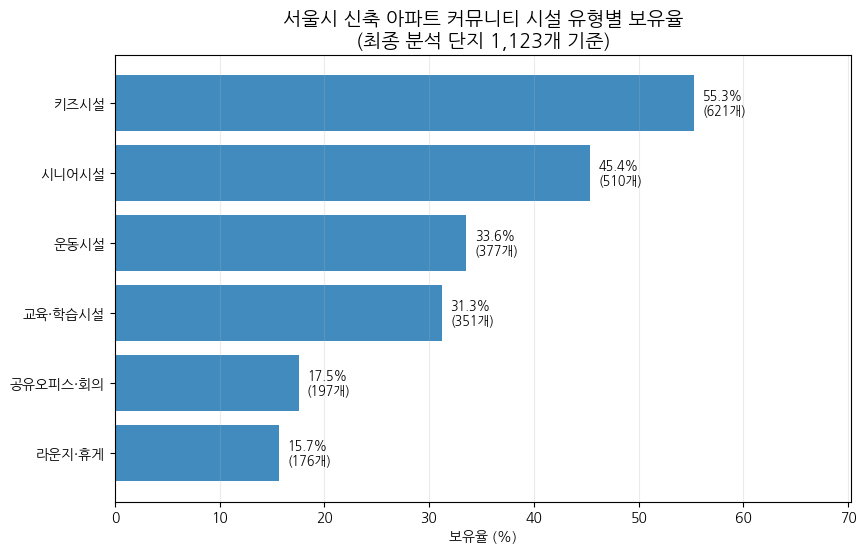

저장 완료: charts/chart1_facility_rate.png


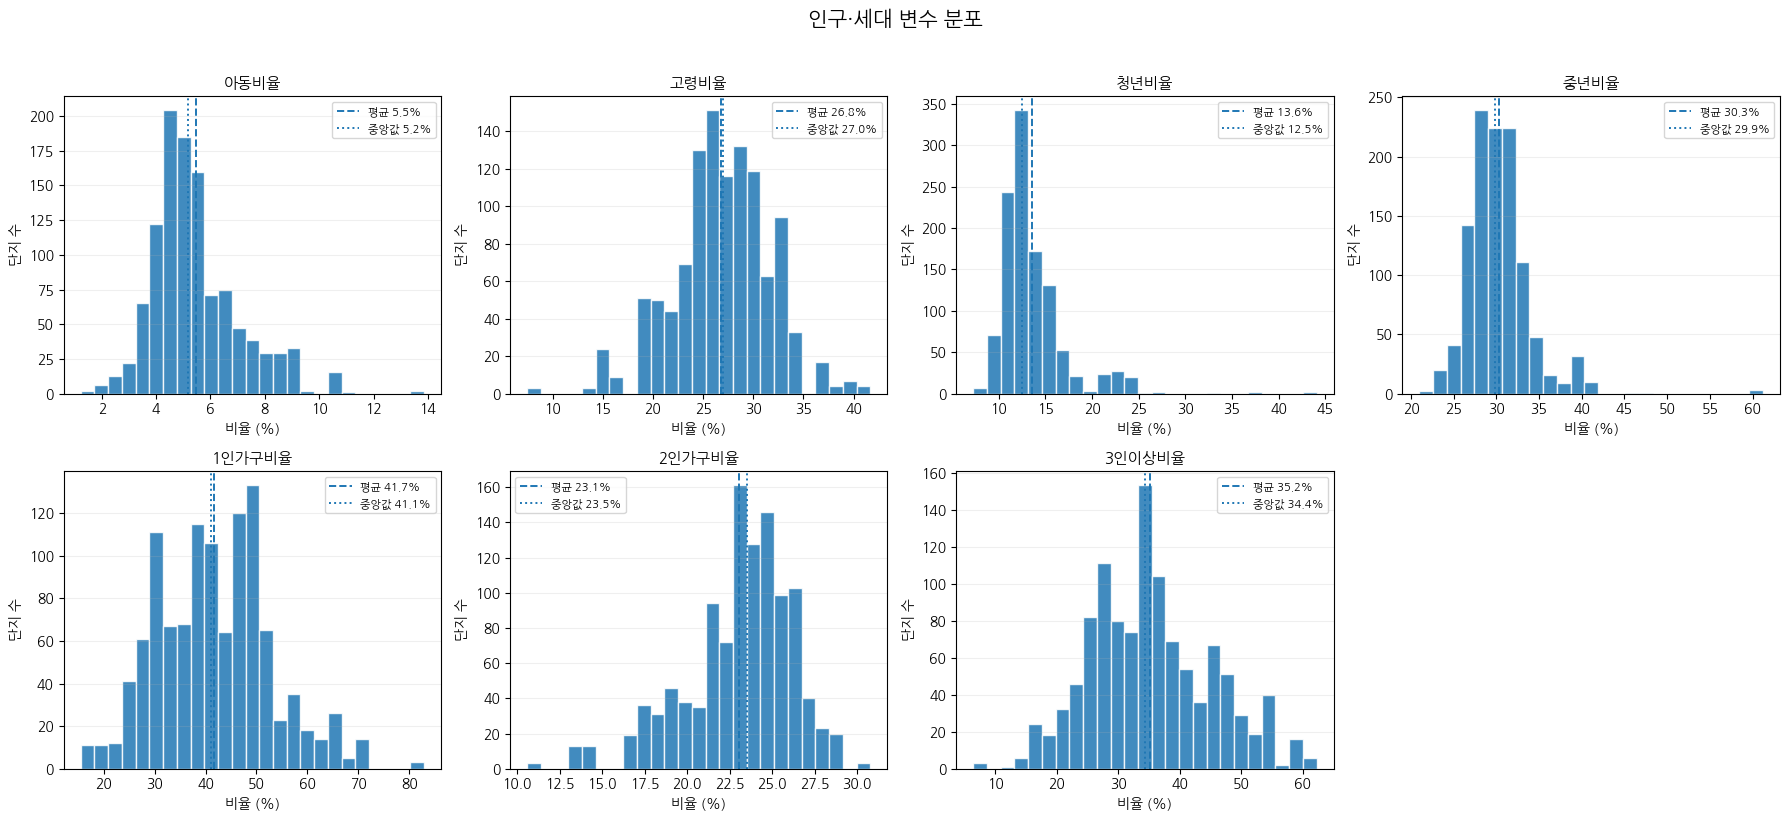

저장 완료: charts/chart2_feature_dist.png


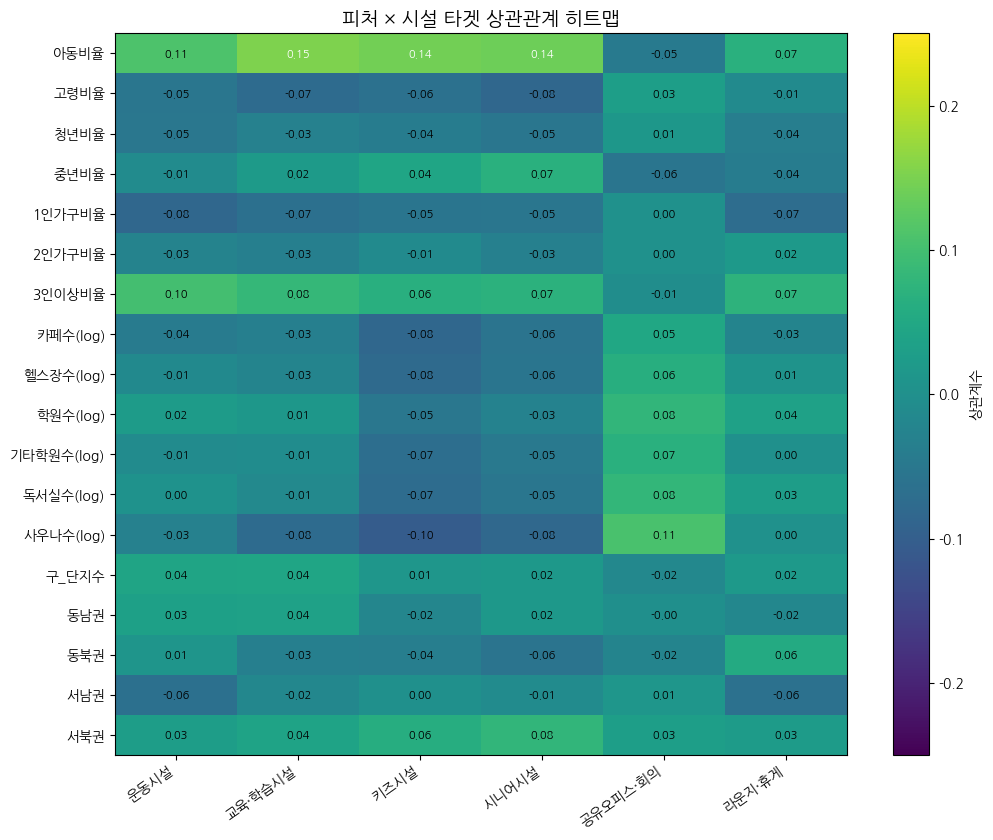

저장 완료: charts/chart3_corr_heatmap.png


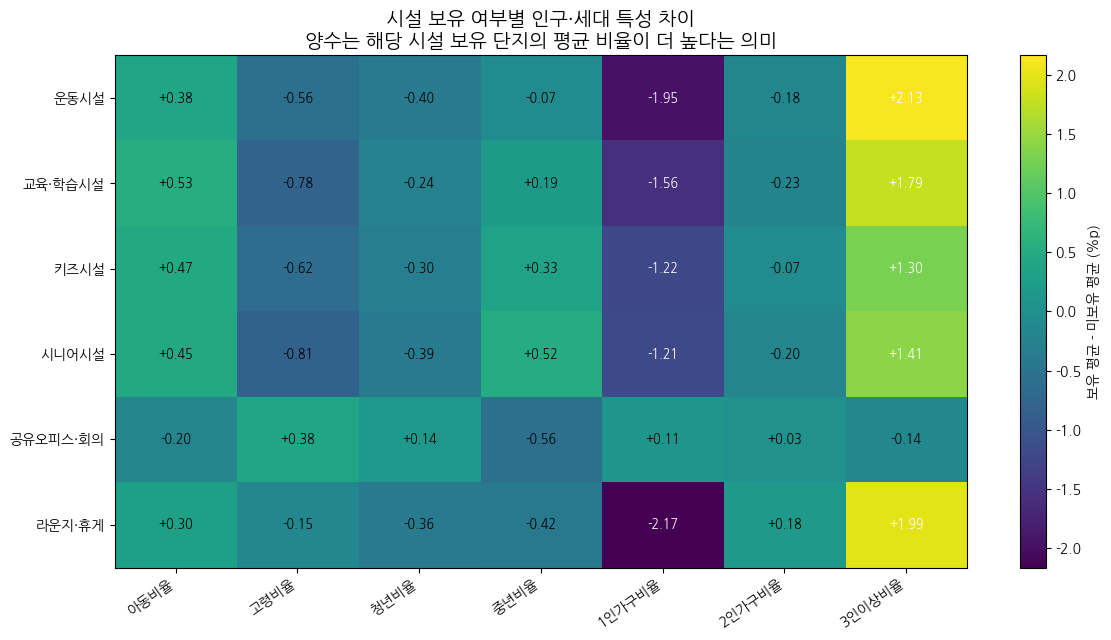

저장 완료: charts/chart4_facility_comparison.png


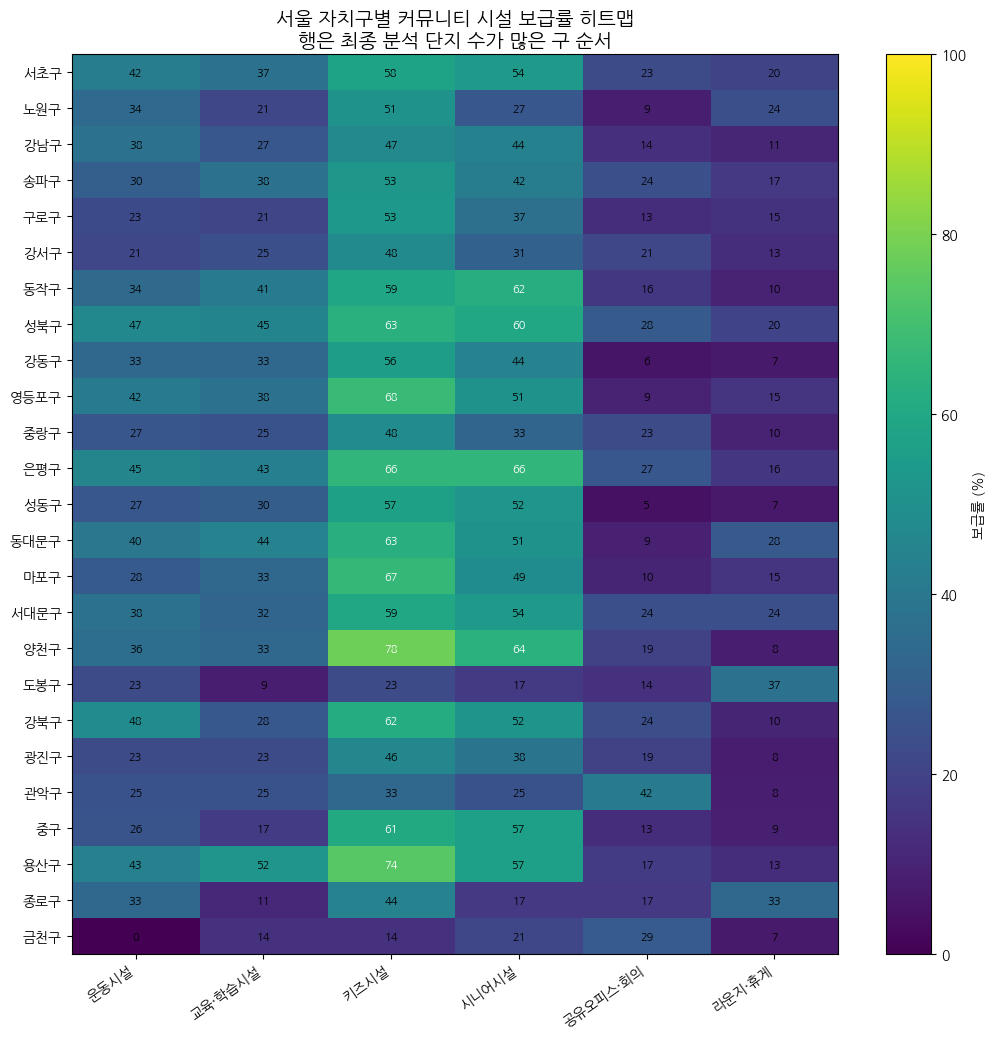

저장 완료: charts/chart5_gu_heatmap.png


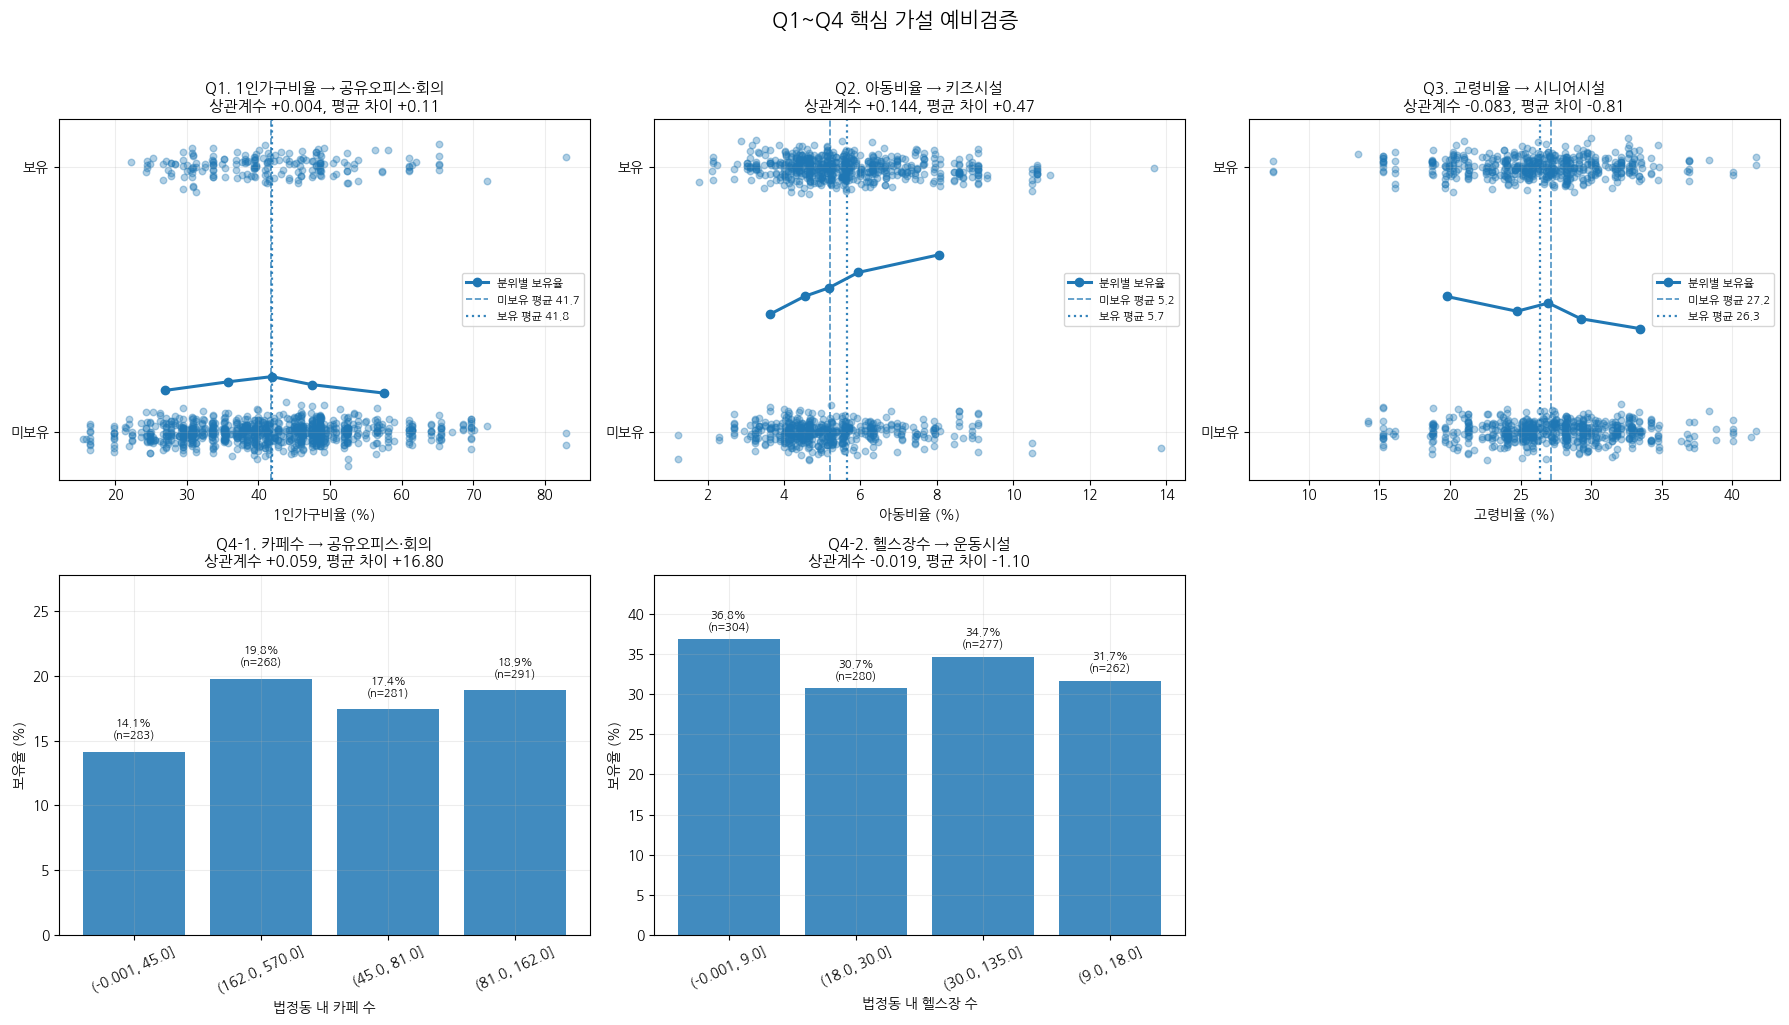

저장 완료: charts/chart6_hypothesis_scatter.png

✅ 8단계 완료
생성된 EDA 차트 파일:
 - charts/chart1_facility_rate.png
 - charts/chart2_feature_dist.png
 - charts/chart3_corr_heatmap.png
 - charts/chart4_facility_comparison.png
 - charts/chart5_gu_heatmap.png
 - charts/chart6_hypothesis_scatter.png

다음 단계에서는 원본 상권 변수 기준으로 분류 모델 학습을 수행하겠습니다.


In [ ]:
# ============================================================
# 8단계. 원본 상권 변수 기준 EDA 시각화 6개 생성
# ============================================================

import json
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------

try:
    subprocess.run(
        ["apt-get", "install", "-y", "fonts-nanum"],
        capture_output=True,
        check=False
    )

    fm._load_fontmanager(try_read_cache=False)

    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fe = fm.FontEntry(fname=font_path, name="NanumGothic")
    fm.fontManager.ttflist.insert(0, fe)

    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

    print("한글 폰트 설정 완료")
except Exception as e:
    print("한글 폰트 설정 실패:", e)


# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


if Path("apt_final_1123.csv").exists():
    apt_final = read_csv_safely("apt_final_1123.csv")
else:
    raise FileNotFoundError("apt_final_1123.csv가 없습니다. 7단계를 먼저 실행하세요.")


if Path("step7_feature_config.json").exists():
    with open("step7_feature_config.json", "r", encoding="utf-8") as f:
        feature_config = json.load(f)
else:
    raise FileNotFoundError("step7_feature_config.json이 없습니다. 7단계를 먼저 실행하세요.")


TARGETS = feature_config["TARGETS"]
FACILITY_ALL = feature_config["FACILITY_ALL"]
DEMO_FEATURES = feature_config["DEMO_FEATURES"]
BIZ_VARS = feature_config["BIZ_VARS"]
BIZ_LOG_FEATURES = feature_config["BIZ_LOG_FEATURES"]
REGION_FEATURES = feature_config["REGION_FEATURES"]
FEATURES_FINAL = feature_config["FEATURES_FINAL"]

print("데이터 로드 완료")
print("단지 수:", len(apt_final))
print("타겟:", TARGETS)
print("최종 피처 수:", len(FEATURES_FINAL))
print("상권 변수:", BIZ_VARS)


# ------------------------------------------------------------
# 2. 저장 폴더 생성
# ------------------------------------------------------------

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

print("차트 저장 폴더:", CHART_DIR)


# ------------------------------------------------------------
# 3. 라벨 정의
# ------------------------------------------------------------

TARGET_LABELS = {
    "운동시설": "운동시설",
    "교육_학습시설": "교육·학습시설",
    "키즈시설": "키즈시설",
    "시니어시설": "시니어시설",
    "공유오피스_회의": "공유오피스·회의",
    "라운지_휴게": "라운지·휴게",
    "사우나_목욕": "사우나·목욕",
    "편의_생활시설": "편의·생활시설"
}

FEATURE_LABELS = {
    "ratio_child": "아동비율",
    "ratio_elderly": "고령비율",
    "ratio_young": "청년비율",
    "ratio_middle": "중년비율",
    "ratio_1person": "1인가구비율",
    "ratio_2person": "2인가구비율",
    "ratio_3plus": "3인이상비율",

    "카페수": "카페수",
    "헬스장수": "헬스장수",
    "학원수": "학원수",
    "기타학원수": "기타학원수",
    "독서실수": "독서실수",
    "사우나수": "사우나수",
    "원본상권총업소수": "원본상권총업소수",

    "카페수_log": "카페수(log)",
    "헬스장수_log": "헬스장수(log)",
    "학원수_log": "학원수(log)",
    "기타학원수_log": "기타학원수(log)",
    "독서실수_log": "독서실수(log)",
    "사우나수_log": "사우나수(log)",
    "원본상권총업소수_log": "원본상권총업소수(log)",

    "구_단지수": "구_단지수",
    "생활권역_동남권": "동남권",
    "생활권역_동북권": "동북권",
    "생활권역_서남권": "서남권",
    "생활권역_서북권": "서북권"
}


def label_target(x):
    return TARGET_LABELS.get(x, x)


def label_feature(x):
    return FEATURE_LABELS.get(x, x)


def save_chart(filename):
    path = CHART_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"저장 완료: {path}")


# ============================================================
# chart1. 시설별 보유율
# ============================================================

facility_rate = (
    apt_final[TARGETS]
    .mean()
    .sort_values(ascending=True)
    * 100
)

facility_count = apt_final[TARGETS].sum().loc[facility_rate.index]

plt.figure(figsize=(9.5, 5.8))
plt.barh(
    [label_target(x) for x in facility_rate.index],
    facility_rate.values,
    alpha=0.85
)

for i, (rate, count) in enumerate(zip(facility_rate.values, facility_count.values)):
    plt.text(
        rate + 0.8,
        i,
        f"{rate:.1f}%\n({int(count)}개)",
        va="center",
        fontsize=9
    )

plt.title(
    "서울시 신축 아파트 커뮤니티 시설 유형별 보유율\n"
    f"(최종 분석 단지 {len(apt_final):,}개 기준)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("보유율 (%)")
plt.xlim(0, max(facility_rate.values) + 15)
plt.grid(axis="x", alpha=0.25)

save_chart("chart1_facility_rate.png")


# ============================================================
# chart2. 인구·세대 변수 분포
# ============================================================

demo_plot_features = [
    "ratio_child",
    "ratio_elderly",
    "ratio_young",
    "ratio_middle",
    "ratio_1person",
    "ratio_2person",
    "ratio_3plus"
]

demo_plot_features = [c for c in demo_plot_features if c in apt_final.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(demo_plot_features):
    ax = axes[idx]

    values = apt_final[col] * 100

    ax.hist(values, bins=25, alpha=0.85, edgecolor="white")
    ax.axvline(values.mean(), linestyle="--", linewidth=1.4, label=f"평균 {values.mean():.1f}%")
    ax.axvline(values.median(), linestyle=":", linewidth=1.4, label=f"중앙값 {values.median():.1f}%")

    ax.set_title(label_feature(col), fontsize=11, fontweight="bold")
    ax.set_xlabel("비율 (%)")
    ax.set_ylabel("단지 수")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2)

for j in range(len(demo_plot_features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "인구·세대 변수 분포",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
save_chart("chart2_feature_dist.png")


# ============================================================
# chart3. 피처 × 타겟 상관관계 히트맵
# ============================================================

corr_matrix = pd.DataFrame(
    index=FEATURES_FINAL,
    columns=TARGETS,
    dtype=float
)

for feat in FEATURES_FINAL:
    for target in TARGETS:
        corr_matrix.loc[feat, target] = apt_final[[feat, target]].corr().iloc[0, 1]

corr_matrix = corr_matrix.astype(float)

fig, ax = plt.subplots(figsize=(10.5, 8.5))

im = ax.imshow(
    corr_matrix.values,
    aspect="auto",
    vmin=-0.25,
    vmax=0.25
)

ax.set_xticks(np.arange(len(TARGETS)))
ax.set_yticks(np.arange(len(FEATURES_FINAL)))

ax.set_xticklabels([label_target(x) for x in TARGETS], rotation=35, ha="right")
ax.set_yticklabels([label_feature(x) for x in FEATURES_FINAL])

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        text_color = "white" if abs(val) >= 0.13 else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("상관계수")

ax.set_title(
    "피처 × 시설 타겟 상관관계 히트맵",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
save_chart("chart3_corr_heatmap.png")


# ============================================================
# chart4. 시설 보유 여부별 인구·세대 특성 차이
# 값 = 보유 단지 평균 - 미보유 단지 평균, 단위 %p
# ============================================================

diff_matrix = pd.DataFrame(
    index=TARGETS,
    columns=demo_plot_features,
    dtype=float
)

for target in TARGETS:
    for feat in demo_plot_features:
        yes_mean = apt_final.loc[apt_final[target] == 1, feat].mean()
        no_mean = apt_final.loc[apt_final[target] == 0, feat].mean()
        diff_matrix.loc[target, feat] = (yes_mean - no_mean) * 100

fig, ax = plt.subplots(figsize=(12, 6.5))

max_abs = np.nanmax(np.abs(diff_matrix.values))

im = ax.imshow(
    diff_matrix.values,
    aspect="auto",
    vmin=-max_abs,
    vmax=max_abs
)

ax.set_xticks(np.arange(len(demo_plot_features)))
ax.set_yticks(np.arange(len(TARGETS)))

ax.set_xticklabels([label_feature(x) for x in demo_plot_features], rotation=35, ha="right")
ax.set_yticklabels([label_target(x) for x in TARGETS])

for i in range(diff_matrix.shape[0]):
    for j in range(diff_matrix.shape[1]):
        val = diff_matrix.iloc[i, j]
        text_color = "white" if abs(val) >= max_abs * 0.55 else "black"
        ax.text(
            j,
            i,
            f"{val:+.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("보유 평균 - 미보유 평균 (%p)")

ax.set_title(
    "시설 보유 여부별 인구·세대 특성 차이\n"
    "양수는 해당 시설 보유 단지의 평균 비율이 더 높다는 의미",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
save_chart("chart4_facility_comparison.png")


# ============================================================
# chart5. 구별 시설 보급률 히트맵
# ============================================================

gu_order = (
    apt_final
    .groupby("구")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

gu_rate = (
    apt_final
    .groupby("구")[TARGETS]
    .mean()
    .loc[gu_order]
    * 100
)

fig, ax = plt.subplots(figsize=(10.5, 10.5))

im = ax.imshow(
    gu_rate.values,
    aspect="auto",
    vmin=0,
    vmax=100
)

ax.set_xticks(np.arange(len(TARGETS)))
ax.set_yticks(np.arange(len(gu_rate.index)))

ax.set_xticklabels([label_target(x) for x in TARGETS], rotation=35, ha="right")
ax.set_yticklabels(gu_rate.index)

for i in range(gu_rate.shape[0]):
    for j in range(gu_rate.shape[1]):
        val = gu_rate.iloc[i, j]
        text_color = "white" if val >= 60 else "black"
        ax.text(
            j,
            i,
            f"{val:.0f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("보급률 (%)")

ax.set_title(
    "서울 자치구별 커뮤니티 시설 보급률 히트맵\n"
    "행은 최종 분석 단지 수가 많은 구 순서",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
save_chart("chart5_gu_heatmap.png")


# ============================================================
# chart6. Q1~Q4 가설 예비검증
# Q1: 1인가구비율 → 공유오피스
# Q2: 아동비율 → 키즈시설
# Q3: 고령비율 → 시니어시설
# Q4-1: 카페수 → 공유오피스
# Q4-2: 헬스장수 → 운동시설
# ============================================================

hypothesis_specs = [
    {
        "title": "Q1. 1인가구비율 → 공유오피스·회의",
        "feature": "ratio_1person",
        "target": "공유오피스_회의",
        "xlabel": "1인가구비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q2. 아동비율 → 키즈시설",
        "feature": "ratio_child",
        "target": "키즈시설",
        "xlabel": "아동비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q3. 고령비율 → 시니어시설",
        "feature": "ratio_elderly",
        "target": "시니어시설",
        "xlabel": "고령비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q4-1. 카페수 → 공유오피스·회의",
        "feature": "카페수",
        "target": "공유오피스_회의",
        "xlabel": "법정동 내 카페 수",
        "scale": 1,
        "mode": "quartile_bar"
    },
    {
        "title": "Q4-2. 헬스장수 → 운동시설",
        "feature": "헬스장수",
        "target": "운동시설",
        "xlabel": "법정동 내 헬스장 수",
        "scale": 1,
        "mode": "quartile_bar"
    }
]

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, spec in zip(axes, hypothesis_specs):
    feat = spec["feature"]
    target = spec["target"]

    x = apt_final[feat] * spec["scale"]
    y = apt_final[target].astype(float)

    corr = apt_final[[feat, target]].corr().iloc[0, 1]

    no_mean = apt_final.loc[apt_final[target] == 0, feat].mean() * spec["scale"]
    yes_mean = apt_final.loc[apt_final[target] == 1, feat].mean() * spec["scale"]

    if spec["mode"] == "scatter_binary":
        y_jitter = y + rng.normal(0, 0.035, size=len(y))

        ax.scatter(
            x,
            y_jitter,
            alpha=0.35,
            s=22
        )

        try:
            bins = pd.qcut(x, q=5, duplicates="drop")
            binned = (
                pd.DataFrame({"x": x, "y": y, "bin": bins})
                .groupby("bin")
                .agg(
                    x_mean=("x", "mean"),
                    y_rate=("y", "mean"),
                    n=("y", "size")
                )
                .reset_index()
            )

            ax.plot(
                binned["x_mean"],
                binned["y_rate"],
                marker="o",
                linewidth=2.2,
                label="분위별 보유율"
            )
        except Exception:
            pass

        ax.axvline(no_mean, linestyle="--", linewidth=1.2, alpha=0.8, label=f"미보유 평균 {no_mean:.1f}")
        ax.axvline(yes_mean, linestyle=":", linewidth=1.6, alpha=0.9, label=f"보유 평균 {yes_mean:.1f}")

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["미보유", "보유"])
        ax.set_ylim(-0.18, 1.18)
        ax.legend(fontsize=8, loc="best")

    else:
        tmp = pd.DataFrame({
            "x": x,
            "y": y
        })

        try:
            tmp["상권분위"] = pd.qcut(
                tmp["x"],
                q=4,
                duplicates="drop"
            ).astype(str)

            rate = (
                tmp
                .groupby("상권분위")["y"]
                .agg(["count", "mean"])
                .reset_index()
            )

            rate["보유율"] = rate["mean"] * 100

            ax.bar(
                rate["상권분위"],
                rate["보유율"],
                alpha=0.85
            )

            for i, row in rate.iterrows():
                ax.text(
                    i,
                    row["보유율"] + 0.8,
                    f"{row['보유율']:.1f}%\n(n={int(row['count'])})",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

            ax.set_ylabel("보유율 (%)")
            ax.tick_params(axis="x", rotation=25)
            ax.set_ylim(0, max(rate["보유율"].max() + 8, 10))

        except Exception as e:
            ax.text(0.5, 0.5, f"분위 계산 실패\n{e}", ha="center", va="center")
            ax.axis("off")

    ax.set_title(
        f"{spec['title']}\n상관계수 {corr:+.3f}, 평균 차이 {yes_mean - no_mean:+.2f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(spec["xlabel"])
    ax.grid(alpha=0.22)

# 남는 subplot 제거
for j in range(len(hypothesis_specs), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Q1~Q4 핵심 가설 예비검증",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
save_chart("chart6_hypothesis_scatter.png")


# ------------------------------------------------------------
# 9. 결과 요약 출력
# ------------------------------------------------------------

print("\n✅ 8단계 완료")
print("생성된 EDA 차트 파일:")

for file in sorted(CHART_DIR.glob("chart*.png")):
    print(" -", file)

print("\n다음 단계에서는 원본 상권 변수 기준으로 분류 모델 학습을 수행하겠습니다.")

한글 폰트 설정 완료


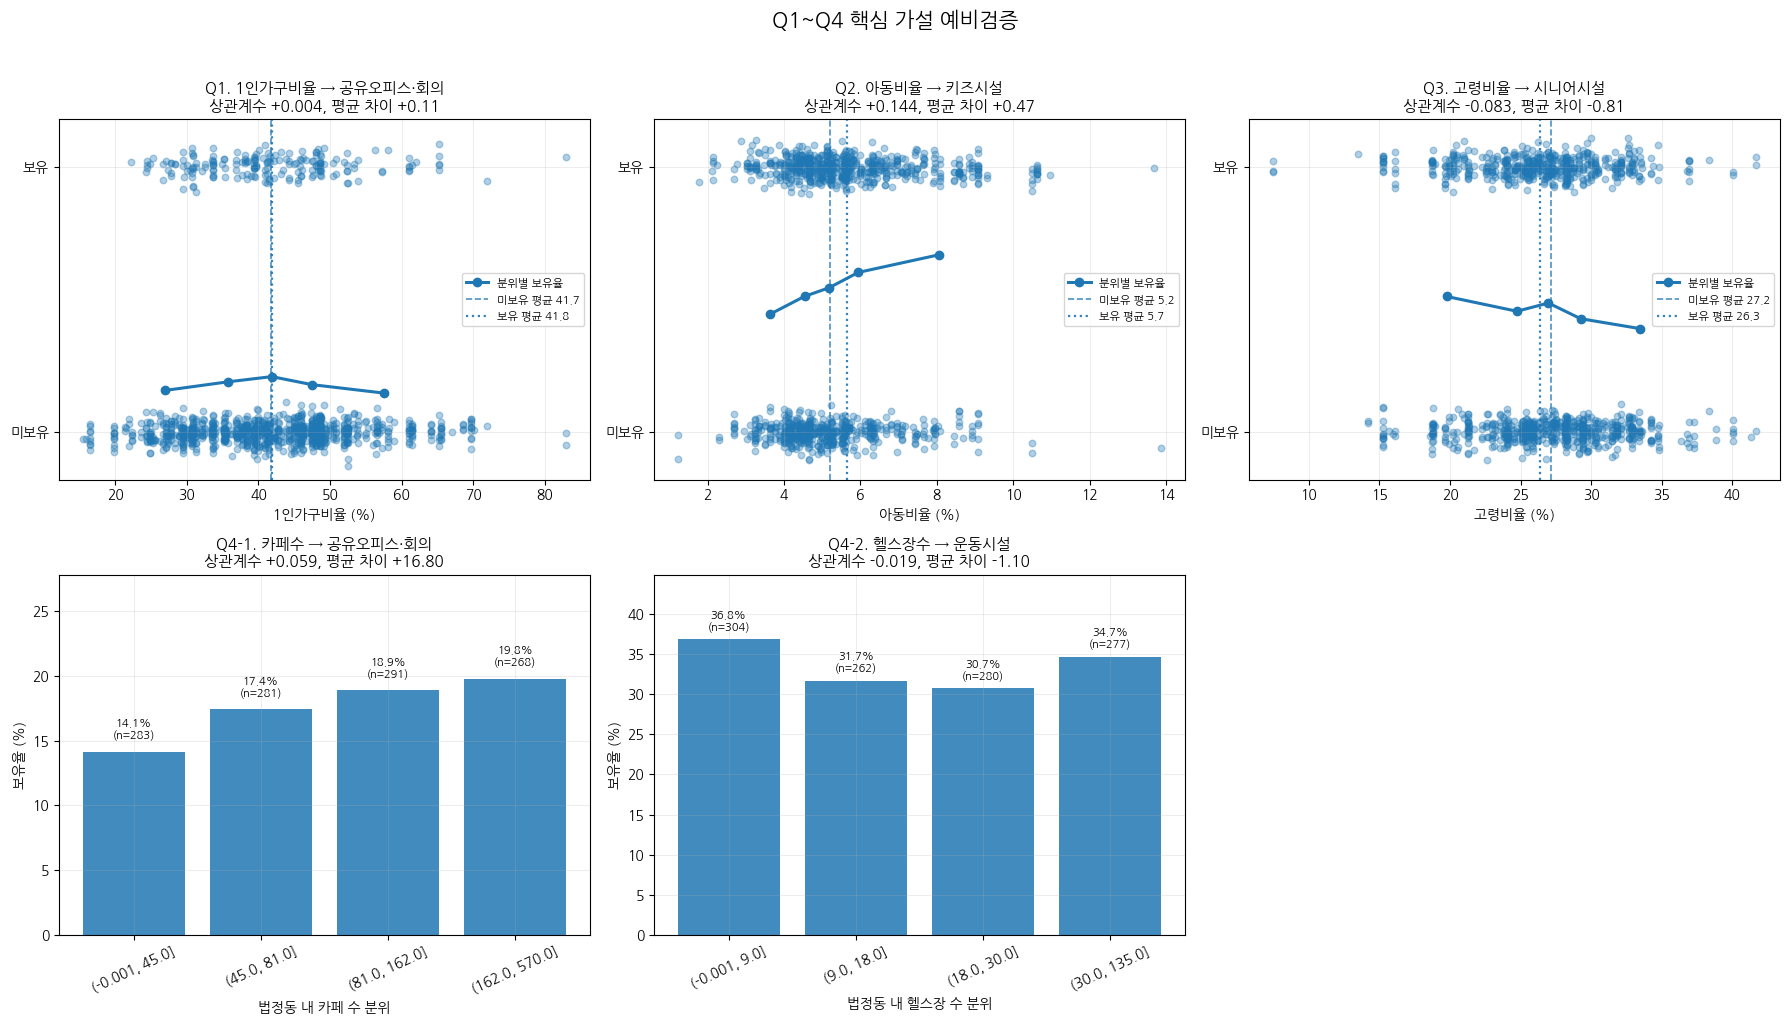

저장 완료: charts/chart6_hypothesis_scatter.png

✅ 8-1단계 완료
chart6의 Q4 분위 순서를 하위 → 상위 순서로 보정했습니다.


In [ ]:
# ============================================================
# 8-1단계. chart6 Q1~Q4 가설 예비검증 차트 순서 보정
# ============================================================

import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------

try:
    subprocess.run(
        ["apt-get", "install", "-y", "fonts-nanum"],
        capture_output=True,
        check=False
    )

    fm._load_fontmanager(try_read_cache=False)

    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fe = fm.FontEntry(fname=font_path, name="NanumGothic")
    fm.fontManager.ttflist.insert(0, fe)

    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

    print("한글 폰트 설정 완료")
except Exception as e:
    print("한글 폰트 설정 실패:", e)


# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


apt_final = read_csv_safely("apt_final_1123.csv")

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 2. Q1~Q4 차트 설정
# ------------------------------------------------------------

hypothesis_specs = [
    {
        "title": "Q1. 1인가구비율 → 공유오피스·회의",
        "feature": "ratio_1person",
        "target": "공유오피스_회의",
        "xlabel": "1인가구비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q2. 아동비율 → 키즈시설",
        "feature": "ratio_child",
        "target": "키즈시설",
        "xlabel": "아동비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q3. 고령비율 → 시니어시설",
        "feature": "ratio_elderly",
        "target": "시니어시설",
        "xlabel": "고령비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q4-1. 카페수 → 공유오피스·회의",
        "feature": "카페수",
        "target": "공유오피스_회의",
        "xlabel": "법정동 내 카페 수 분위",
        "scale": 1,
        "mode": "quartile_bar"
    },
    {
        "title": "Q4-2. 헬스장수 → 운동시설",
        "feature": "헬스장수",
        "target": "운동시설",
        "xlabel": "법정동 내 헬스장 수 분위",
        "scale": 1,
        "mode": "quartile_bar"
    }
]


# ------------------------------------------------------------
# 3. 차트 생성
# ------------------------------------------------------------

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, spec in zip(axes, hypothesis_specs):
    feat = spec["feature"]
    target = spec["target"]

    x = apt_final[feat] * spec["scale"]
    y = apt_final[target].astype(float)

    corr = apt_final[[feat, target]].corr().iloc[0, 1]

    no_mean = apt_final.loc[apt_final[target] == 0, feat].mean() * spec["scale"]
    yes_mean = apt_final.loc[apt_final[target] == 1, feat].mean() * spec["scale"]

    # --------------------------------------------------------
    # Q1~Q3: 0/1 산점도 + 분위별 보유율 선
    # --------------------------------------------------------
    if spec["mode"] == "scatter_binary":
        y_jitter = y + rng.normal(0, 0.035, size=len(y))

        ax.scatter(
            x,
            y_jitter,
            alpha=0.35,
            s=22
        )

        try:
            bins = pd.qcut(x, q=5, duplicates="drop")

            binned = (
                pd.DataFrame({"x": x, "y": y, "bin": bins})
                .groupby("bin", observed=True, sort=True)
                .agg(
                    x_mean=("x", "mean"),
                    y_rate=("y", "mean"),
                    n=("y", "size")
                )
                .reset_index()
                .sort_values("x_mean")
            )

            ax.plot(
                binned["x_mean"],
                binned["y_rate"],
                marker="o",
                linewidth=2.2,
                label="분위별 보유율"
            )
        except Exception as e:
            print(f"{spec['title']} 분위선 계산 실패:", e)

        ax.axvline(
            no_mean,
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            label=f"미보유 평균 {no_mean:.1f}"
        )

        ax.axvline(
            yes_mean,
            linestyle=":",
            linewidth=1.6,
            alpha=0.9,
            label=f"보유 평균 {yes_mean:.1f}"
        )

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["미보유", "보유"])
        ax.set_ylim(-0.18, 1.18)
        ax.legend(fontsize=8, loc="best")

    # --------------------------------------------------------
    # Q4: 분위별 보유율 막대그래프
    # 핵심 수정: qcut 결과를 바로 groupby하고, 평균 x값 기준 정렬
    # --------------------------------------------------------
    else:
        tmp = pd.DataFrame({
            "x": x,
            "y": y
        }).copy()

        try:
            tmp["상권분위"] = pd.qcut(
                tmp["x"],
                q=4,
                duplicates="drop"
            )

            rate = (
                tmp
                .groupby("상권분위", observed=True, sort=True)
                .agg(
                    count=("y", "size"),
                    보유율=("y", "mean"),
                    x_mean=("x", "mean")
                )
                .reset_index()
                .sort_values("x_mean")
            )

            rate["보유율_pct"] = rate["보유율"] * 100
            rate["상권분위_label"] = rate["상권분위"].astype(str)

            ax.bar(
                rate["상권분위_label"],
                rate["보유율_pct"],
                alpha=0.85
            )

            for i, row in rate.reset_index(drop=True).iterrows():
                ax.text(
                    i,
                    row["보유율_pct"] + 0.8,
                    f"{row['보유율_pct']:.1f}%\n(n={int(row['count'])})",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

            ax.set_ylabel("보유율 (%)")
            ax.tick_params(axis="x", rotation=25)
            ax.set_ylim(0, max(rate["보유율_pct"].max() + 8, 10))

        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"분위 계산 실패\n{e}",
                ha="center",
                va="center"
            )
            ax.axis("off")

    ax.set_title(
        f"{spec['title']}\n상관계수 {corr:+.3f}, 평균 차이 {yes_mean - no_mean:+.2f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(spec["xlabel"])
    ax.grid(alpha=0.22)


# 남는 subplot 제거
for j in range(len(hypothesis_specs), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Q1~Q4 핵심 가설 예비검증",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

save_path = CHART_DIR / "chart6_hypothesis_scatter.png"
plt.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"저장 완료: {save_path}")
print("\n✅ 8-1단계 완료")
print("chart6의 Q4 분위 순서를 하위 → 상위 순서로 보정했습니다.")

한글 폰트 설정 완료


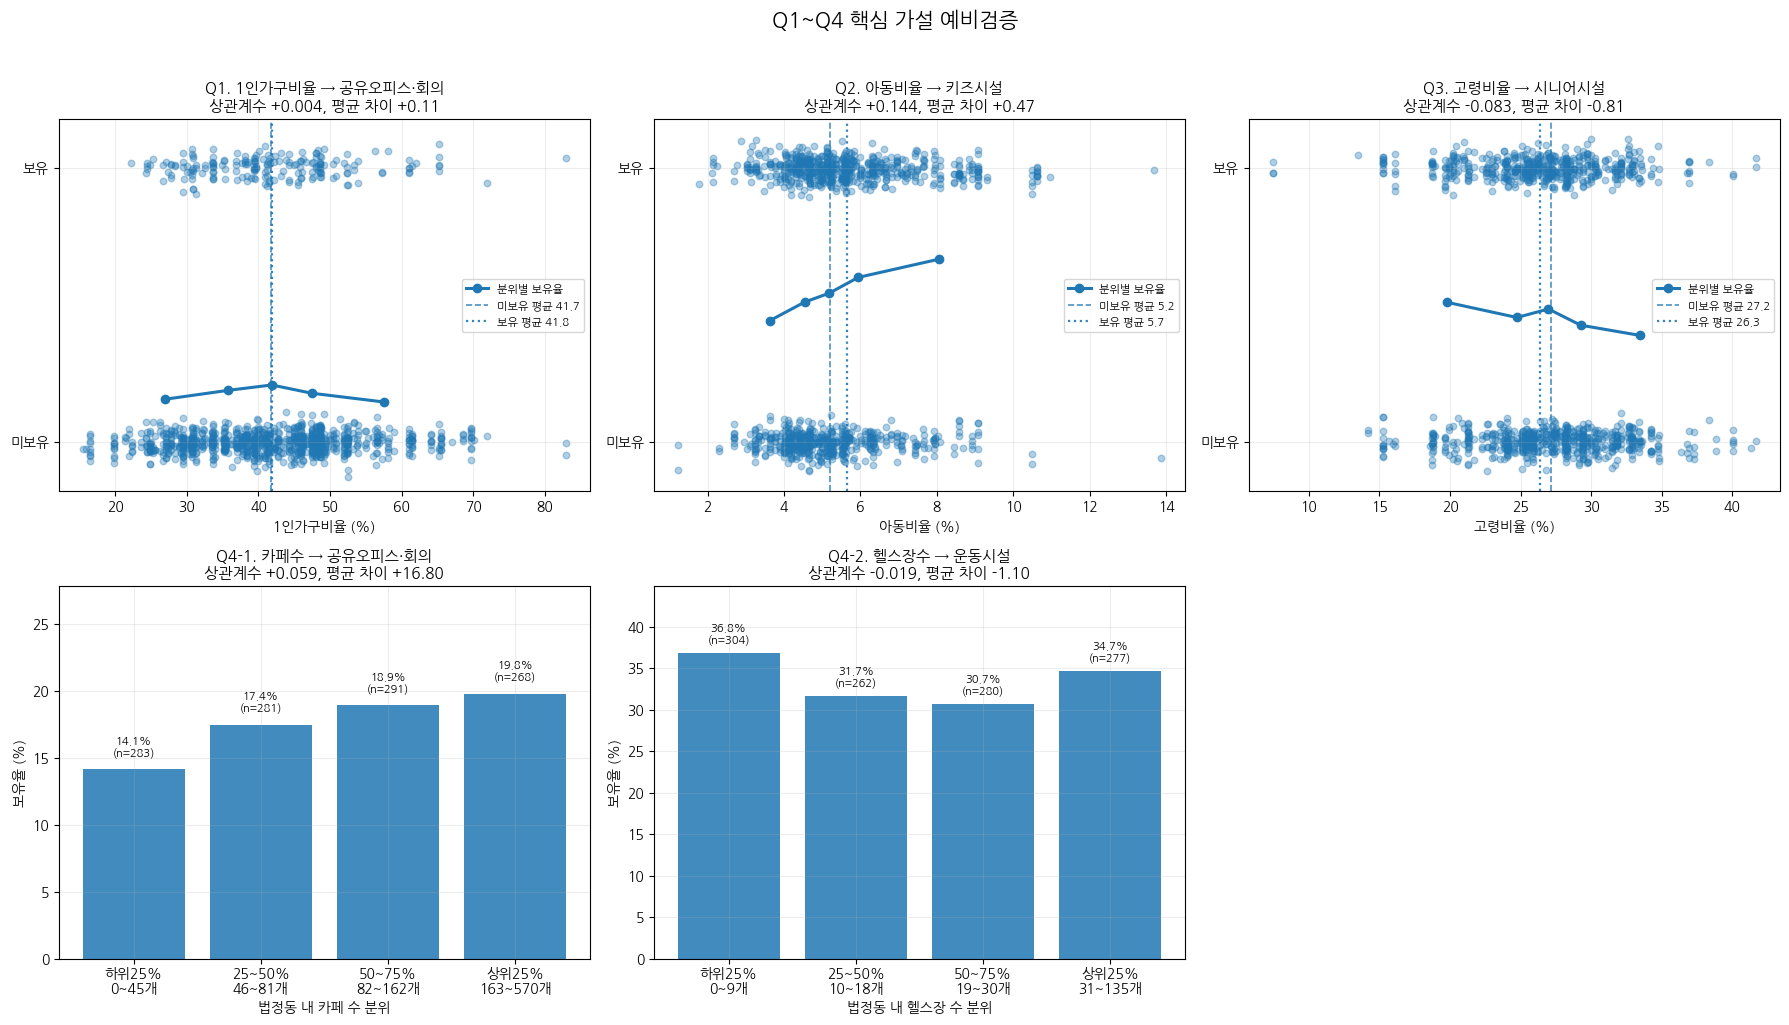

저장 완료: charts/chart6_hypothesis_scatter.png

✅ 8-2단계 완료
Q4-1, Q4-2의 X축을 사람이 읽기 쉬운 분위 라벨로 수정했습니다.

=== Q4-1 카페수 분위별 공유오피스·회의 보유율 ===
         카페수 분위  단지수    보유율(%)
   하위25%\n0~45개  283 14.134276
 25~50%\n46~81개  281 17.437722
50~75%\n82~162개  291 18.900344
상위25%\n163~570개  268 19.776119

=== Q4-2 헬스장수 분위별 운동시설 보유율 ===
       헬스장수 분위  단지수    보유율(%)
   하위25%\n0~9개  304 36.842105
25~50%\n10~18개  262 31.679389
50~75%\n19~30개  280 30.714286
상위25%\n31~135개  277 34.657040


In [ ]:
# ============================================================
# 8-2단계. chart6 Q4 X축 라벨을 이해하기 쉽게 수정
# ============================================================

import re
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------

try:
    subprocess.run(
        ["apt-get", "install", "-y", "fonts-nanum"],
        capture_output=True,
        check=False
    )

    fm._load_fontmanager(try_read_cache=False)

    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fe = fm.FontEntry(fname=font_path, name="NanumGothic")
    fm.fontManager.ttflist.insert(0, fe)

    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

    print("한글 폰트 설정 완료")
except Exception as e:
    print("한글 폰트 설정 실패:", e)


# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


apt_final = read_csv_safely("apt_final_1123.csv")

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 2. qcut 구간 라벨을 사람이 읽기 쉽게 바꾸는 함수
# ------------------------------------------------------------

def make_quartile_rate_table(data, feature, target):
    """
    feature를 4분위로 나누고,
    각 분위별 target 보유율을 계산한다.

    X축 라벨 예:
    하위25%
    0~45개
    """
    tmp = data[[feature, target]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[feature], q=4, duplicates="drop")

    rate = (
        tmp
        .groupby("bin", observed=True, sort=True)
        .agg(
            count=(target, "size"),
            보유율=(target, "mean"),
            x_mean=(feature, "mean")
        )
        .reset_index()
        .sort_values("x_mean")
        .reset_index(drop=True)
    )

    quartile_names = ["하위25%", "25~50%", "50~75%", "상위25%"]
    labels = []

    for i, interval in enumerate(rate["bin"]):
        left = interval.left
        right = interval.right

        # 첫 구간의 -0.001은 0으로 표시
        if left < 0:
            start = 0
        else:
            # 카페수/헬스장수는 정수 카운트이므로 다음 정수부터 표시
            start = int(np.floor(left)) + 1

        end = int(np.floor(right))

        labels.append(f"{quartile_names[i]}\n{start}~{end}개")

    rate["label"] = labels
    rate["보유율_pct"] = rate["보유율"] * 100

    return rate


# ------------------------------------------------------------
# 3. 차트 설정
# ------------------------------------------------------------

hypothesis_specs = [
    {
        "title": "Q1. 1인가구비율 → 공유오피스·회의",
        "feature": "ratio_1person",
        "target": "공유오피스_회의",
        "xlabel": "1인가구비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q2. 아동비율 → 키즈시설",
        "feature": "ratio_child",
        "target": "키즈시설",
        "xlabel": "아동비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q3. 고령비율 → 시니어시설",
        "feature": "ratio_elderly",
        "target": "시니어시설",
        "xlabel": "고령비율 (%)",
        "scale": 100,
        "mode": "scatter_binary"
    },
    {
        "title": "Q4-1. 카페수 → 공유오피스·회의",
        "feature": "카페수",
        "target": "공유오피스_회의",
        "xlabel": "법정동 내 카페 수 분위",
        "scale": 1,
        "mode": "quartile_bar"
    },
    {
        "title": "Q4-2. 헬스장수 → 운동시설",
        "feature": "헬스장수",
        "target": "운동시설",
        "xlabel": "법정동 내 헬스장 수 분위",
        "scale": 1,
        "mode": "quartile_bar"
    }
]


# ------------------------------------------------------------
# 4. 차트 생성
# ------------------------------------------------------------

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, spec in zip(axes, hypothesis_specs):
    feat = spec["feature"]
    target = spec["target"]

    x = apt_final[feat] * spec["scale"]
    y = apt_final[target].astype(float)

    corr = apt_final[[feat, target]].corr().iloc[0, 1]

    no_mean = apt_final.loc[apt_final[target] == 0, feat].mean() * spec["scale"]
    yes_mean = apt_final.loc[apt_final[target] == 1, feat].mean() * spec["scale"]

    # --------------------------------------------------------
    # Q1~Q3: 산점도
    # --------------------------------------------------------
    if spec["mode"] == "scatter_binary":
        y_jitter = y + rng.normal(0, 0.035, size=len(y))

        ax.scatter(
            x,
            y_jitter,
            alpha=0.35,
            s=22
        )

        try:
            bins = pd.qcut(x, q=5, duplicates="drop")

            binned = (
                pd.DataFrame({"x": x, "y": y, "bin": bins})
                .groupby("bin", observed=True, sort=True)
                .agg(
                    x_mean=("x", "mean"),
                    y_rate=("y", "mean"),
                    n=("y", "size")
                )
                .reset_index()
                .sort_values("x_mean")
            )

            ax.plot(
                binned["x_mean"],
                binned["y_rate"],
                marker="o",
                linewidth=2.2,
                label="분위별 보유율"
            )

        except Exception as e:
            print(f"{spec['title']} 분위선 계산 실패:", e)

        ax.axvline(
            no_mean,
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            label=f"미보유 평균 {no_mean:.1f}"
        )

        ax.axvline(
            yes_mean,
            linestyle=":",
            linewidth=1.6,
            alpha=0.9,
            label=f"보유 평균 {yes_mean:.1f}"
        )

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["미보유", "보유"])
        ax.set_ylim(-0.18, 1.18)
        ax.legend(fontsize=8, loc="best")

    # --------------------------------------------------------
    # Q4: 분위별 보유율 막대그래프
    # --------------------------------------------------------
    else:
        rate = make_quartile_rate_table(
            data=apt_final,
            feature=feat,
            target=target
        )

        ax.bar(
            rate["label"],
            rate["보유율_pct"],
            alpha=0.85
        )

        for i, row in rate.iterrows():
            ax.text(
                i,
                row["보유율_pct"] + 0.8,
                f"{row['보유율_pct']:.1f}%\n(n={int(row['count'])})",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_ylabel("보유율 (%)")
        ax.set_ylim(0, max(rate["보유율_pct"].max() + 8, 10))

    ax.set_title(
        f"{spec['title']}\n상관계수 {corr:+.3f}, 평균 차이 {yes_mean - no_mean:+.2f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(spec["xlabel"])
    ax.grid(alpha=0.22)


# 남는 subplot 제거
for j in range(len(hypothesis_specs), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Q1~Q4 핵심 가설 예비검증",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

save_path = CHART_DIR / "chart6_hypothesis_scatter.png"
plt.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"저장 완료: {save_path}")
print("\n✅ 8-2단계 완료")
print("Q4-1, Q4-2의 X축을 사람이 읽기 쉬운 분위 라벨로 수정했습니다.")


# ------------------------------------------------------------
# 5. 보고서 해석용 수치도 함께 출력
# ------------------------------------------------------------

print("\n=== Q4-1 카페수 분위별 공유오피스·회의 보유율 ===")
print(
    make_quartile_rate_table(
        apt_final,
        "카페수",
        "공유오피스_회의"
    )[["label", "count", "보유율_pct"]]
    .rename(columns={"label": "카페수 분위", "count": "단지수", "보유율_pct": "보유율(%)"})
    .to_string(index=False)
)

print("\n=== Q4-2 헬스장수 분위별 운동시설 보유율 ===")
print(
    make_quartile_rate_table(
        apt_final,
        "헬스장수",
        "운동시설"
    )[["label", "count", "보유율_pct"]]
    .rename(columns={"label": "헬스장수 분위", "count": "단지수", "보유율_pct": "보유율(%)"})
    .to_string(index=False)
)

In [ ]:
# ============================================================
# 9단계. 분류 모델 학습 및 성능 평가
# ============================================================

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

import joblib
import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 0. 데이터 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


DATA_PATH = "apt_final_1123.csv"
CONFIG_PATH = "step7_feature_config.json"

if not Path(DATA_PATH).exists():
    raise FileNotFoundError("apt_final_1123.csv가 없습니다. 7단계를 먼저 실행하세요.")

if not Path(CONFIG_PATH).exists():
    raise FileNotFoundError("step7_feature_config.json이 없습니다. 7단계를 먼저 실행하세요.")


apt_final = read_csv_safely(DATA_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = json.load(f)


TARGETS = feature_config["TARGETS"]
FEATURES_FINAL = feature_config["FEATURES_FINAL"]

print("데이터 로드 완료")
print("단지 수:", f"{len(apt_final):,}개")
print("타겟:", TARGETS)
print("최종 피처 수:", len(FEATURES_FINAL))
print("최종 피처:", FEATURES_FINAL)


# ------------------------------------------------------------
# 1. X, y 준비
# ------------------------------------------------------------

X = apt_final[FEATURES_FINAL].copy()

# 숫자형 변환 및 결측 보정
for col in FEATURES_FINAL:
    X[col] = pd.to_numeric(X[col], errors="coerce")

if X.isna().sum().sum() > 0:
    print("피처 결측치 발견 → 전체 평균으로 대체")
    X = X.fillna(X.mean(numeric_only=True))

print("\n=== 타겟별 보유율 ===")
for target in TARGETS:
    pos_rate = apt_final[target].mean()
    print(f"{target:15s}: {pos_rate*100:5.1f}%  "
          f"보유 {int(apt_final[target].sum()):,}개 / 전체 {len(apt_final):,}개")


# ------------------------------------------------------------
# 2. 모델 정의
# ------------------------------------------------------------

models = {
    "Dummy_majority": DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ),

    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="liblinear",
            random_state=42
        ))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 3. 교차검증 함수
# ------------------------------------------------------------

def evaluate_model_cv(model, X, y, cv):
    """
    5-Fold Stratified CV로 성능 평가.
    보유 클래스 F1을 메인 지표로 사용하고,
    Macro F1, Balanced Accuracy도 함께 계산한다.
    """
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.full(len(y), np.nan)

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        m = clone(model)
        m.fit(X_train, y_train)

        pred = m.predict(X_test)

        # 확률값 저장 가능하면 저장
        if hasattr(m, "predict_proba"):
            proba = m.predict_proba(X_test)[:, 1]
        else:
            proba = np.full(len(test_idx), np.nan)

        oof_pred[test_idx] = pred
        oof_proba[test_idx] = proba

        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

        fold_rows.append({
            "fold": fold_idx,
            "f1_pos": f1_score(y_test, pred, pos_label=1, zero_division=0),
            "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "precision_pos": precision_score(y_test, pred, pos_label=1, zero_division=0),
            "recall_pos": recall_score(y_test, pred, pos_label=1, zero_division=0),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "f1_pos_mean": fold_df["f1_pos"].mean(),
        "f1_pos_std": fold_df["f1_pos"].std(),
        "f1_macro_mean": fold_df["f1_macro"].mean(),
        "f1_macro_std": fold_df["f1_macro"].std(),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "precision_pos_mean": fold_df["precision_pos"].mean(),
        "recall_pos_mean": fold_df["recall_pos"].mean(),
        "oof_pred": oof_pred,
        "oof_proba": oof_proba,
        "fold_df": fold_df
    }

    return summary


# ------------------------------------------------------------
# 4. 시설별 모델 평가
# ------------------------------------------------------------

all_result_rows = []
all_fold_rows = []
oof_prediction_rows = []

print("\n모델 학습 및 교차검증 시작...\n")

for target in TARGETS:
    y = apt_final[target].astype(int)

    print(f"===== {target} =====")

    target_model_results = {}

    for model_name, model in models.items():
        eval_result = evaluate_model_cv(model, X, y, cv)
        target_model_results[model_name] = eval_result

        all_result_rows.append({
            "target": target,
            "model": model_name,
            "positive_rate": y.mean(),
            "positive_count": int(y.sum()),
            "negative_count": int((y == 0).sum()),
            "f1_pos_mean": eval_result["f1_pos_mean"],
            "f1_pos_std": eval_result["f1_pos_std"],
            "f1_macro_mean": eval_result["f1_macro_mean"],
            "f1_macro_std": eval_result["f1_macro_std"],
            "accuracy_mean": eval_result["accuracy_mean"],
            "balanced_accuracy_mean": eval_result["balanced_accuracy_mean"],
            "precision_pos_mean": eval_result["precision_pos_mean"],
            "recall_pos_mean": eval_result["recall_pos_mean"]
        })

        fold_df = eval_result["fold_df"].copy()
        fold_df["target"] = target
        fold_df["model"] = model_name
        all_fold_rows.append(fold_df)

        print(
            f"{model_name:20s} | "
            f"보유F1 {eval_result['f1_pos_mean']:.3f} "
            f"± {eval_result['f1_pos_std']:.3f} | "
            f"MacroF1 {eval_result['f1_macro_mean']:.3f} | "
            f"BalAcc {eval_result['balanced_accuracy_mean']:.3f}"
        )

        # OOF 예측 저장
        for i in range(len(y)):
            oof_prediction_rows.append({
                "target": target,
                "model": model_name,
                "row_id": i,
                "단지키": apt_final.loc[i, "단지키"] if "단지키" in apt_final.columns else i,
                "구": apt_final.loc[i, "구"] if "구" in apt_final.columns else None,
                "법정동": apt_final.loc[i, "법정동"] if "법정동" in apt_final.columns else None,
                "y_true": int(y.iloc[i]),
                "y_pred": int(eval_result["oof_pred"][i]),
                "y_proba": eval_result["oof_proba"][i]
            })

    print()


result_df = pd.DataFrame(all_result_rows)
fold_result_df = pd.concat(all_fold_rows, ignore_index=True)
oof_pred_df = pd.DataFrame(oof_prediction_rows)


# ------------------------------------------------------------
# 5. 최종 채택 모델 선택
#    기준: Dummy 제외, 보유 클래스 F1이 가장 높은 모델
# ------------------------------------------------------------

candidate_df = result_df[result_df["model"] != "Dummy_majority"].copy()

best_rows = []

for target in TARGETS:
    sub = candidate_df[candidate_df["target"] == target].copy()
    sub = sub.sort_values("f1_pos_mean", ascending=False)

    best = sub.iloc[0].copy()

    dummy_f1 = result_df[
        (result_df["target"] == target)
        & (result_df["model"] == "Dummy_majority")
    ]["f1_pos_mean"].iloc[0]

    best["baseline_f1_pos"] = dummy_f1
    best["improvement_vs_baseline"] = best["f1_pos_mean"] - dummy_f1

    if best["improvement_vs_baseline"] >= 0.05:
        best["validity"] = "유의미"
    else:
        best["validity"] = "재검토"

    best_rows.append(best)

best_model_df = pd.DataFrame(best_rows)

print("\n=== 최종 채택 모델 요약 ===")
display_cols = [
    "target",
    "positive_rate",
    "positive_count",
    "baseline_f1_pos",
    "model",
    "f1_pos_mean",
    "f1_macro_mean",
    "balanced_accuracy_mean",
    "precision_pos_mean",
    "recall_pos_mean",
    "improvement_vs_baseline",
    "validity"
]

print(
    best_model_df[display_cols]
    .assign(
        positive_rate=lambda d: (d["positive_rate"] * 100).round(1),
        baseline_f1_pos=lambda d: d["baseline_f1_pos"].round(3),
        f1_pos_mean=lambda d: d["f1_pos_mean"].round(3),
        f1_macro_mean=lambda d: d["f1_macro_mean"].round(3),
        balanced_accuracy_mean=lambda d: d["balanced_accuracy_mean"].round(3),
        precision_pos_mean=lambda d: d["precision_pos_mean"].round(3),
        recall_pos_mean=lambda d: d["recall_pos_mean"].round(3),
        improvement_vs_baseline=lambda d: d["improvement_vs_baseline"].round(3)
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. 전체 성능표 보기 좋게 정리
# ------------------------------------------------------------

performance_pivot = (
    result_df
    .pivot_table(
        index="target",
        columns="model",
        values="f1_pos_mean"
    )
    .reset_index()
)

print("\n=== 보유 클래스 F1 전체 비교표 ===")
print(performance_pivot.round(3).to_string(index=False))


macro_pivot = (
    result_df
    .pivot_table(
        index="target",
        columns="model",
        values="f1_macro_mean"
    )
    .reset_index()
)

print("\n=== Macro F1 전체 비교표 ===")
print(macro_pivot.round(3).to_string(index=False))


# ------------------------------------------------------------
# 7. 최종 모델 전체 데이터로 재학습 후 저장
# ------------------------------------------------------------

MODEL_DIR = Path("models_step9")
MODEL_DIR.mkdir(exist_ok=True)

trained_models = {}
best_model_map = {}

print("\n최종 모델 전체 데이터 재학습 및 저장...\n")

for _, row in best_model_df.iterrows():
    target = row["target"]
    model_name = row["model"]

    model_template = models[model_name]
    final_model = clone(model_template)

    y = apt_final[target].astype(int)
    final_model.fit(X, y)

    trained_models[target] = final_model
    best_model_map[target] = model_name

    save_path = MODEL_DIR / f"best_model_{target}.pkl"
    joblib.dump(final_model, save_path)

    print(
        f"저장 완료: {target:15s} → {model_name:20s} "
        f"| 보유F1 {row['f1_pos_mean']:.3f} | {save_path}"
    )


# ------------------------------------------------------------
# 8. 결과 저장
# ------------------------------------------------------------

result_df.to_csv("step9_model_all_results.csv", index=False, encoding="utf-8-sig")
fold_result_df.to_csv("step9_model_fold_results.csv", index=False, encoding="utf-8-sig")
best_model_df.to_csv("step9_best_model_summary.csv", index=False, encoding="utf-8-sig")
performance_pivot.to_csv("step9_f1_pos_pivot.csv", index=False, encoding="utf-8-sig")
macro_pivot.to_csv("step9_f1_macro_pivot.csv", index=False, encoding="utf-8-sig")
oof_pred_df.to_csv("step9_oof_predictions.csv", index=False, encoding="utf-8-sig")

model_config = {
    "TARGETS": TARGETS,
    "FEATURES_FINAL": FEATURES_FINAL,
    "main_metric": "f1_pos",
    "main_metric_description": "시설 보유=1 클래스를 기준으로 한 positive-class F1",
    "secondary_metrics": [
        "f1_macro",
        "balanced_accuracy",
        "precision_pos",
        "recall_pos"
    ],
    "best_model_map": best_model_map,
    "model_dir": str(MODEL_DIR),
    "note": (
        "Dummy_majority, LogisticRegression, RandomForest를 5-Fold Stratified CV로 비교. "
        "최종 모델은 Dummy를 제외하고 positive-class F1이 가장 높은 모델로 선택."
    )
}

with open("step9_model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)


print("\n✅ 9단계 완료")
print("저장 파일:")
print(" - step9_model_all_results.csv")
print(" - step9_model_fold_results.csv")
print(" - step9_best_model_summary.csv")
print(" - step9_f1_pos_pivot.csv")
print(" - step9_f1_macro_pivot.csv")
print(" - step9_oof_predictions.csv")
print(" - step9_model_config.json")
print(" - models_step9/best_model_*.pkl")

print("\n다음 단계에서는 모델 결과를 바탕으로 SHAP 변수 중요도 분석을 수행하겠습니다.")

데이터 로드 완료
단지 수: 1,123개
타겟: ['운동시설', '교육_학습시설', '키즈시설', '시니어시설', '공유오피스_회의', '라운지_휴게']
최종 피처 수: 18
최종 피처: ['ratio_child', 'ratio_elderly', 'ratio_young', 'ratio_middle', 'ratio_1person', 'ratio_2person', 'ratio_3plus', '카페수_log', '헬스장수_log', '학원수_log', '기타학원수_log', '독서실수_log', '사우나수_log', '구_단지수', '생활권역_동남권', '생활권역_동북권', '생활권역_서남권', '생활권역_서북권']

=== 타겟별 보유율 ===
운동시설           :  33.6%  보유 377개 / 전체 1,123개
교육_학습시설        :  31.3%  보유 351개 / 전체 1,123개
키즈시설           :  55.3%  보유 621개 / 전체 1,123개
시니어시설          :  45.4%  보유 510개 / 전체 1,123개
공유오피스_회의       :  17.5%  보유 197개 / 전체 1,123개
라운지_휴게         :  15.7%  보유 176개 / 전체 1,123개

모델 학습 및 교차검증 시작...

===== 운동시설 =====
Dummy_majority       | 보유F1 0.000 ± 0.000 | MacroF1 0.399 | BalAcc 0.500
LogisticRegression   | 보유F1 0.423 ± 0.030 | MacroF1 0.526 | BalAcc 0.535
RandomForest         | 보유F1 0.405 ± 0.018 | MacroF1 0.535 | BalAcc 0.538

===== 교육_학습시설 =====
Dummy_majority       | 보유F1 0.000 ± 0.000 | MacroF1 0.407 | BalAcc 0.500
LogisticRegressi

shap 로드 완료
한글 폰트 설정 완료

=== SHAP 분석 입력 확인 ===
단지 수: 1,123개
타겟: ['운동시설', '교육_학습시설', '키즈시설', '시니어시설', '공유오피스_회의', '라운지_휴게']
피처 수: 18
채택 모델: {'운동시설': 'LogisticRegression', '교육_학습시설': 'LogisticRegression', '키즈시설': 'RandomForest', '시니어시설': 'RandomForest', '공유오피스_회의': 'LogisticRegression', '라운지_휴게': 'RandomForest'}

SHAP 계산 시작...

운동시설            | LogisticRegression   | LinearExplainer      | shape=(1123, 18)
교육_학습시설         | LogisticRegression   | LinearExplainer      | shape=(1123, 18)
키즈시설            | RandomForest         | TreeExplainer        | shape=(1123, 18)
시니어시설           | RandomForest         | TreeExplainer        | shape=(1123, 18)
공유오피스_회의        | LogisticRegression   | LinearExplainer      | shape=(1123, 18)
라운지_휴게          | RandomForest         | TreeExplainer        | shape=(1123, 18)

=== 시설별 SHAP 중요도 Top 5 ===
  target  rank feature_label  mean_abs_shap  feature_value_shap_corr
공유오피스_회의     1      카페수(log)         0.4999                  -1.0000
공유오피스_회의     2     사우

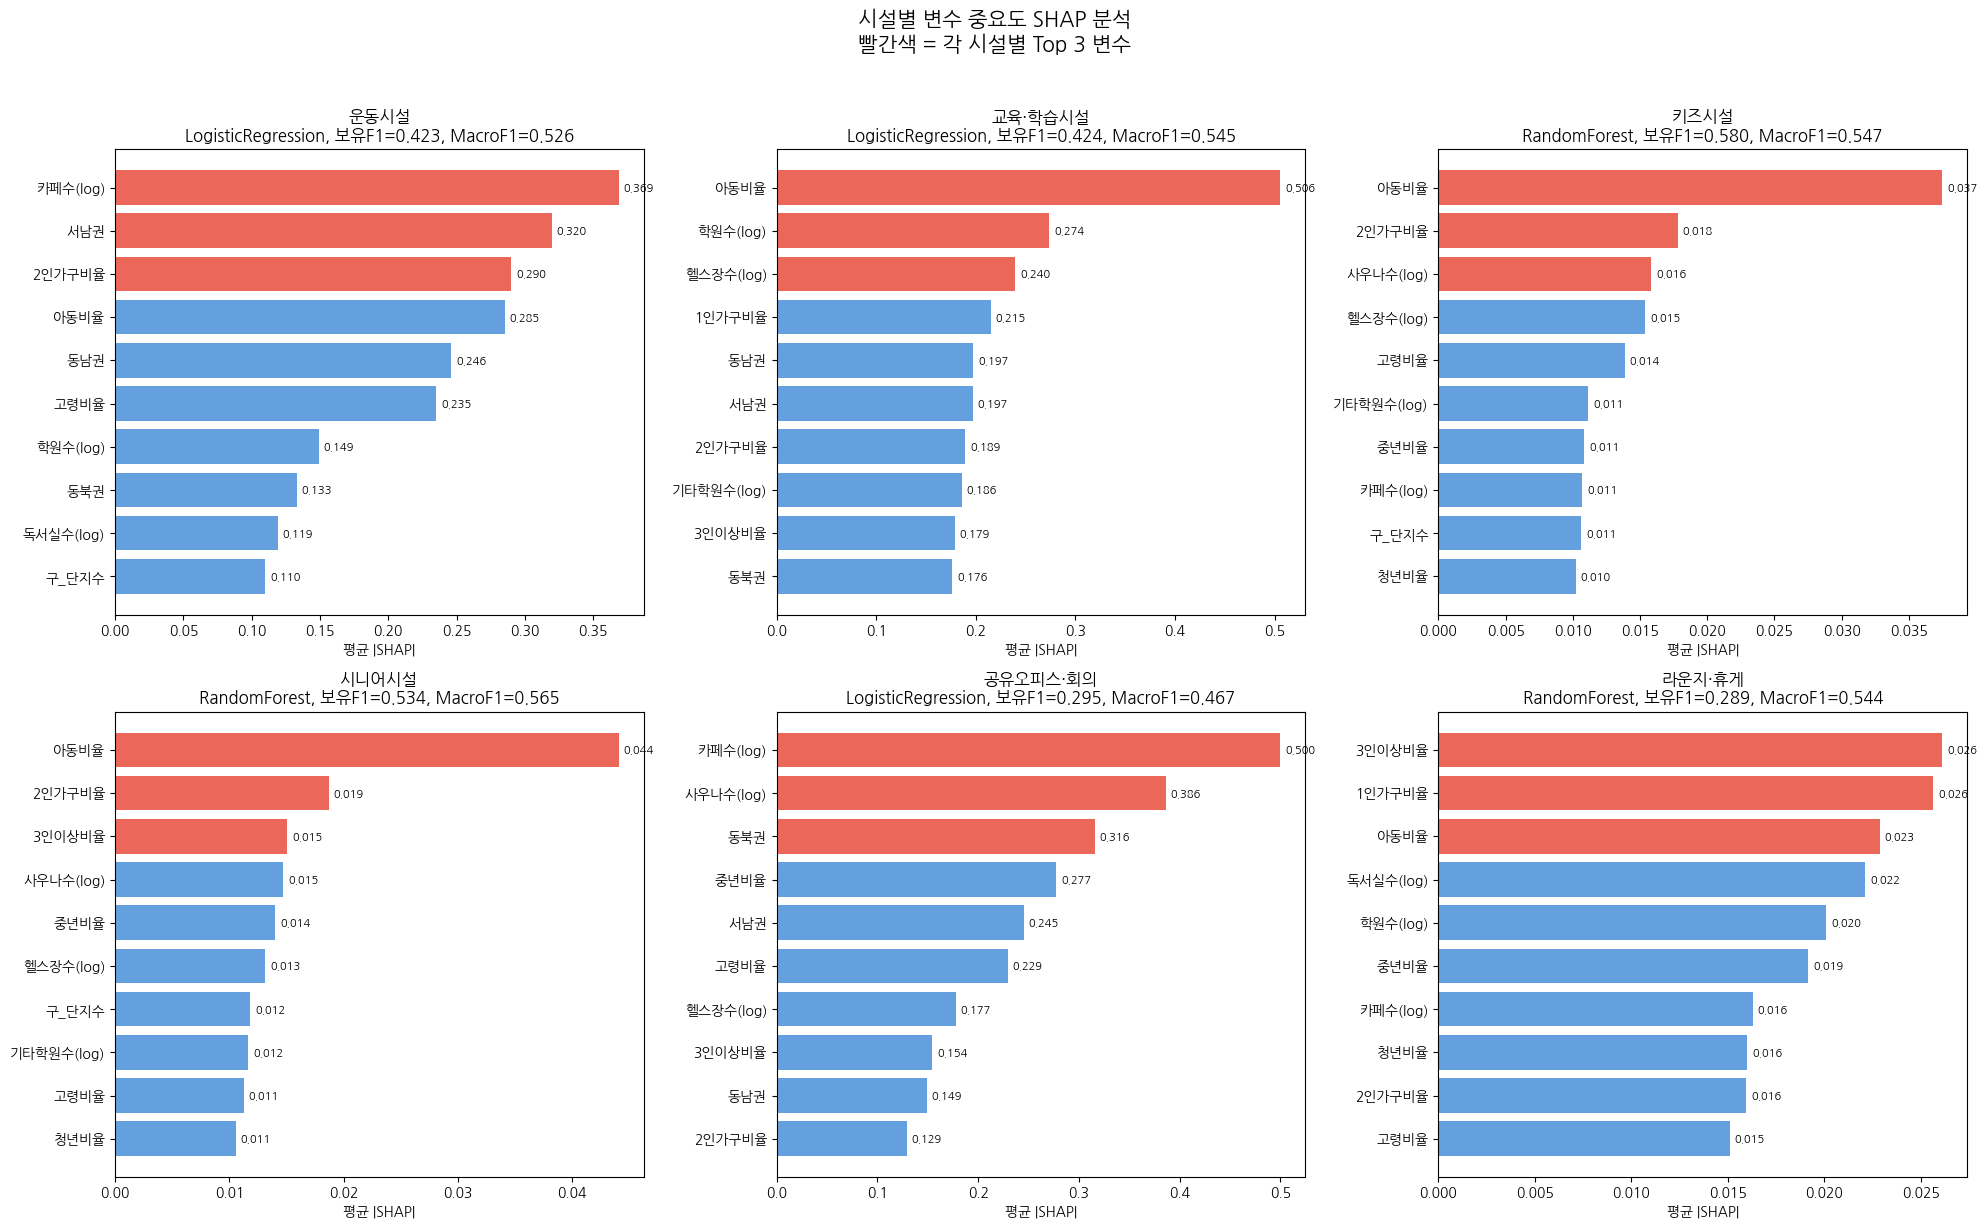


저장 완료: charts/chart8_shap_importance.png

=== Q1~Q4 SHAP 가설 검증 요약 ===
  가설                    내용 feature_label   target              model  rank  mean_abs_shap 중요도수준  feature_value_shap_corr   단변량상관    평균차이        SHAP_방향해석
  Q1 1인가구비율 ↑ → 공유오피스·회의 ↑        1인가구비율 공유오피스_회의 LogisticRegression    12         0.0998    낮음                   1.0000  0.0038  0.0011  값 증가 시 보유 방향(+)
  Q2       아동비율 ↑ → 키즈시설 ↑          아동비율     키즈시설       RandomForest     1         0.0375    상위                   0.8372  0.1435  0.0047  값 증가 시 보유 방향(+)
  Q3      고령비율 ↑ → 시니어시설 ↑          고령비율    시니어시설       RandomForest     9         0.0112    낮음                  -0.2190 -0.0832 -0.0081 값 증가 시 미보유 방향(-)
Q4-1   카페수 ↑ → 공유오피스·회의 변화      카페수(log) 공유오피스_회의 LogisticRegression     1         0.4999    상위                  -1.0000  0.0483 16.7974 값 증가 시 미보유 방향(-)
Q4-2      헬스장수 ↑ → 운동시설 변화     헬스장수(log)     운동시설 LogisticRegression    11         0.0893    낮음                   1.0000 -0.0122 -1.1030  값 증가 시 보유 방향(+)
Q4-3 

In [ ]:
# ============================================================
# 10단계. SHAP 변수 중요도 분석
# ============================================================

import os
import json
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import joblib
import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 0. SHAP 설치 확인
# ------------------------------------------------------------

try:
    import shap
    print("shap 로드 완료")
except ImportError:
    print("shap 미설치 → 설치 중...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "shap", "-q"],
        check=False
    )
    import shap
    print("shap 설치 및 로드 완료")


# ------------------------------------------------------------
# 1. 한글 폰트 설정
# ------------------------------------------------------------

try:
    subprocess.run(
        ["apt-get", "install", "-y", "fonts-nanum"],
        capture_output=True,
        check=False
    )

    fm._load_fontmanager(try_read_cache=False)

    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fe = fm.FontEntry(fname=font_path, name="NanumGothic")
    fm.fontManager.ttflist.insert(0, fe)

    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

    print("한글 폰트 설정 완료")
except Exception as e:
    print("한글 폰트 설정 실패:", e)


# ------------------------------------------------------------
# 2. 데이터 및 설정 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


DATA_PATH = "apt_final_1123.csv"
FEATURE_CONFIG_PATH = "step7_feature_config.json"
MODEL_CONFIG_PATH = "step9_model_config.json"
BEST_SUMMARY_PATH = "step9_best_model_summary.csv"
MODEL_DIR = Path("models_step9")

if not Path(DATA_PATH).exists():
    raise FileNotFoundError("apt_final_1123.csv가 없습니다. 7단계를 먼저 실행하세요.")

if not Path(FEATURE_CONFIG_PATH).exists():
    raise FileNotFoundError("step7_feature_config.json이 없습니다. 7단계를 먼저 실행하세요.")

if not Path(MODEL_CONFIG_PATH).exists():
    raise FileNotFoundError("step9_model_config.json이 없습니다. 9단계를 먼저 실행하세요.")

if not MODEL_DIR.exists():
    raise FileNotFoundError("models_step9 폴더가 없습니다. 9단계를 먼저 실행하세요.")


apt_final = read_csv_safely(DATA_PATH)

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = json.load(f)

with open(MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    model_config = json.load(f)

best_summary = read_csv_safely(BEST_SUMMARY_PATH)

TARGETS = feature_config["TARGETS"]
FEATURES_FINAL = feature_config["FEATURES_FINAL"]
best_model_map = model_config["best_model_map"]

X = apt_final[FEATURES_FINAL].copy()

for col in FEATURES_FINAL:
    X[col] = pd.to_numeric(X[col], errors="coerce")

if X.isna().sum().sum() > 0:
    X = X.fillna(X.mean(numeric_only=True))

print("\n=== SHAP 분석 입력 확인 ===")
print("단지 수:", f"{len(apt_final):,}개")
print("타겟:", TARGETS)
print("피처 수:", len(FEATURES_FINAL))
print("채택 모델:", best_model_map)


# ------------------------------------------------------------
# 3. 라벨 정의
# ------------------------------------------------------------

TARGET_LABELS = {
    "운동시설": "운동시설",
    "교육_학습시설": "교육·학습시설",
    "키즈시설": "키즈시설",
    "시니어시설": "시니어시설",
    "공유오피스_회의": "공유오피스·회의",
    "라운지_휴게": "라운지·휴게"
}

FEATURE_LABELS = {
    "ratio_child": "아동비율",
    "ratio_elderly": "고령비율",
    "ratio_young": "청년비율",
    "ratio_middle": "중년비율",
    "ratio_1person": "1인가구비율",
    "ratio_2person": "2인가구비율",
    "ratio_3plus": "3인이상비율",

    "카페수_log": "카페수(log)",
    "헬스장수_log": "헬스장수(log)",
    "학원수_log": "학원수(log)",
    "기타학원수_log": "기타학원수(log)",
    "독서실수_log": "독서실수(log)",
    "사우나수_log": "사우나수(log)",

    "구_단지수": "구_단지수",
    "생활권역_동남권": "동남권",
    "생활권역_동북권": "동북권",
    "생활권역_서남권": "서남권",
    "생활권역_서북권": "서북권"
}


def label_feature(x):
    return FEATURE_LABELS.get(x, x)


def label_target(x):
    return TARGET_LABELS.get(x, x)


# ------------------------------------------------------------
# 4. SHAP 값 정리 함수
# ------------------------------------------------------------

def normalize_shap_values(raw_values, n_features):
    """
    shap_values 결과를 항상 (n_samples, n_features) 형태로 변환한다.
    이진분류에서는 보유=1 클래스 SHAP 값을 사용한다.
    """
    # shap.Explanation 객체 대응
    if hasattr(raw_values, "values"):
        raw_values = raw_values.values

    # list인 경우: [class0, class1]
    if isinstance(raw_values, list):
        values = raw_values[1]
    else:
        values = raw_values

    values = np.array(values)

    # (n_samples, n_features, 2) 형태
    if values.ndim == 3:
        if values.shape[2] == 2:
            values = values[:, :, 1]
        elif values.shape[1] == n_features:
            values = values[:, :, 0]
        else:
            values = np.squeeze(values)

    # 혹시 transpose된 경우
    if values.ndim == 2 and values.shape[0] == n_features and values.shape[1] != n_features:
        values = values.T

    if values.ndim != 2:
        raise ValueError(f"SHAP 값 shape 오류: {values.shape}")

    if values.shape[1] != n_features:
        raise ValueError(f"피처 수 불일치: shap={values.shape}, n_features={n_features}")

    return values


def get_shap_values_for_model(model, model_name, X):
    """
    LogisticRegression pipeline과 RandomForest 모두 처리.
    LR은 LinearExplainer를 우선 사용하고, 실패하면 표준화 X * 계수 방식으로 대체한다.
    """
    n_features = X.shape[1]

    if model_name == "LogisticRegression":
        scaler = model.named_steps["scaler"]
        lr_model = model.named_steps["model"]

        X_scaled = pd.DataFrame(
            scaler.transform(X),
            columns=X.columns,
            index=X.index
        )

        try:
            explainer = shap.LinearExplainer(lr_model, X_scaled)
            raw_values = explainer.shap_values(X_scaled)
            shap_values = normalize_shap_values(raw_values, n_features)
            method = "LinearExplainer"
        except Exception as e:
            print("LinearExplainer 실패 → 계수 기반 기여도로 대체:", e)
            coef = lr_model.coef_[0]
            shap_values = X_scaled.values * coef
            method = "LR_coef_contribution"

        return shap_values, method

    elif model_name == "RandomForest":
        explainer = shap.TreeExplainer(model)
        raw_values = explainer.shap_values(X)
        shap_values = normalize_shap_values(raw_values, n_features)
        method = "TreeExplainer"

        return shap_values, method

    else:
        raise ValueError(f"지원하지 않는 모델명: {model_name}")


# ------------------------------------------------------------
# 5. 시설별 SHAP 중요도 계산
# ------------------------------------------------------------

shap_values_by_target = {}
shap_method_by_target = {}
importance_rows = []

print("\nSHAP 계산 시작...\n")

for target in TARGETS:
    model_name = best_model_map[target]
    model_path = MODEL_DIR / f"best_model_{target}.pkl"

    if not model_path.exists():
        raise FileNotFoundError(f"모델 파일 없음: {model_path}")

    model = joblib.load(model_path)

    shap_values, method = get_shap_values_for_model(
        model=model,
        model_name=model_name,
        X=X
    )

    shap_values_by_target[target] = shap_values
    shap_method_by_target[target] = method

    print(f"{target:15s} | {model_name:20s} | {method:20s} | shape={shap_values.shape}")

    mean_abs = np.abs(shap_values).mean(axis=0)

    for i, feat in enumerate(FEATURES_FINAL):
        # 값이 커질수록 보유=1 방향으로 미는지 확인하기 위한 보조 지표
        shap_value_corr = pd.Series(X[feat]).corr(pd.Series(shap_values[:, i]))

        importance_rows.append({
            "target": target,
            "model": model_name,
            "shap_method": method,
            "feature": feat,
            "feature_label": label_feature(feat),
            "mean_abs_shap": mean_abs[i],
            "feature_value_shap_corr": shap_value_corr
        })


shap_importance_long = pd.DataFrame(importance_rows)

# 순위 부여
shap_importance_long["rank"] = (
    shap_importance_long
    .groupby("target")["mean_abs_shap"]
    .rank(ascending=False, method="first")
    .astype(int)
)

shap_importance_long = shap_importance_long.sort_values(
    ["target", "rank"]
).reset_index(drop=True)


print("\n=== 시설별 SHAP 중요도 Top 5 ===")

shap_top5 = (
    shap_importance_long
    .sort_values(["target", "rank"])
    .groupby("target")
    .head(5)
    .copy()
)

print(
    shap_top5[
        ["target", "rank", "feature_label", "mean_abs_shap", "feature_value_shap_corr"]
    ]
    .assign(
        mean_abs_shap=lambda d: d["mean_abs_shap"].round(4),
        feature_value_shap_corr=lambda d: d["feature_value_shap_corr"].round(4)
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. SHAP Bar Chart 생성
# ------------------------------------------------------------

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, target in enumerate(TARGETS):
    ax = axes[idx]

    sub = (
        shap_importance_long[shap_importance_long["target"] == target]
        .sort_values("mean_abs_shap", ascending=False)
        .head(10)
        .sort_values("mean_abs_shap", ascending=True)
    )

    model_name = best_model_map[target]

    row_metric = best_summary[best_summary["target"] == target].iloc[0]
    f1_pos = row_metric["f1_pos_mean"]
    f1_macro = row_metric["f1_macro_mean"]

    labels = sub["feature_label"].tolist()
    values = sub["mean_abs_shap"].values

    colors = [
        "#E74C3C" if i >= len(values) - 3 else "#4A90D9"
        for i in range(len(values))
    ]

    ax.barh(labels, values, color=colors, alpha=0.85)

    ax.set_title(
        f"{label_target(target)}\n"
        f"{model_name}, 보유F1={f1_pos:.3f}, MacroF1={f1_macro:.3f}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("평균 |SHAP|")

    for y_pos, val in enumerate(values):
        ax.text(
            val + values.max() * 0.01,
            y_pos,
            f"{val:.3f}",
            va="center",
            fontsize=8
        )

plt.suptitle(
    "시설별 변수 중요도 SHAP 분석\n"
    "빨간색 = 각 시설별 Top 3 변수",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

chart_path = CHART_DIR / "chart8_shap_importance.png"
plt.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"\n저장 완료: {chart_path}")


# ------------------------------------------------------------
# 7. Q1~Q4 SHAP 기반 가설 요약
# ------------------------------------------------------------

def get_shap_info(target, feature):
    sub = shap_importance_long[
        (shap_importance_long["target"] == target)
        & (shap_importance_long["feature"] == feature)
    ]

    if len(sub) == 0:
        return None

    return sub.iloc[0].to_dict()


def raw_feature_name(feature):
    """
    log 변수의 원 변수명 반환.
    예: 카페수_log → 카페수
    """
    return feature.replace("_log", "")


hypothesis_specs = [
    {
        "가설": "Q1",
        "내용": "1인가구비율 ↑ → 공유오피스·회의 ↑",
        "feature": "ratio_1person",
        "target": "공유오피스_회의",
        "expected_direction": "+"
    },
    {
        "가설": "Q2",
        "내용": "아동비율 ↑ → 키즈시설 ↑",
        "feature": "ratio_child",
        "target": "키즈시설",
        "expected_direction": "+"
    },
    {
        "가설": "Q3",
        "내용": "고령비율 ↑ → 시니어시설 ↑",
        "feature": "ratio_elderly",
        "target": "시니어시설",
        "expected_direction": "+"
    },
    {
        "가설": "Q4-1",
        "내용": "카페수 ↑ → 공유오피스·회의 변화",
        "feature": "카페수_log",
        "target": "공유오피스_회의",
        "expected_direction": "-"
    },
    {
        "가설": "Q4-2",
        "내용": "헬스장수 ↑ → 운동시설 변화",
        "feature": "헬스장수_log",
        "target": "운동시설",
        "expected_direction": "-"
    },
    {
        "가설": "Q4-3",
        "내용": "학원수 ↑ → 교육·학습시설 변화",
        "feature": "학원수_log",
        "target": "교육_학습시설",
        "expected_direction": "-"
    },
    {
        "가설": "Q4-4",
        "내용": "독서실수 ↑ → 교육·학습시설 변화",
        "feature": "독서실수_log",
        "target": "교육_학습시설",
        "expected_direction": "-"
    }
]

hypothesis_rows = []

for spec in hypothesis_specs:
    target = spec["target"]
    feat = spec["feature"]

    info = get_shap_info(target, feat)

    if info is None:
        continue

    # 상관계수는 모델에 들어간 feature 기준
    corr_model_feat = apt_final[[feat, target]].corr().iloc[0, 1]

    # 원 변수 평균 차이도 같이 계산
    raw_feat = raw_feature_name(feat)

    if raw_feat in apt_final.columns:
        no_mean = apt_final.loc[apt_final[target] == 0, raw_feat].mean()
        yes_mean = apt_final.loc[apt_final[target] == 1, raw_feat].mean()
        diff = yes_mean - no_mean
    else:
        no_mean = apt_final.loc[apt_final[target] == 0, feat].mean()
        yes_mean = apt_final.loc[apt_final[target] == 1, feat].mean()
        diff = yes_mean - no_mean

    # 방향 해석
    shap_corr = info["feature_value_shap_corr"]

    if shap_corr > 0:
        shap_direction = "값 증가 시 보유 방향(+)"
    elif shap_corr < 0:
        shap_direction = "값 증가 시 미보유 방향(-)"
    else:
        shap_direction = "방향 불명확"

    # 중요도 판정
    rank = int(info["rank"])

    if rank <= 3:
        importance_level = "상위"
    elif rank <= 6:
        importance_level = "중간"
    else:
        importance_level = "낮음"

    hypothesis_rows.append({
        "가설": spec["가설"],
        "내용": spec["내용"],
        "target": target,
        "feature": feat,
        "feature_label": label_feature(feat),
        "model": info["model"],
        "rank": rank,
        "mean_abs_shap": info["mean_abs_shap"],
        "중요도수준": importance_level,
        "feature_value_shap_corr": shap_corr,
        "SHAP_방향해석": shap_direction,
        "단변량상관": corr_model_feat,
        "미보유_원변수평균": no_mean,
        "보유_원변수평균": yes_mean,
        "평균차이": diff
    })

hypothesis_shap_summary = pd.DataFrame(hypothesis_rows)

print("\n=== Q1~Q4 SHAP 가설 검증 요약 ===")

print(
    hypothesis_shap_summary[
        [
            "가설",
            "내용",
            "feature_label",
            "target",
            "model",
            "rank",
            "mean_abs_shap",
            "중요도수준",
            "feature_value_shap_corr",
            "단변량상관",
            "평균차이",
            "SHAP_방향해석"
        ]
    ]
    .assign(
        mean_abs_shap=lambda d: d["mean_abs_shap"].round(4),
        feature_value_shap_corr=lambda d: d["feature_value_shap_corr"].round(4),
        단변량상관=lambda d: d["단변량상관"].round(4),
        평균차이=lambda d: d["평균차이"].round(4)
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. 시설별 Top 3 텍스트 요약
# ------------------------------------------------------------

print("\n=== 시설별 SHAP Top 3 변수 ===")

top3_rows = []

for target in TARGETS:
    sub = (
        shap_importance_long[shap_importance_long["target"] == target]
        .sort_values("rank")
        .head(3)
    )

    top3_text = " > ".join(sub["feature_label"].tolist())

    row_metric = best_summary[best_summary["target"] == target].iloc[0]

    top3_rows.append({
        "target": target,
        "model": best_model_map[target],
        "f1_pos": row_metric["f1_pos_mean"],
        "f1_macro": row_metric["f1_macro_mean"],
        "top3": top3_text
    })

    print(
        f"{target:15s} | {best_model_map[target]:20s} | "
        f"보유F1={row_metric['f1_pos_mean']:.3f}, "
        f"MacroF1={row_metric['f1_macro_mean']:.3f} | "
        f"{top3_text}"
    )

shap_top3_summary = pd.DataFrame(top3_rows)


# ------------------------------------------------------------
# 9. 저장
# ------------------------------------------------------------

shap_importance_long.to_csv(
    "step10_shap_importance_long.csv",
    index=False,
    encoding="utf-8-sig"
)

shap_top5.to_csv(
    "step10_shap_top5.csv",
    index=False,
    encoding="utf-8-sig"
)

shap_top3_summary.to_csv(
    "step10_shap_top3_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

hypothesis_shap_summary.to_csv(
    "step10_hypothesis_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 10단계 완료")
print("저장 파일:")
print(" - charts/chart8_shap_importance.png")
print(" - step10_shap_importance_long.csv")
print(" - step10_shap_top5.csv")
print(" - step10_shap_top3_summary.csv")
print(" - step10_hypothesis_shap_summary.csv")

print("\n다음 단계에서는 Q4 방향 분석 차트와 최종 결론표를 정리하겠습니다.")

한글 폰트 설정 완료
데이터 로드 완료
단지 수: 1,123개
SHAP 가설 요약 행 수: 7


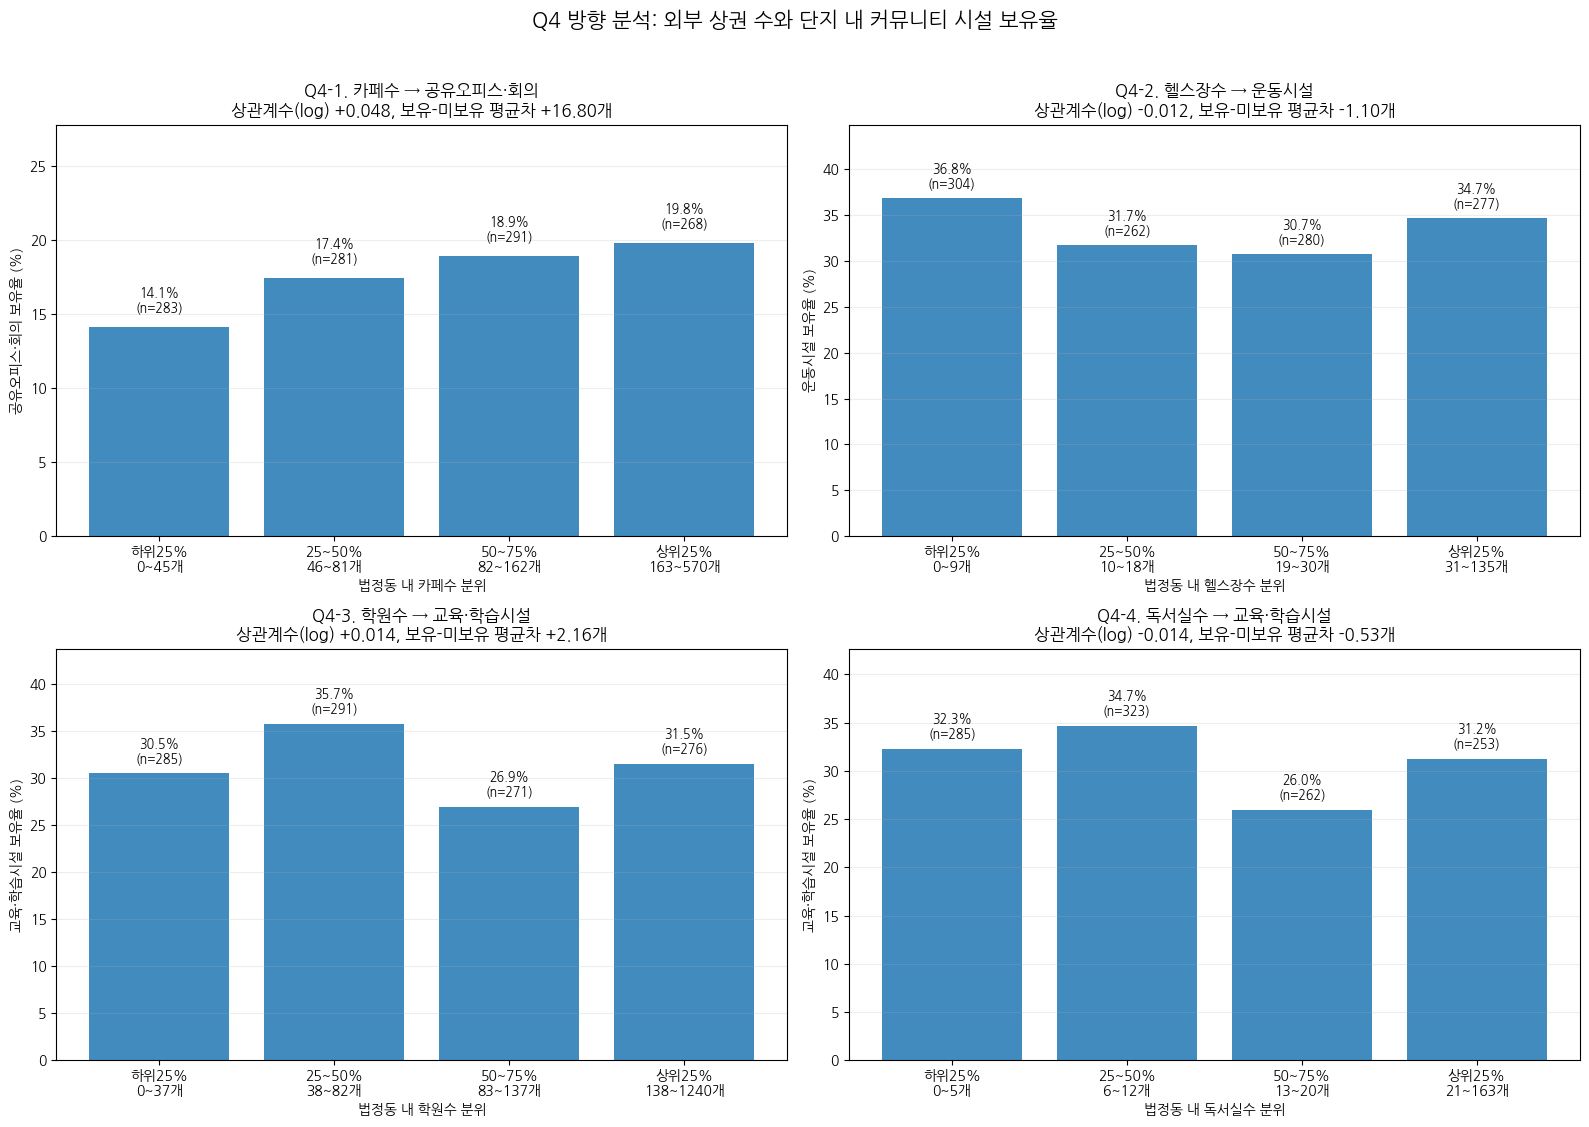

저장 완료: charts/chart9_q4_direction.png

=== Q4 방향 분석 요약 ===
가설후보             내용   피처       타겟  미보유_평균업소수  보유_평균업소수  보유-미보유_평균차  상관계수_log  하위25_보유율(%)  상위25_보유율(%)  상위-하위_보유율차(%p)               분위해석
Q4-1 카페수 → 공유오피스·회의  카페수 공유오피스_회의     115.52    132.31       16.80    0.0483         14.1         19.8             5.6 분위 기준 보완/동반 가능성(+)
Q4-2    헬스장수 → 운동시설 헬스장수     운동시설      27.09     25.98       -1.10   -0.0122         36.8         34.7            -2.2    분위 기준 대체 가능성(-)
Q4-3  학원수 → 교육·학습시설  학원수  교육_학습시설     123.87    126.03        2.16    0.0138         30.5         31.5             1.0       분위 기준 약함/불명확
Q4-4 독서실수 → 교육·학습시설 독서실수  교육_학습시설      17.79     17.26       -0.53   -0.0139         32.3         31.2            -1.1       분위 기준 약함/불명확

=== Q1~Q4 최종 결론표 ===
가설                           가설 내용                                         단변량 근거                                               다변량/SHAP 근거               방향  최종 판정                                                                  

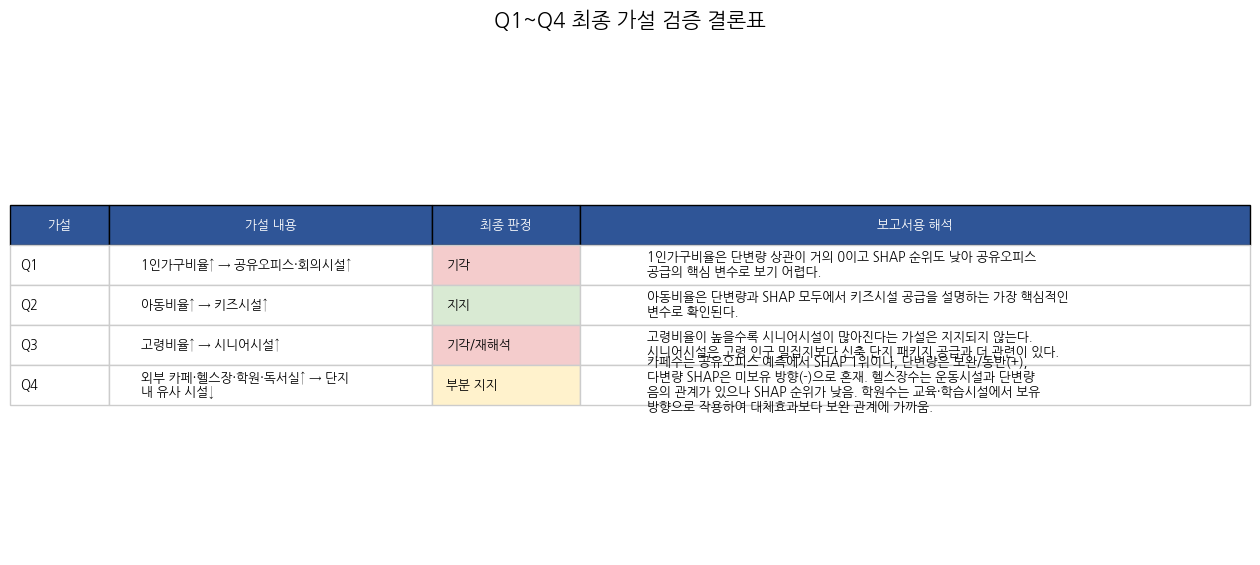

저장 완료: charts/chart10_hypothesis_final_conclusion.png

=== 보고서용 핵심 문장 ===
   구분                                                                                                                      문장
전체 결론                                 본 연구는 실제 이용 수요가 아닌 건축 인허가상 커뮤니티 시설 공급 여부를 분석 대상으로 하므로, 결과는 수요 예측이 아니라 공급 패턴 예측으로 해석하였다.
   Q1                                                            1인가구비율은 공유오피스·회의시설 공급과 단변량 상관이 거의 없고 SHAP 순위도 낮아, Q1은 기각하였다.
   Q2                                                   아동비율은 키즈시설 예측에서 SHAP 1위 변수로 나타났고, 보유 단지의 아동비율도 미보유 단지보다 높아 Q2는 지지되었다.
   Q3                                      고령비율은 시니어시설 공급과 음의 방향을 보였으며 SHAP 중요도도 낮아, 고령 인구 밀집지와 시니어시설 공급지 사이의 지리적 불일치가 확인되었다.
   Q4 Q4는 부분 지지로 해석하였다. 카페수는 공유오피스 예측에서 중요하지만 단변량과 다변량 방향이 엇갈렸고, 헬스장수와 운동시설의 대체효과는 약하게 관찰되었다. 학원수는 교육·학습시설과 오히려 보완적 관계에 가까웠다.
 주의사항                                            SHAP의 평균 절댓값은 변수 영향력의 크기를 의미하며, 방향성은 feature-SHAP 상관과 분위별 보유율 분석을 함께 보아야 한다.

✅ 11단계 완료
저장 파일:
 - charts/chart9_q4_direct

In [ ]:
# ============================================================
# 11단계. Q4 방향 분석 차트 + Q1~Q4 최종 결론표 생성
# ============================================================

import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------

try:
    subprocess.run(
        ["apt-get", "install", "-y", "fonts-nanum"],
        capture_output=True,
        check=False
    )

    fm._load_fontmanager(try_read_cache=False)

    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fe = fm.FontEntry(fname=font_path, name="NanumGothic")
    fm.fontManager.ttflist.insert(0, fe)

    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

    print("한글 폰트 설정 완료")
except Exception as e:
    print("한글 폰트 설정 실패:", e)


# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


DATA_PATH = "apt_final_1123.csv"
SHAP_SUMMARY_PATH = "step10_hypothesis_shap_summary.csv"
SHAP_IMPORTANCE_PATH = "step10_shap_importance_long.csv"
BEST_MODEL_PATH = "step9_best_model_summary.csv"

for path in [DATA_PATH, SHAP_SUMMARY_PATH, SHAP_IMPORTANCE_PATH, BEST_MODEL_PATH]:
    if not Path(path).exists():
        raise FileNotFoundError(f"필수 파일이 없습니다: {path}")

apt_final = read_csv_safely(DATA_PATH)
hypothesis_shap = read_csv_safely(SHAP_SUMMARY_PATH)
shap_importance = read_csv_safely(SHAP_IMPORTANCE_PATH)
best_model_summary = read_csv_safely(BEST_MODEL_PATH)

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

print("데이터 로드 완료")
print("단지 수:", f"{len(apt_final):,}개")
print("SHAP 가설 요약 행 수:", len(hypothesis_shap))


# ------------------------------------------------------------
# 2. 라벨 정의
# ------------------------------------------------------------

TARGET_LABELS = {
    "운동시설": "운동시설",
    "교육_학습시설": "교육·학습시설",
    "키즈시설": "키즈시설",
    "시니어시설": "시니어시설",
    "공유오피스_회의": "공유오피스·회의",
    "라운지_휴게": "라운지·휴게"
}

FEATURE_LABELS = {
    "ratio_child": "아동비율",
    "ratio_elderly": "고령비율",
    "ratio_young": "청년비율",
    "ratio_middle": "중년비율",
    "ratio_1person": "1인가구비율",
    "ratio_2person": "2인가구비율",
    "ratio_3plus": "3인이상비율",

    "카페수": "카페수",
    "헬스장수": "헬스장수",
    "학원수": "학원수",
    "기타학원수": "기타학원수",
    "독서실수": "독서실수",
    "사우나수": "사우나수",

    "카페수_log": "카페수(log)",
    "헬스장수_log": "헬스장수(log)",
    "학원수_log": "학원수(log)",
    "기타학원수_log": "기타학원수(log)",
    "독서실수_log": "독서실수(log)",
    "사우나수_log": "사우나수(log)"
}


def label_target(x):
    return TARGET_LABELS.get(x, x)


def label_feature(x):
    return FEATURE_LABELS.get(x, x)


# ------------------------------------------------------------
# 3. 분위별 보유율 계산 함수
# ------------------------------------------------------------

def make_quartile_rate_table(data, feature, target, q=4):
    """
    feature를 q분위로 나누고, 각 분위별 target 보유율을 계산한다.
    사람이 읽기 쉬운 라벨도 함께 생성한다.
    """
    tmp = data[[feature, target]].dropna().copy()

    if tmp[feature].nunique() < q:
        raise ValueError(f"{feature}의 고유값이 너무 적어 {q}분위 계산 불가")

    tmp["bin"] = pd.qcut(
        tmp[feature],
        q=q,
        duplicates="drop"
    )

    rate = (
        tmp
        .groupby("bin", observed=True, sort=True)
        .agg(
            단지수=(target, "size"),
            보유율=(target, "mean"),
            평균값=(feature, "mean")
        )
        .reset_index()
        .sort_values("평균값")
        .reset_index(drop=True)
    )

    if len(rate) == 4:
        quartile_names = ["하위25%", "25~50%", "50~75%", "상위25%"]
    else:
        quartile_names = [f"{i+1}분위" for i in range(len(rate))]

    labels = []

    for i, interval in enumerate(rate["bin"]):
        left = interval.left
        right = interval.right

        if left < 0:
            start = 0
        else:
            start = int(np.floor(left)) + 1

        end = int(np.floor(right))

        labels.append(f"{quartile_names[i]}\n{start}~{end}개")

    rate["분위라벨"] = labels
    rate["보유율(%)"] = rate["보유율"] * 100

    return rate


def get_mean_diff_and_corr(data, feature, target, use_log=False):
    """
    보유/미보유 평균 차이와 상관계수 계산.
    use_log=True면 상관계수는 log 변수 기준으로 계산.
    """
    feature_for_corr = feature + "_log" if use_log and feature + "_log" in data.columns else feature

    no_mean = data.loc[data[target] == 0, feature].mean()
    yes_mean = data.loc[data[target] == 1, feature].mean()
    diff = yes_mean - no_mean

    corr = data[[feature_for_corr, target]].corr().iloc[0, 1]

    return no_mean, yes_mean, diff, corr


# ------------------------------------------------------------
# 4. Q4 방향 분석 차트 생성
# ------------------------------------------------------------

q4_specs = [
    {
        "code": "Q4-1",
        "title": "카페수 → 공유오피스·회의",
        "feature": "카페수",
        "target": "공유오피스_회의",
        "expected": "대체효과 기대",
        "interpret_target": "공유오피스·회의 보유율"
    },
    {
        "code": "Q4-2",
        "title": "헬스장수 → 운동시설",
        "feature": "헬스장수",
        "target": "운동시설",
        "expected": "대체효과 기대",
        "interpret_target": "운동시설 보유율"
    },
    {
        "code": "Q4-3",
        "title": "학원수 → 교육·학습시설",
        "feature": "학원수",
        "target": "교육_학습시설",
        "expected": "대체효과 기대",
        "interpret_target": "교육·학습시설 보유율"
    },
    {
        "code": "Q4-4",
        "title": "독서실수 → 교육·학습시설",
        "feature": "독서실수",
        "target": "교육_학습시설",
        "expected": "대체효과 기대",
        "interpret_target": "교육·학습시설 보유율"
    },
]

q4_summary_rows = []
q4_quartile_all = []

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, spec in zip(axes, q4_specs):
    feature = spec["feature"]
    target = spec["target"]

    rate = make_quartile_rate_table(
        data=apt_final,
        feature=feature,
        target=target
    )

    no_mean, yes_mean, diff, corr_log = get_mean_diff_and_corr(
        data=apt_final,
        feature=feature,
        target=target,
        use_log=True
    )

    low_rate = rate.iloc[0]["보유율(%)"]
    high_rate = rate.iloc[-1]["보유율(%)"]
    high_minus_low = high_rate - low_rate

    # 단순 분위 방향 해석
    if high_minus_low < -2:
        quartile_direction = "분위 기준 대체 가능성(-)"
    elif high_minus_low > 2:
        quartile_direction = "분위 기준 보완/동반 가능성(+)"
    else:
        quartile_direction = "분위 기준 약함/불명확"

    # 막대그래프
    ax.bar(
        rate["분위라벨"],
        rate["보유율(%)"],
        alpha=0.85
    )

    for i, row in rate.iterrows():
        ax.text(
            i,
            row["보유율(%)"] + 0.8,
            f"{row['보유율(%)']:.1f}%\n(n={int(row['단지수'])})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(
        f"{spec['code']}. {spec['title']}\n"
        f"상관계수(log) {corr_log:+.3f}, "
        f"보유-미보유 평균차 {diff:+.2f}개",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(f"법정동 내 {feature} 분위")
    ax.set_ylabel(spec["interpret_target"] + " (%)")
    ax.set_ylim(0, max(rate["보유율(%)"].max() + 8, 10))
    ax.grid(axis="y", alpha=0.22)

    # 요약 저장
    q4_summary_rows.append({
        "가설후보": spec["code"],
        "내용": spec["title"],
        "피처": feature,
        "타겟": target,
        "미보유_평균업소수": no_mean,
        "보유_평균업소수": yes_mean,
        "보유-미보유_평균차": diff,
        "상관계수_log": corr_log,
        "하위25_보유율(%)": low_rate,
        "상위25_보유율(%)": high_rate,
        "상위-하위_보유율차(%p)": high_minus_low,
        "분위해석": quartile_direction
    })

    tmp_rate = rate.copy()
    tmp_rate["가설후보"] = spec["code"]
    tmp_rate["피처"] = feature
    tmp_rate["타겟"] = target
    q4_quartile_all.append(tmp_rate)

plt.suptitle(
    "Q4 방향 분석: 외부 상권 수와 단지 내 커뮤니티 시설 보유율",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

chart9_path = CHART_DIR / "chart9_q4_direction.png"
plt.savefig(chart9_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"저장 완료: {chart9_path}")

q4_direction_summary = pd.DataFrame(q4_summary_rows)
q4_quartile_rates = pd.concat(q4_quartile_all, ignore_index=True)

print("\n=== Q4 방향 분석 요약 ===")
print(
    q4_direction_summary
    .assign(
        미보유_평균업소수=lambda d: d["미보유_평균업소수"].round(2),
        보유_평균업소수=lambda d: d["보유_평균업소수"].round(2),
        **{"보유-미보유_평균차": lambda d: d["보유-미보유_평균차"].round(2)},
        상관계수_log=lambda d: d["상관계수_log"].round(4),
        **{"하위25_보유율(%)": lambda d: d["하위25_보유율(%)"].round(1)},
        **{"상위25_보유율(%)": lambda d: d["상위25_보유율(%)"].round(1)},
        **{"상위-하위_보유율차(%p)": lambda d: d["상위-하위_보유율차(%p)"].round(1)}
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. SHAP 요약과 결합한 Q1~Q4 최종 결론표 생성
# ------------------------------------------------------------

def get_hyp_row(code):
    sub = hypothesis_shap[hypothesis_shap["가설"] == code].copy()
    if len(sub) == 0:
        return None
    return sub.iloc[0]


# Q1~Q3는 step10 SHAP 요약 그대로 사용
q1 = get_hyp_row("Q1")
q2 = get_hyp_row("Q2")
q3 = get_hyp_row("Q3")
q41 = get_hyp_row("Q4-1")
q42 = get_hyp_row("Q4-2")
q43 = get_hyp_row("Q4-3")
q44 = get_hyp_row("Q4-4")


final_conclusion_rows = []

# Q1
final_conclusion_rows.append({
    "가설": "Q1",
    "가설 내용": "1인가구비율↑ → 공유오피스·회의시설↑",
    "단변량 근거": f"상관 {q1['단변량상관']:+.3f}, 평균차 {q1['평균차이']*100:+.2f}%p",
    "다변량/SHAP 근거": f"{q1['feature_label']} SHAP {int(q1['rank'])}위, 중요도 {q1['mean_abs_shap']:.4f}",
    "방향": q1["SHAP_방향해석"],
    "최종 판정": "기각",
    "보고서용 해석": "1인가구비율은 단변량 상관이 거의 0이고 SHAP 순위도 낮아 공유오피스 공급의 핵심 변수로 보기 어렵다."
})

# Q2
final_conclusion_rows.append({
    "가설": "Q2",
    "가설 내용": "아동비율↑ → 키즈시설↑",
    "단변량 근거": f"상관 {q2['단변량상관']:+.3f}, 평균차 {q2['평균차이']*100:+.2f}%p",
    "다변량/SHAP 근거": f"{q2['feature_label']} SHAP {int(q2['rank'])}위, 중요도 {q2['mean_abs_shap']:.4f}",
    "방향": q2["SHAP_방향해석"],
    "최종 판정": "지지",
    "보고서용 해석": "아동비율은 단변량과 SHAP 모두에서 키즈시설 공급을 설명하는 가장 핵심적인 변수로 확인된다."
})

# Q3
final_conclusion_rows.append({
    "가설": "Q3",
    "가설 내용": "고령비율↑ → 시니어시설↑",
    "단변량 근거": f"상관 {q3['단변량상관']:+.3f}, 평균차 {q3['평균차이']*100:+.2f}%p",
    "다변량/SHAP 근거": f"{q3['feature_label']} SHAP {int(q3['rank'])}위, 중요도 {q3['mean_abs_shap']:.4f}",
    "방향": q3["SHAP_방향해석"],
    "최종 판정": "기각/재해석",
    "보고서용 해석": "고령비율이 높을수록 시니어시설이 많아진다는 가설은 지지되지 않는다. 시니어시설은 고령 인구 밀집지보다 신축 단지 패키지 공급과 더 관련이 있다."
})

# Q4 전체 결론은 여러 후보를 종합
q4_detail_text = (
    "카페수는 공유오피스 예측에서 SHAP 1위이나, "
    "단변량은 보완/동반(+), 다변량 SHAP은 미보유 방향(-)으로 혼재. "
    "헬스장수는 운동시설과 단변량 음의 관계가 있으나 SHAP 순위가 낮음. "
    "학원수는 교육·학습시설에서 보유 방향으로 작용하여 대체효과보다 보완 관계에 가까움."
)

final_conclusion_rows.append({
    "가설": "Q4",
    "가설 내용": "외부 카페·헬스장·학원·독서실↑ → 단지 내 유사 시설↓",
    "단변량 근거": "카페→공유오피스는 양(+), 헬스장→운동시설은 약한 음(-), 학원→교육은 양(+)",
    "다변량/SHAP 근거": (
        f"카페수 SHAP {int(q41['rank'])}위({q41['SHAP_방향해석']}), "
        f"헬스장수 SHAP {int(q42['rank'])}위, "
        f"학원수 SHAP {int(q43['rank'])}위"
    ),
    "방향": "혼재",
    "최종 판정": "부분 지지",
    "보고서용 해석": q4_detail_text
})

hypothesis_final_conclusion = pd.DataFrame(final_conclusion_rows)

print("\n=== Q1~Q4 최종 결론표 ===")
print(hypothesis_final_conclusion.to_string(index=False))


# ------------------------------------------------------------
# 6. 최종 결론표 이미지 생성
# ------------------------------------------------------------

table_for_plot = hypothesis_final_conclusion[
    [
        "가설",
        "가설 내용",
        "최종 판정",
        "보고서용 해석"
    ]
].copy()

# 긴 텍스트 줄바꿈
def wrap_text(text, width=34):
    text = str(text)
    words = text.split(" ")
    lines = []
    current = ""

    for word in words:
        if len(current) + len(word) + 1 <= width:
            current = (current + " " + word).strip()
        else:
            lines.append(current)
            current = word

    if current:
        lines.append(current)

    return "\n".join(lines)


table_for_plot["가설 내용"] = table_for_plot["가설 내용"].apply(lambda x: wrap_text(x, 22))
table_for_plot["보고서용 해석"] = table_for_plot["보고서용 해석"].apply(lambda x: wrap_text(x, 42))

fig, ax = plt.subplots(figsize=(16, 6.5))
ax.axis("off")

table = ax.table(
    cellText=table_for_plot.values,
    colLabels=table_for_plot.columns,
    cellLoc="left",
    colLoc="center",
    loc="center",
    colWidths=[0.08, 0.26, 0.12, 0.54]
)

table.auto_set_font_size(False)
table.set_fontsize(9.2)
table.scale(1, 2.4)

# 헤더 스타일
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#2F5597")
    else:
        if col == 2:
            value = table_for_plot.iloc[row - 1, col]
            if "지지" == value:
                cell.set_facecolor("#D9EAD3")
            elif "부분" in value:
                cell.set_facecolor("#FFF2CC")
            else:
                cell.set_facecolor("#F4CCCC")

        cell.set_edgecolor("#CCCCCC")

plt.title(
    "Q1~Q4 최종 가설 검증 결론표",
    fontsize=15,
    fontweight="bold",
    pad=20
)

chart10_path = CHART_DIR / "chart10_hypothesis_final_conclusion.png"
plt.savefig(chart10_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"저장 완료: {chart10_path}")


# ------------------------------------------------------------
# 7. 보고서용 핵심 문장 저장
# ------------------------------------------------------------

report_sentences = [
    {
        "구분": "전체 결론",
        "문장": (
            "본 연구는 실제 이용 수요가 아닌 건축 인허가상 커뮤니티 시설 공급 여부를 분석 대상으로 하므로, "
            "결과는 수요 예측이 아니라 공급 패턴 예측으로 해석하였다."
        )
    },
    {
        "구분": "Q1",
        "문장": (
            "1인가구비율은 공유오피스·회의시설 공급과 단변량 상관이 거의 없고 SHAP 순위도 낮아, "
            "Q1은 기각하였다."
        )
    },
    {
        "구분": "Q2",
        "문장": (
            "아동비율은 키즈시설 예측에서 SHAP 1위 변수로 나타났고, 보유 단지의 아동비율도 미보유 단지보다 높아 "
            "Q2는 지지되었다."
        )
    },
    {
        "구분": "Q3",
        "문장": (
            "고령비율은 시니어시설 공급과 음의 방향을 보였으며 SHAP 중요도도 낮아, "
            "고령 인구 밀집지와 시니어시설 공급지 사이의 지리적 불일치가 확인되었다."
        )
    },
    {
        "구분": "Q4",
        "문장": (
            "Q4는 부분 지지로 해석하였다. 카페수는 공유오피스 예측에서 중요하지만 단변량과 다변량 방향이 엇갈렸고, "
            "헬스장수와 운동시설의 대체효과는 약하게 관찰되었다. 학원수는 교육·학습시설과 오히려 보완적 관계에 가까웠다."
        )
    },
    {
        "구분": "주의사항",
        "문장": (
            "SHAP의 평균 절댓값은 변수 영향력의 크기를 의미하며, 방향성은 feature-SHAP 상관과 분위별 보유율 분석을 함께 보아야 한다."
        )
    }
]

report_sentence_df = pd.DataFrame(report_sentences)

print("\n=== 보고서용 핵심 문장 ===")
print(report_sentence_df.to_string(index=False))


# ------------------------------------------------------------
# 8. 저장
# ------------------------------------------------------------

q4_direction_summary.to_csv(
    "step11_q4_direction_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

q4_quartile_rates.to_csv(
    "step11_q4_quartile_rates.csv",
    index=False,
    encoding="utf-8-sig"
)

hypothesis_final_conclusion.to_csv(
    "step11_hypothesis_final_conclusion.csv",
    index=False,
    encoding="utf-8-sig"
)

report_sentence_df.to_csv(
    "step11_report_key_sentences.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 11단계 완료")
print("저장 파일:")
print(" - charts/chart9_q4_direction.png")
print(" - charts/chart10_hypothesis_final_conclusion.png")
print(" - step11_q4_direction_summary.csv")
print(" - step11_q4_quartile_rates.csv")
print(" - step11_hypothesis_final_conclusion.csv")
print(" - step11_report_key_sentences.csv")

print("\n다음 단계에서는 최종 보고서에 들어갈 표·문장 정리를 하거나, Streamlit 앱에 새 결과를 반영할 수 있습니다.")

In [ ]:
# ============================================================
# 12단계. 최종 보고서·Streamlit 반영용 산출물 정리
# ============================================================

import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 0. 안전한 CSV 로드 함수
# ------------------------------------------------------------

def read_csv_safely(path):
    for enc in ["utf-8", "utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"CSV 인코딩 확인 필요: {path}")


# ------------------------------------------------------------
# 1. 필수 파일 확인
# ------------------------------------------------------------

required_files = [
    "apt_final_1123.csv",
    "step7_feature_config.json",
    "step7_target_summary.csv",
    "step7_demo_summary.csv",
    "step7_biz_summary.csv",
    "step9_best_model_summary.csv",
    "step9_f1_pos_pivot.csv",
    "step9_f1_macro_pivot.csv",
    "step10_shap_top3_summary.csv",
    "step10_hypothesis_shap_summary.csv",
    "step11_q4_direction_summary.csv",
    "step11_hypothesis_final_conclusion.csv",
    "step11_report_key_sentences.csv",
]

missing = [f for f in required_files if not Path(f).exists()]

if missing:
    print("❌ 아래 파일이 없습니다. 이전 단계를 확인하세요.")
    for f in missing:
        print(" -", f)
    raise FileNotFoundError("필수 산출물 누락")

print("필수 파일 확인 완료")


# ------------------------------------------------------------
# 2. 데이터 로드
# ------------------------------------------------------------

apt_final = read_csv_safely("apt_final_1123.csv")
target_summary = read_csv_safely("step7_target_summary.csv")
demo_summary = read_csv_safely("step7_demo_summary.csv")
biz_summary = read_csv_safely("step7_biz_summary.csv")
best_model_summary = read_csv_safely("step9_best_model_summary.csv")
f1_pos_pivot = read_csv_safely("step9_f1_pos_pivot.csv")
f1_macro_pivot = read_csv_safely("step9_f1_macro_pivot.csv")
shap_top3 = read_csv_safely("step10_shap_top3_summary.csv")
hypothesis_shap = read_csv_safely("step10_hypothesis_shap_summary.csv")
q4_direction = read_csv_safely("step11_q4_direction_summary.csv")
hypothesis_final = read_csv_safely("step11_hypothesis_final_conclusion.csv")
report_sentences = read_csv_safely("step11_report_key_sentences.csv")

with open("step7_feature_config.json", "r", encoding="utf-8") as f:
    feature_config = json.load(f)

TARGETS = feature_config["TARGETS"]
FEATURES_FINAL = feature_config["FEATURES_FINAL"]
BIZ_VARS = feature_config["BIZ_VARS"]
DEMO_FEATURES = feature_config["DEMO_FEATURES"]

print("데이터 로드 완료")


# ------------------------------------------------------------
# 3. 최종 산출물 폴더 생성
# ------------------------------------------------------------

OUT_DIR = Path("final_report_assets")
CHART_OUT = OUT_DIR / "charts"
TABLE_OUT = OUT_DIR / "tables"
DATA_OUT = OUT_DIR / "data"
MODEL_OUT = OUT_DIR / "model_results"
TEXT_OUT = OUT_DIR / "text"

for p in [OUT_DIR, CHART_OUT, TABLE_OUT, DATA_OUT, MODEL_OUT, TEXT_OUT]:
    p.mkdir(parents=True, exist_ok=True)

print("출력 폴더 생성 완료:", OUT_DIR)


# ------------------------------------------------------------
# 4. 보고서용 핵심 수치 요약표 생성
# ------------------------------------------------------------

overview_rows = []

overview_rows.append({
    "항목": "최종 분석 단지 수",
    "값": f"{len(apt_final):,}개",
    "보고서 반영 문구": "최종 분석 대상은 단지키 기준 서울시 신축 아파트 1,123개 단지이다."
})

overview_rows.append({
    "항목": "단지키 중복",
    "값": f"{apt_final['단지키'].duplicated().sum()}개",
    "보고서 반영 문구": "대지위치·건물명 정규화 기반 단지키를 사용하여 중복 단지키는 0개로 확인되었다."
})

overview_rows.append({
    "항목": "자치구 수",
    "값": f"{apt_final['구'].nunique()}개",
    "보고서 반영 문구": "서울 25개 자치구가 모두 포함되었다."
})

overview_rows.append({
    "항목": "모델 타겟 수",
    "값": f"{len(TARGETS)}개",
    "보고서 반영 문구": "운동시설, 교육·학습시설, 키즈시설, 시니어시설, 공유오피스·회의, 라운지·휴게 6개 시설을 모델 타겟으로 설정하였다."
})

overview_rows.append({
    "항목": "최종 모델 피처 수",
    "값": f"{len(FEATURES_FINAL)}개",
    "보고서 반영 문구": "최종 모델 피처는 인구·세대 변수, 원본 상권 log 변수, 지역 통제 변수를 포함한 18개 변수이다."
})

overview_rows.append({
    "항목": "상권 매칭 방식",
    "값": apt_final["상권_매칭방식"].value_counts().to_dict() if "상권_매칭방식" in apt_final.columns else "확인 필요",
    "보고서 반영 문구": "원본 상권정보를 법정동 기준으로 집계하여 모든 단지가 법정동 직접 매칭되었다."
})

overview_rows.append({
    "항목": "모델 평가 메인 지표",
    "값": "보유 클래스 F1",
    "보고서 반영 문구": "모델의 주 평가지표는 시설 보유=1 클래스를 기준으로 한 positive-class F1이며, Macro F1과 Balanced Accuracy를 보조 지표로 함께 제시하였다."
})

overview_df = pd.DataFrame(overview_rows)
overview_df.to_csv(TABLE_OUT / "table_00_final_overview.csv", index=False, encoding="utf-8-sig")


# ------------------------------------------------------------
# 5. 시설 보유율 표 정리
# ------------------------------------------------------------

facility_rate_report = target_summary.copy()

facility_rate_report = facility_rate_report.rename(columns={
    "시설유형": "시설 유형",
    "보유단지수": "보유 단지 수",
    "미보유단지수": "미보유 단지 수",
    "보유율(%)": "보유율(%)"
})

facility_rate_report.to_csv(
    TABLE_OUT / "table_01_facility_rate.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. 모델 성능표 정리
# ------------------------------------------------------------

model_report_cols = [
    "target",
    "positive_rate",
    "positive_count",
    "negative_count",
    "baseline_f1_pos",
    "model",
    "f1_pos_mean",
    "f1_macro_mean",
    "balanced_accuracy_mean",
    "precision_pos_mean",
    "recall_pos_mean",
    "improvement_vs_baseline",
    "validity"
]

model_report = best_model_summary[model_report_cols].copy()

model_report["positive_rate"] = (model_report["positive_rate"] * 100).round(1)

round_cols = [
    "baseline_f1_pos",
    "f1_pos_mean",
    "f1_macro_mean",
    "balanced_accuracy_mean",
    "precision_pos_mean",
    "recall_pos_mean",
    "improvement_vs_baseline"
]

for col in round_cols:
    model_report[col] = model_report[col].round(3)

model_report = model_report.rename(columns={
    "target": "시설 유형",
    "positive_rate": "보유율(%)",
    "positive_count": "보유 단지 수",
    "negative_count": "미보유 단지 수",
    "baseline_f1_pos": "Baseline 보유F1",
    "model": "최종 채택 모델",
    "f1_pos_mean": "보유 클래스 F1",
    "f1_macro_mean": "Macro F1",
    "balanced_accuracy_mean": "Balanced Accuracy",
    "precision_pos_mean": "Precision(보유)",
    "recall_pos_mean": "Recall(보유)",
    "improvement_vs_baseline": "Baseline 대비 개선",
    "validity": "판정"
})

model_report.to_csv(
    TABLE_OUT / "table_02_model_performance_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

f1_pos_pivot.to_csv(
    TABLE_OUT / "table_03_f1_pos_pivot.csv",
    index=False,
    encoding="utf-8-sig"
)

f1_macro_pivot.to_csv(
    TABLE_OUT / "table_04_f1_macro_pivot.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. SHAP 및 가설 결론표 정리
# ------------------------------------------------------------

shap_top3.to_csv(
    TABLE_OUT / "table_05_shap_top3_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

hypothesis_shap.to_csv(
    TABLE_OUT / "table_06_hypothesis_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

q4_direction.to_csv(
    TABLE_OUT / "table_07_q4_direction_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

hypothesis_final.to_csv(
    TABLE_OUT / "table_08_hypothesis_final_conclusion.csv",
    index=False,
    encoding="utf-8-sig"
)

report_sentences.to_csv(
    TEXT_OUT / "report_key_sentences.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 8. 인구·상권 기초 통계표 저장
# ------------------------------------------------------------

demo_summary.to_csv(
    TABLE_OUT / "table_09_demo_basic_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

biz_summary.to_csv(
    TABLE_OUT / "table_10_biz_basic_stats.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 9. 최종 데이터 및 설정 파일 복사
# ------------------------------------------------------------

shutil.copy("apt_final_1123.csv", DATA_OUT / "apt_final_1123.csv")
shutil.copy("apt_final_1123_original_biz.csv", DATA_OUT / "apt_final_1123_original_biz.csv")
shutil.copy("step7_feature_config.json", DATA_OUT / "step7_feature_config.json")
shutil.copy("step9_model_config.json", MODEL_OUT / "step9_model_config.json")


# ------------------------------------------------------------
# 10. 차트 복사
# ------------------------------------------------------------

chart_files = [
    "chart1_facility_rate.png",
    "chart2_feature_dist.png",
    "chart3_corr_heatmap.png",
    "chart4_facility_comparison.png",
    "chart5_gu_heatmap.png",
    "chart6_hypothesis_scatter.png",
    "chart8_shap_importance.png",
    "chart9_q4_direction.png",
    "chart10_hypothesis_final_conclusion.png",
]

missing_charts = []

for chart in chart_files:
    src = Path("charts") / chart
    dst = CHART_OUT / chart

    if src.exists():
        shutil.copy(src, dst)
    else:
        missing_charts.append(chart)

if missing_charts:
    print("⚠️ 누락된 차트:", missing_charts)
else:
    print("차트 복사 완료")


# ------------------------------------------------------------
# 11. 보고서 작성용 Markdown 초안 생성
# ------------------------------------------------------------

# 핵심 수치
n_danji = len(apt_final)
n_gu = apt_final["구"].nunique()

rate_text = facility_rate_report[["시설 유형", "보유율(%)"]].to_string(index=False)
model_text = model_report[
    ["시설 유형", "보유율(%)", "Baseline 보유F1", "최종 채택 모델", "보유 클래스 F1", "Macro F1", "판정"]
].to_string(index=False)

hyp_text = hypothesis_final[["가설", "최종 판정", "보고서용 해석"]].to_string(index=False)

markdown_text = f"""
# 최종 보고서 작성용 요약 초안

## 1. 최종 분석 기준

본 연구의 최종 분석 대상은 단지키 기준 서울시 신축 아파트 {n_danji:,}개 단지이다.
단지키는 주소 및 건물명 정규화를 통해 생성하였으며, 최종 데이터에서 단지키 중복은 0개로 확인되었다.
서울 {n_gu}개 자치구가 모두 포함되었고, 인구·세대·상권·지역 통제 변수를 결합한 최종 모델 피처는 {len(FEATURES_FINAL)}개이다.

분석 타겟은 다음 6개 시설이다.

- 운동시설
- 교육·학습시설
- 키즈시설
- 시니어시설
- 공유오피스·회의
- 라운지·휴게

## 2. 시설 보유율

{rate_text}

## 3. 모델 성능 요약

본 연구의 주 평가지표는 시설 보유=1 클래스를 기준으로 한 positive-class F1이다.
다만 키즈시설처럼 보유율이 높은 시설에서는 majority baseline의 positive-class F1이 높게 나타날 수 있으므로,
Macro F1과 Balanced Accuracy를 보조 지표로 함께 해석하였다.

{model_text}

## 4. Q1~Q4 최종 결론

{hyp_text}

## 5. 보고서 핵심 문장

"""

for _, row in report_sentences.iterrows():
    markdown_text += f"\n### {row['구분']}\n{row['문장']}\n"

markdown_text += """

## 6. 보고서에 반드시 반영할 수정 사항

- 기존 1,044개 기준 설명은 폐기하고 1,123개 기준으로 통일한다.
- 기존 필터링 상권 데이터가 아니라 원본 상권정보 파일 기준으로 카페수·헬스장수·학원수·기타학원수·독서실수·사우나수를 생성했다고 명시한다.
- 평가 지표는 Macro F1이 아니라 보유 클래스 F1을 주 지표로 사용했다고 정확히 적는다.
- Macro F1과 Balanced Accuracy는 보조 지표로 병기한다.
- SHAP 평균 절댓값은 영향력의 크기이며, 방향성은 feature-SHAP 상관 및 분위별 보유율과 함께 해석한다고 명시한다.
- Q4는 강한 지지가 아니라 부분 지지 또는 혼재로 해석한다.
"""

md_path = TEXT_OUT / "final_report_outline.md"

with open(md_path, "w", encoding="utf-8") as f:
    f.write(markdown_text)

print("Markdown 요약 초안 생성 완료:", md_path)


# ------------------------------------------------------------
# 12. README/Streamlit 반영용 짧은 요약 생성
# ------------------------------------------------------------

streamlit_note = f"""
# Streamlit 반영용 요약

## 최종 기준
- 최종 분석 단지 수: {n_danji:,}개
- 자치구 수: {n_gu}개
- 모델 타겟: {len(TARGETS)}개
- 최종 모델 피처: {len(FEATURES_FINAL)}개
- 상권 변수: {", ".join(BIZ_VARS)}

## 앱에 반영할 파일
- data/output/apt_final_1123.csv
- notebooks/charts/chart1_facility_rate.png
- notebooks/charts/chart2_feature_dist.png
- notebooks/charts/chart3_corr_heatmap.png
- notebooks/charts/chart4_facility_comparison.png
- notebooks/charts/chart5_gu_heatmap.png
- notebooks/charts/chart6_hypothesis_scatter.png
- notebooks/charts/chart8_shap_importance.png
- notebooks/charts/chart9_q4_direction.png
- notebooks/charts/chart10_hypothesis_final_conclusion.png

## 앱 문구 수정
기존 '964개' 또는 '1,044개' 문구는 모두 '1,123개'로 수정한다.
기존 '카페·헬스장 변수는 필터링 상권 파일 기준' 문구가 있으면,
'원본 소상공인 상권정보 파일의 업종코드 기준'으로 수정한다.
"""

with open(TEXT_OUT / "streamlit_update_note.md", "w", encoding="utf-8") as f:
    f.write(streamlit_note)

print("Streamlit 반영용 노트 생성 완료")


# ------------------------------------------------------------
# 13. ZIP 압축
# ------------------------------------------------------------

zip_path = Path("final_report_assets.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in OUT_DIR.rglob("*"):
        if file.is_file():
            zipf.write(file, arcname=file.relative_to(OUT_DIR.parent))

print("\n✅ 12단계 완료")
print("최종 산출물 폴더:", OUT_DIR)
print("압축 파일:", zip_path)

print("\n=== 생성된 주요 파일 ===")
for file in sorted(OUT_DIR.rglob("*")):
    if file.is_file():
        print(" -", file)

print("\n다음 단계에서는 이 산출물을 바탕으로 최종 보고서 문장을 다시 작성하거나, Streamlit 앱에 새 결과를 반영하면 됩니다.")

필수 파일 확인 완료
데이터 로드 완료
출력 폴더 생성 완료: final_report_assets
차트 복사 완료
Markdown 요약 초안 생성 완료: final_report_assets/text/final_report_outline.md
Streamlit 반영용 노트 생성 완료

✅ 12단계 완료
최종 산출물 폴더: final_report_assets
압축 파일: final_report_assets.zip

=== 생성된 주요 파일 ===
 - final_report_assets/charts/chart10_hypothesis_final_conclusion.png
 - final_report_assets/charts/chart1_facility_rate.png
 - final_report_assets/charts/chart2_feature_dist.png
 - final_report_assets/charts/chart3_corr_heatmap.png
 - final_report_assets/charts/chart4_facility_comparison.png
 - final_report_assets/charts/chart5_gu_heatmap.png
 - final_report_assets/charts/chart6_hypothesis_scatter.png
 - final_report_assets/charts/chart8_shap_importance.png
 - final_report_assets/charts/chart9_q4_direction.png
 - final_report_assets/data/apt_final_1123.csv
 - final_report_assets/data/apt_final_1123_original_biz.csv
 - final_report_assets/data/step7_feature_config.json
 - final_report_assets/model_results/step9_model_config.json
 - final_re